# 01 — Dataset Verification

**Origin:** Existing Notebook 01  
**Refactor status:** Finished
**Validation status:** Finished  
**Completion gate passed:** Yes  
**Output root:** `outputs/01_dataset_verification/`

## Purpose

Establish the authoritative artwork table and verify that the configured source dataset is suitable for preprocessing and controlled evaluation.

This notebook validates:

- source metadata and deterministic painting identifiers;
- configured dataset cardinality and distributions;
- source URLs, licences, and rights-status mappings;
- image existence, decoding, format, mode, dimensions, and integrity;
- exact and near-duplicate evidence;
- metadata completeness and prompt-metadata availability;
- dataset imbalance, limitations, and documented representation biases;
- deterministic preview selection;
- canonical outputs, manifests, and validation evidence.

## Scope

The current execution profile is `controlled_300`.

It contains 300 paintings balanced across five broad visual categories, with 60 paintings per category. The five categories support controlled descriptive comparison and are not treated as independently validated art-historical styles.

The validated 50-painting study remains recoverable from Git tag `pilot-50-complete`. It is not retained as a parallel runtime profile.

## Exclusions

This notebook does not:

- preprocess or resize images;
- convert colour profiles;
- generate masks or damage;
- run restoration models;
- compute restoration-quality metrics;
- define prompt policy;
- infer historical correctness or conservation suitability;
- treat public-domain metadata as independent legal advice.

Licence and URL checks validate the approved local metadata contract. They do not perform live network or legal verification.

## Interpretation boundary

Visual plausibility, dataset balance, and technical validity are not evidence of historical correctness, artist intent, or conservation approval.

## Batch 1

This batch initializes the approved input/output contract, loads the dataset configuration and project inventory, validates output ownership, detects stale artifacts, and creates only the required notebook-owned output subdirectories.

In [1]:
from pathlib import Path
import json
import platform
import sys

import pandas as pd
import PIL
import yaml


# ---------------------------------------------------------------------------
# Minimal import bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIRECTORY,
    *CURRENT_DIRECTORY.parents,
]

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in PROJECT_ROOT_CANDIDATES
    if (
        (candidate / ".git").exists()
        and (candidate / "src" / "restoration_eval").is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import __version__ as PACKAGE_VERSION

from restoration_eval.dataset_verification import (
    DATASET_CONFIG_SCHEMA_VERSION,
    DATASET_FINGERPRINT_VERSION,
    DATASET_VERIFICATION_MODULE_VERSION,
    DHASH_METHOD_VERSION,
    load_dataset_config,
    resolve_dataset_inputs,
    validate_dataset_config,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    PROJECT_PATHS_MARKDOWN_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    resolve_repo_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    ARTWORKS_SCHEMA,
    DATASET_AUDIT_SCHEMA,
    RAW_ARTWORK_METADATA_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    VALIDATION_CHECKS_SCHEMA,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "01"
NOTEBOOK_STEM = "01_dataset_verification"
NOTEBOOK_NAME = "Dataset Verification"
ORIGIN = "Existing Notebook 01"

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "dataset_verification": DATASET_VERIFICATION_MODULE_VERSION,
    "dataset_fingerprint": DATASET_FINGERPRINT_VERSION,
    "near_duplicate_method": DHASH_METHOD_VERSION,
}

print("Notebook:", f"{NOTEBOOK_ID} — {NOTEBOOK_NAME}")
print("Repository root:", PROJECT_ROOT)
print("Run started:", RUN_STARTED_AT_UTC)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("Pillow:", PIL.__version__)
print("PyYAML:", yaml.__version__)

Notebook: 01 — Dataset Verification
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-09-09T13:24:31.358029Z
Python: 3.12.6
pandas: 2.3.3
Pillow: 9.5.0
PyYAML: 6.0.3


In [2]:
# ---------------------------------------------------------------------------
# Approved configuration and input state
# ---------------------------------------------------------------------------

DATASET_CONFIG_PATH = resolve_repo_path(
    "config/datasets/controlled_300.yaml",
    PROJECT_ROOT,
    must_exist=True,
)

dataset_config = load_dataset_config(DATASET_CONFIG_PATH)

dataset_input_paths = resolve_dataset_inputs(
    dataset_config,
    PROJECT_ROOT,
    must_exist=True,
)

RAW_METADATA_PATH = dataset_input_paths["metadata_path"]
RAW_IMAGE_DIRECTORY = dataset_input_paths["raw_image_dir"]

inventory_df = pd.read_csv(
    PROJECT_FILE_INVENTORY_PATH,
    low_memory=False,
)

with INVENTORY_RUN_PATH.open(
    "r",
    encoding="utf-8-sig",
) as inventory_run_file:
    inventory_run = json.load(inventory_run_file)

project_paths_registry = load_project_paths_registry(
    PROJECT_ROOT,
)


# ---------------------------------------------------------------------------
# Configuration-derived and structural expectations
# ---------------------------------------------------------------------------

EXPECTED_CONSOLIDATED_CHECK_COUNT = 50
EXPECTED_ARTIFACT_RECORD_COUNT = 5

EXPECTED_ARTWORK_COUNT_FROM_CONFIG = int(
    dataset_config["expected"]["total_paintings"]
)

EXPECTED_IMAGE_COUNT_FROM_CONFIG = int(
    dataset_config["expected"]["referenced_image_count"]
)

EXPECTED_AUDIT_ROW_COUNT_FROM_CONFIG = int(
    dataset_config["expected"]["audit_row_count"]
)


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

OUTPUT_PATHS = {
    "artworks": OUTPUT_ROOT / "data" / "artworks.csv",
    "dataset_audit": OUTPUT_ROOT / "metrics" / "dataset_audit.csv",
    "dataset_distribution": (
        OUTPUT_ROOT
        / "figures"
        / "dataset_distribution.png"
    ),
    "dataset_preview": (
        OUTPUT_ROOT
        / "figures"
        / "dataset_preview.png"
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / "validation"
        / "checks.csv"
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "artifacts.csv"
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "run_manifest.json"
    ),
}

POST_GATE_PATHS = {
    "project_paths_json": PROJECT_PATHS_JSON_PATH,
    "project_paths_markdown": PROJECT_PATHS_MARKDOWN_PATH,
}


# ---------------------------------------------------------------------------
# Explicit input contract
# ---------------------------------------------------------------------------

INPUTS = {
    "dataset_config": {
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            DATASET_CONFIG_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": DATASET_CONFIG_SCHEMA_VERSION,
        "expected_cardinality": 1,
    },
    "raw_metadata": {
        "producer": "source dataset",
        "relative_path": to_repo_relative(
            RAW_METADATA_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": RAW_ARTWORK_METADATA_SCHEMA.version,
        "expected_cardinality": EXPECTED_ARTWORK_COUNT_FROM_CONFIG,
    },
    "raw_images": {
        "producer": "source dataset",
        "relative_path": to_repo_relative(
            RAW_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "jpeg_collection",
        "schema_version": "raw_image_collection.v1",
        "expected_cardinality": EXPECTED_IMAGE_COUNT_FROM_CONFIG,
    },
    "project_inventory": {
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            PROJECT_FILE_INVENTORY_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": "project_file_inventory.v1",
        "expected_cardinality": int(len(inventory_df)),
    },
    "inventory_run": {
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            INVENTORY_RUN_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "inventory_run.v1",
        "expected_cardinality": 1,
    },
    "project_paths_registry": {
        "producer": "validated notebook handoffs",
        "relative_path": to_repo_relative(
            PROJECT_PATHS_JSON_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "project_paths.v1",
        "expected_cardinality": 1,
    },
}


# ---------------------------------------------------------------------------
# Explicit output contract
# ---------------------------------------------------------------------------

OUTPUTS = {
    "artworks": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["artworks"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": ARTWORKS_SCHEMA.version,
        "expected_cardinality": EXPECTED_ARTWORK_COUNT_FROM_CONFIG,
        "artifact_role": "primary_downstream",
    },
    "dataset_audit": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["dataset_audit"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": DATASET_AUDIT_SCHEMA.version,
        "expected_cardinality": EXPECTED_AUDIT_ROW_COUNT_FROM_CONFIG,
        "artifact_role": "audit_reporting",
    },
    "dataset_distribution": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["dataset_distribution"],
            PROJECT_ROOT,
        ),
        "format": "png",
        "schema_version": "figure.dataset_distribution.v1",
        "expected_cardinality": 1,
        "artifact_role": "reporting",
    },
    "dataset_preview": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["dataset_preview"],
            PROJECT_ROOT,
        ),
        "format": "png",
        "schema_version": "figure.dataset_preview.v1",
        "expected_cardinality": 1,
        "artifact_role": "qa_reporting",
    },
    "validation_checks": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["validation_checks"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": VALIDATION_CHECKS_SCHEMA.version,
        "expected_cardinality": EXPECTED_CONSOLIDATED_CHECK_COUNT,
        "artifact_role": "validation",
    },
    "artifact_manifest": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["artifact_manifest"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": ARTIFACT_MANIFEST_SCHEMA.version,
        "expected_cardinality": EXPECTED_ARTIFACT_RECORD_COUNT,
        "artifact_role": "handoff",
    },
    "run_manifest": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["run_manifest"],
            PROJECT_ROOT,
        ),
        "format": "json",
        "schema_version": "run_manifest.v1",
        "expected_cardinality": 1,
        "artifact_role": "reproducibility",
    },
}

print("Dataset scope:", dataset_config["dataset"]["dataset_scope"])
print("Dataset version:", dataset_config["dataset"]["dataset_version"])
print("Expected paintings:", EXPECTED_ARTWORK_COUNT_FROM_CONFIG)
print("Expected raw images:", EXPECTED_IMAGE_COUNT_FROM_CONFIG)
print("Expected audit rows:", EXPECTED_AUDIT_ROW_COUNT_FROM_CONFIG)
print("Inventory run:", inventory_run["inventory_run_id"])
print("Inventory records:", len(inventory_df))
print("Registered upstream artifacts:", len(project_paths_registry["artifacts"]))
print("Notebook output root:", OUTPUT_ROOT)

Dataset scope: controlled_300
Dataset version: 2.0.0
Expected paintings: 300
Expected raw images: 300
Expected audit rows: 448
Inventory run: inventory_20260909T113928Z_adc18e36
Inventory records: 19593
Registered upstream artifacts: 230
Notebook output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\01_dataset_verification


In [3]:
# ---------------------------------------------------------------------------
# Batch 1 preflight validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


# 1. Repository root

root_passed = (
    (PROJECT_ROOT / ".git").exists()
    and (PROJECT_ROOT / "src" / "restoration_eval").is_dir()
    and (PROJECT_ROOT / "notebooks").is_dir()
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="project_root",
    check_description=(
        "Repository root contains Git metadata, source package, "
        "and notebook directory."
    ),
    severity="blocking",
    expected=True,
    observed=root_passed,
    passed=root_passed,
    details=to_repo_relative(PROJECT_ROOT, PROJECT_ROOT),
)


# 2. Python version

python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

python_version_passed = (
    python_minor in SUPPORTED_PYTHON_MINORS
)

python_version_details = (
    "Python 3.11 is the provisional project default."
    if python_minor == (3, 11)
    else (
        "Python 3.12 is permitted for the controlled-300 rerun."
        if python_minor == (3, 12)
        else "Unsupported Python minor version."
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="python_version",
    check_description="Python minor version is supported for Notebook 01.",
    severity=(
        "warning"
        if python_minor == (3, 12)
        else "blocking"
    ),
    expected="Python 3.11 or Python 3.12",
    observed=platform.python_version(),
    passed=python_version_passed,
    details=python_version_details,
)


# 3. Dataset configuration

dataset_config_errors = validate_dataset_config(
    dataset_config
)

dataset_config_passed = not dataset_config_errors

VALIDATION.add(
    validation_stage="preflight",
    check_id="dataset_config",
    check_description=(
        "Controlled dataset configuration satisfies "
        f"{DATASET_CONFIG_SCHEMA_VERSION}."
    ),
    severity="blocking",
    expected="zero configuration errors",
    observed=len(dataset_config_errors),
    passed=dataset_config_passed,
    details=dataset_config_errors,
)


# 4. Inventory run and schema consistency

required_inventory_columns = {
    "inventory_schema_version",
    "inventory_run_id",
    "relative_path",
    "file_kind",
    "format",
    "size_bytes",
    "hash_mode",
    "hash_algorithm",
    "hash_value",
    "read_error_count",
}

missing_inventory_columns = sorted(
    required_inventory_columns
    - set(inventory_df.columns)
)

inventory_run_ids = set(
    inventory_df["inventory_run_id"]
    .dropna()
    .astype(str)
)

inventory_read_error_count = int(
    pd.to_numeric(
        inventory_df["read_error_count"],
        errors="coerce",
    )
    .fillna(0)
    .sum()
)

inventory_run_passed = (
    inventory_run.get("status") == "completed"
    and inventory_run.get(
        "inventory_schema_version"
    ) == "project_file_inventory.v1"
    and inventory_run.get(
        "run_schema_version"
    ) == "inventory_run.v1"
    and inventory_run_ids
    == {inventory_run["inventory_run_id"]}
    and not missing_inventory_columns
    and inventory_read_error_count == 0
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_run",
    check_description=(
        "Inventory run is completed, internally consistent, "
        "and contains no recorded read errors."
    ),
    severity="blocking",
    expected={
        "status": "completed",
        "inventory_schema": "project_file_inventory.v1",
        "run_schema": "inventory_run.v1",
        "read_errors": 0,
    },
    observed={
        "status": inventory_run.get("status"),
        "inventory_schema": inventory_run.get(
            "inventory_schema_version"
        ),
        "run_schema": inventory_run.get(
            "run_schema_version"
        ),
        "inventory_run_ids": sorted(inventory_run_ids),
        "missing_columns": missing_inventory_columns,
        "read_errors": inventory_read_error_count,
    },
    passed=inventory_run_passed,
)


# 5. Inventory checksum

observed_inventory_checksum = sha256_file(
    PROJECT_FILE_INVENTORY_PATH
)

expected_inventory_checksum = inventory_run.get(
    "inventory_sha256",
    "",
)

inventory_checksum_passed = (
    observed_inventory_checksum
    == expected_inventory_checksum
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_checksum",
    check_description=(
        "Inventory CSV checksum matches its run manifest."
    ),
    severity="blocking",
    expected=expected_inventory_checksum,
    observed=observed_inventory_checksum,
    passed=inventory_checksum_passed,
)


# 6. Declared input coverage in the inventory

known_inventory_paths = set(
    inventory_df["relative_path"]
    .dropna()
    .astype(str)
)

declared_inventory_files = {
    to_repo_relative(
        DATASET_CONFIG_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        RAW_METADATA_PATH,
        PROJECT_ROOT,
    ),
    "outputs/inventory/project_paths.json",
    "src/restoration_eval/dataset_verification.py",
    "src/restoration_eval/schemas.py",
    "src/restoration_eval/paths.py",
    "src/restoration_eval/manifests.py",
    "src/restoration_eval/validation.py",
}

missing_declared_inventory_files = sorted(
    declared_inventory_files
    - known_inventory_paths
)

raw_image_inventory_df = inventory_df.loc[
    (
        inventory_df["parent_dir"]
        .astype(str)
        .eq("data/raw/images")
    )
    & (
        inventory_df["extension"]
        .astype(str)
        .str.lower()
        .isin({".jpg", ".jpeg"})
    )
].copy()

expected_raw_image_count = EXPECTED_IMAGE_COUNT_FROM_CONFIG

inventory_coverage_passed = (
    not missing_declared_inventory_files
    and len(raw_image_inventory_df)
    == expected_raw_image_count
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_input_coverage",
    check_description=(
        "Declared configuration, metadata, helpers, registry, "
        "and expected raw-image collection appear in the inventory."
    ),
    severity="blocking",
    expected={
        "missing_declared_files": 0,
        "raw_image_records": expected_raw_image_count,
    },
    observed={
        "missing_declared_files": (
            missing_declared_inventory_files
        ),
        "raw_image_records": len(
            raw_image_inventory_df
        ),
    },
    passed=inventory_coverage_passed,
    details=(
        "The inventory CSV and inventory_run.json are intentionally "
        "excluded from inventory self-indexing and were validated directly."
    ),
)


# 7. Project paths registry

registry_errors = validate_project_paths_registry(
    project_paths_registry
)

registry_passed = not registry_errors

VALIDATION.add(
    validation_stage="preflight",
    check_id="registry_schema",
    check_description=(
        "The global project paths registry satisfies project_paths.v1."
    ),
    severity="blocking",
    expected="zero registry errors",
    observed=len(registry_errors),
    passed=registry_passed,
    details=registry_errors,
)


# 8. Output ownership

output_ownership_errors = []

for artifact_key, output_path in OUTPUT_PATHS.items():
    try:
        require_notebook_output_path(
            output_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    except ValueError as exception:
        output_ownership_errors.append(
            {
                "artifact_key": artifact_key,
                "error": str(exception),
            }
        )

output_ownership_passed = (
    not output_ownership_errors
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="output_ownership",
    check_description=(
        "Every declared canonical output belongs to the exact "
        "Notebook 01 output root."
    ),
    severity="blocking",
    expected="zero ownership violations",
    observed=len(output_ownership_errors),
    passed=output_ownership_passed,
    details=output_ownership_errors,
)


# 9. Unexpected existing outputs

declared_output_files = {
    path.resolve()
    for path in OUTPUT_PATHS.values()
}

existing_output_files = (
    {
        path.resolve()
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    }
    if OUTPUT_ROOT.exists()
    else set()
)

unexpected_existing_files = sorted(
    to_repo_relative(path, PROJECT_ROOT)
    for path in (
        existing_output_files
        - declared_output_files
    )
)

stale_output_passed = (
    not unexpected_existing_files
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="stale_outputs",
    check_description=(
        "The Notebook 01 output root contains no undeclared files."
    ),
    severity="blocking",
    expected="zero undeclared existing files",
    observed=len(unexpected_existing_files),
    passed=stale_output_passed,
    details=unexpected_existing_files,
)


# ---------------------------------------------------------------------------
# Stop before creating folders if a blocking preflight check failed
# ---------------------------------------------------------------------------

VALIDATION.raise_for_blocking()


# Create only the approved subdirectories required by this notebook.

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "data",
        "metrics",
        "figures",
        "manifests",
        "validation",
    ),
    PROJECT_ROOT,
)


# ---------------------------------------------------------------------------
# Concise preflight and dry-run summaries
# ---------------------------------------------------------------------------

preflight_checks_df = VALIDATION.to_dataframe()

if len(preflight_checks_df) != 9:
    raise RuntimeError(
        "Batch 1 should produce exactly 9 preflight checks; "
        f"found {len(preflight_checks_df)}."
    )

print("Batch 1 preflight checks:")
display(
    preflight_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

input_contract_df = pd.DataFrame.from_dict(
    INPUTS,
    orient="index",
).reset_index(
    names="input_key"
)

output_contract_df = pd.DataFrame.from_dict(
    OUTPUTS,
    orient="index",
).reset_index(
    names="output_key"
)

print("\nDeclared inputs:")
display(
    input_contract_df[
        [
            "input_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
        ]
    ]
)

print("\nDeclared outputs:")
display(
    output_contract_df[
        [
            "output_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
            "artifact_role",
        ]
    ]
)

print("\nCreated/verified output directories:")
for directory_key, directory_path in OUTPUT_DIRECTORIES.items():
    print(
        f"  {directory_key}: "
        f"{to_repo_relative(directory_path, PROJECT_ROOT)}"
    )

print("\nBatch 1 completed successfully.")
print("No canonical scientific artifact has been written yet.")
print("Next approved stage: Batch 2 — metadata loading and validation.")

Batch 1 preflight checks:


,check_id,severity,expected,observed,passed
0,project_root,blocking,True,True,True
1,python_version,warning,Python 3.11 or Python 3.12,3.12.6,True
2,dataset_config,blocking,zero configuration errors,0,True
3,inventory_run,blocking,"{""inventory_schema"": ""project_file_inventory.v...","{""inventory_run_ids"": [""inventory_20260909T113...",True
4,inventory_checksum,blocking,d0a3932e114e11d6cea179941d95e2857fc9722786cdf2...,d0a3932e114e11d6cea179941d95e2857fc9722786cdf2...,True
5,inventory_input_coverage,blocking,"{""missing_declared_files"": 0, ""raw_image_recor...","{""missing_declared_files"": [], ""raw_image_reco...",True
6,registry_schema,blocking,zero registry errors,0,True
7,output_ownership,blocking,zero ownership violations,0,True
8,stale_outputs,blocking,zero undeclared existing files,0,True



Declared inputs:


,input_key,relative_path,format,schema_version,expected_cardinality
0,dataset_config,config/datasets/controlled_300.yaml,yaml,dataset_config.v2,1
1,raw_metadata,data/raw/metadata/metadata_300.csv,csv,raw_artwork_metadata.v1,300
2,raw_images,data/raw/images,jpeg_collection,raw_image_collection.v1,300
3,project_inventory,outputs/inventory/project_file_inventory.csv,csv,project_file_inventory.v1,19593
4,inventory_run,outputs/inventory/inventory_run.json,json,inventory_run.v1,1
5,project_paths_registry,outputs/inventory/project_paths.json,json,project_paths.v1,1



Declared outputs:


,output_key,relative_path,format,schema_version,expected_cardinality,artifact_role
0,artworks,outputs/01_dataset_verification/data/artworks.csv,csv,artworks.v1,300,primary_downstream
1,dataset_audit,outputs/01_dataset_verification/metrics/datase...,csv,dataset_audit.v1,448,audit_reporting
2,dataset_distribution,outputs/01_dataset_verification/figures/datase...,png,figure.dataset_distribution.v1,1,reporting
3,dataset_preview,outputs/01_dataset_verification/figures/datase...,png,figure.dataset_preview.v1,1,qa_reporting
4,validation_checks,outputs/01_dataset_verification/validation/che...,csv,validation_checks.v1,50,validation
5,artifact_manifest,outputs/01_dataset_verification/manifests/arti...,csv,artifact_manifest.v1,5,handoff
6,run_manifest,outputs/01_dataset_verification/manifests/run_...,json,run_manifest.v1,1,reproducibility



Created/verified output directories:
  data: outputs/01_dataset_verification/data
  metrics: outputs/01_dataset_verification/metrics
  figures: outputs/01_dataset_verification/figures
  manifests: outputs/01_dataset_verification/manifests
  validation: outputs/01_dataset_verification/validation

Batch 1 completed successfully.
No canonical scientific artifact has been written yet.
Next approved stage: Batch 2 — metadata loading and validation.


## Batch 2 — Metadata Loading and Input Validation

This batch loads and normalizes the declared raw metadata and validates its compatibility with the approved `controlled_300` dataset contract.

Validation covers:

- `raw_artwork_metadata.v1` schema compliance;
- exact `controlled_300` dataset and execution-scope compatibility;
- configured row cardinality;
- required nonblank metadata;
- deterministic and unique painting identities;
- filename-to-painting identity consistency;
- duplicate metadata records;
- configured category and source distributions;
- structural source-URL validity;
- approved source/licence combinations;
- selection-status eligibility;
- deterministic source ordering;
- safe and existing raw-image file references.

Blank values in optional fields such as `date`, `style_or_period`, and `medium` are allowed. Their completeness is measured and retained for later analysis rather than treated as an automatic exclusion.

The five balanced visual categories are descriptive study groups, not independently validated art-historical styles.

No canonical artifact is written in this batch. Blocking failures stop execution before image decoding or hashing begins.

In [4]:
# ---------------------------------------------------------------------------
# Batch 2 imports
# ---------------------------------------------------------------------------

from restoration_eval.dataset_verification import (
    load_raw_metadata,
    metadata_contract_report,
)


# ---------------------------------------------------------------------------
# Load and normalize the declared raw metadata
# ---------------------------------------------------------------------------

metadata_df = load_raw_metadata(
    RAW_METADATA_PATH
)

if metadata_df.empty:
    raise ValueError(
        f"Raw metadata is empty: {RAW_METADATA_PATH}"
    )

metadata_report = metadata_contract_report(
    metadata_df,
    dataset_config,
)

RAW_METADATA_SHA256 = sha256_file(
    RAW_METADATA_PATH
)

metadata_schema_result = metadata_report[
    "schema"
]

print("Raw metadata loaded successfully.")
print(
    "Path:",
    to_repo_relative(
        RAW_METADATA_PATH,
        PROJECT_ROOT,
    ),
)
print("Rows:", len(metadata_df))
print("Columns:", len(metadata_df.columns))
print(
    "Schema:",
    metadata_schema_result["schema_version"],
)
print(
    "Schema passed:",
    metadata_schema_result["passed"],
)
print(
    "SHA-256:",
    RAW_METADATA_SHA256,
)

Raw metadata loaded successfully.
Path: data/raw/metadata/metadata_300.csv
Rows: 300
Columns: 17
Schema: raw_artwork_metadata.v1
Schema passed: True
SHA-256: 795c0b4725795e6364adc1dda1f3114d683cea50c68ddb1c1761da39fad37b08


In [5]:
# ---------------------------------------------------------------------------
# Prevent accidental duplicate validation state during interactive reruns
# ---------------------------------------------------------------------------

existing_validation_stages = {
    check.validation_stage
    for check in VALIDATION.checks
}

if "metadata_input" in existing_validation_stages:
    raise RuntimeError(
        "Batch 2 metadata checks already exist in VALIDATION. "
        "Rerun the Batch 1 preflight cell before rerunning this cell."
    )


BATCH_2_VALIDATION = ValidationCollector()

dataset_definition = dataset_config["dataset"]
metadata_settings = dataset_config["metadata"]
validation_settings = dataset_config["validation"]
expected_settings = dataset_config["expected"]


# ---------------------------------------------------------------------------
# 1. Raw metadata schema
# ---------------------------------------------------------------------------

metadata_schema_passed = bool(
    metadata_schema_result["passed"]
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="metadata_schema",
    check_description=(
        "Raw metadata satisfies raw_artwork_metadata.v1 "
        "with the exact approved columns."
    ),
    severity="blocking",
    expected={
        "schema_version": (
            RAW_ARTWORK_METADATA_SCHEMA.version
        ),
        "missing_columns": [],
        "unexpected_columns": [],
        "nulls_in_nonnullable_columns": 0,
    },
    observed={
        "schema_version": (
            metadata_schema_result[
                "schema_version"
            ]
        ),
        "missing_columns": (
            metadata_schema_result[
                "missing_columns"
            ]
        ),
        "unexpected_columns": (
            metadata_schema_result[
                "unexpected_columns"
            ]
        ),
        "null_counts": (
            metadata_schema_result[
                "null_counts"
            ]
        ),
    },
    passed=metadata_schema_passed,
    details=metadata_schema_result,
)


# ---------------------------------------------------------------------------
# 2. Dataset/input/output scope compatibility
# ---------------------------------------------------------------------------

configured_scope = str(
    dataset_definition["dataset_scope"]
)

execution_profile = str(
    dataset_definition["execution_profile"]
)

supported_dataset_scopes = {
    "controlled_300",
}

scope_compatibility_passed = (
    configured_scope in supported_dataset_scopes
    and execution_profile == configured_scope
    and dataset_definition[
        "metadata_schema_version"
    ]
    == RAW_ARTWORK_METADATA_SCHEMA.version
    and dataset_definition[
        "artworks_schema_version"
    ]
    == ARTWORKS_SCHEMA.version
    and dataset_definition[
        "audit_schema_version"
    ]
    == DATASET_AUDIT_SCHEMA.version
    and INPUTS["raw_metadata"][
        "expected_cardinality"
    ]
    == expected_settings["total_paintings"]
    and OUTPUTS["artworks"][
        "expected_cardinality"
    ]
    == expected_settings["total_paintings"]
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="dataset_scope_compatibility",
    check_description=(
        "Dataset scope, execution profile, schemas, and "
        "declared input/output cardinalities are compatible."
    ),
    severity="blocking",
    expected={
        "dataset_scope": configured_scope,
        "execution_profile": configured_scope,
        "metadata_schema": (
            RAW_ARTWORK_METADATA_SCHEMA.version
        ),
        "artworks_schema": ARTWORKS_SCHEMA.version,
        "audit_schema": DATASET_AUDIT_SCHEMA.version,
        "painting_count": (
            expected_settings["total_paintings"]
        ),
    },
    observed={
        "dataset_scope": configured_scope,
        "execution_profile": execution_profile,
        "metadata_schema": dataset_definition[
            "metadata_schema_version"
        ],
        "artworks_schema": dataset_definition[
            "artworks_schema_version"
        ],
        "audit_schema": dataset_definition[
            "audit_schema_version"
        ],
        "input_cardinality": INPUTS[
            "raw_metadata"
        ]["expected_cardinality"],
        "output_cardinality": OUTPUTS[
            "artworks"
        ]["expected_cardinality"],
    },
    passed=scope_compatibility_passed,
)


# ---------------------------------------------------------------------------
# 3. Metadata row cardinality
# ---------------------------------------------------------------------------

expected_metadata_rows = int(
    expected_settings["total_paintings"]
)

actual_metadata_rows = int(
    len(metadata_df)
)

metadata_row_count_passed = (
    actual_metadata_rows
    == expected_metadata_rows
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="metadata_row_count",
    check_description=(
        "Raw metadata row count matches the configured "
        "dataset cardinality."
    ),
    severity="blocking",
    expected=expected_metadata_rows,
    observed=actual_metadata_rows,
    passed=metadata_row_count_passed,
)


# ---------------------------------------------------------------------------
# 4. Required nonblank values
# ---------------------------------------------------------------------------

required_blank_counts = {
    column: int(count)
    for column, count
    in metadata_report[
        "required_blank_counts"
    ].items()
}

required_blank_failures = {
    column: count
    for column, count
    in required_blank_counts.items()
    if count > 0
}

required_values_passed = (
    not required_blank_failures
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="required_values_nonblank",
    check_description=(
        "Every configured required metadata field is "
        "non-null and nonblank."
    ),
    severity="blocking",
    expected="zero missing or blank required values",
    observed=required_blank_failures,
    passed=required_values_passed,
    details={
        "required_columns": metadata_settings[
            "required_nonblank_columns"
        ],
        "blank_counts": required_blank_counts,
    },
)


# ---------------------------------------------------------------------------
# 5. Deterministic painting and filename identities
# ---------------------------------------------------------------------------

painting_identity_issues = {
    "invalid_painting_ids": (
        metadata_report[
            "invalid_painting_ids"
        ]
    ),
    "duplicate_painting_id_rows": (
        metadata_report[
            "duplicate_painting_id_rows"
        ]
    ),
    "duplicate_filename_rows": (
        metadata_report[
            "duplicate_filename_rows"
        ]
    ),
    "filename_id_mismatches": (
        metadata_report[
            "filename_id_mismatches"
        ]
    ),
}

painting_identity_passed = (
    not painting_identity_issues[
        "invalid_painting_ids"
    ]
    and painting_identity_issues[
        "duplicate_painting_id_rows"
    ] == 0
    and painting_identity_issues[
        "duplicate_filename_rows"
    ] == 0
    and not painting_identity_issues[
        "filename_id_mismatches"
    ]
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="painting_identity",
    check_description=(
        "Painting IDs match the configured format, are unique, "
        "and correspond deterministically to unique filenames."
    ),
    severity="blocking",
    expected={
        "painting_id_pattern": (
            validation_settings[
                "painting_id_regex"
            ]
        ),
        "duplicate_painting_id_rows": 0,
        "duplicate_filename_rows": 0,
        "filename_id_mismatches": 0,
    },
    observed=painting_identity_issues,
    passed=painting_identity_passed,
)


# ---------------------------------------------------------------------------
# 6. Duplicate metadata records
# ---------------------------------------------------------------------------

duplicate_full_rows = int(
    metadata_report[
        "duplicate_full_rows"
    ]
)

duplicate_metadata_passed = (
    duplicate_full_rows == 0
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="duplicate_metadata_rows",
    check_description=(
        "The raw metadata contains no duplicated complete records."
    ),
    severity="blocking",
    expected=0,
    observed=duplicate_full_rows,
    passed=duplicate_metadata_passed,
)


# ---------------------------------------------------------------------------
# 7. Configured category counts
# ---------------------------------------------------------------------------

category_counts_passed = bool(
    metadata_report[
        "category_counts_match"
    ]
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="category_counts",
    check_description=(
        "Observed category counts match the controlled "
        "dataset design."
    ),
    severity="blocking",
    expected=metadata_report[
        "expected_category_counts"
    ],
    observed=metadata_report[
        "actual_category_counts"
    ],
    passed=category_counts_passed,
)


# ---------------------------------------------------------------------------
# 8. Configured source counts
# ---------------------------------------------------------------------------

source_counts_passed = bool(
    metadata_report[
        "source_counts_match"
    ]
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="source_counts",
    check_description=(
        "Observed institutional source counts match "
        "the configured dataset design."
    ),
    severity="blocking",
    expected=metadata_report[
        "expected_source_counts"
    ],
    observed=metadata_report[
        "actual_source_counts"
    ],
    passed=source_counts_passed,
)


# ---------------------------------------------------------------------------
# 9. Source URL structure
# ---------------------------------------------------------------------------

invalid_source_urls = list(
    metadata_report[
        "invalid_source_urls"
    ]
)

source_urls_passed = (
    not invalid_source_urls
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="source_url_structure",
    check_description=(
        "Every source URL has an approved HTTP or HTTPS "
        "scheme and a non-empty network location."
    ),
    severity="blocking",
    expected="zero structurally invalid source URLs",
    observed=invalid_source_urls,
    passed=source_urls_passed,
    details=(
        "This is a structural offline validation. "
        "It does not make live network requests."
    ),
)


# ---------------------------------------------------------------------------
# 10. Approved source/licence mappings
# ---------------------------------------------------------------------------

invalid_source_license_pairs = list(
    metadata_report[
        "invalid_source_license_pairs"
    ]
)

source_license_passed = (
    not invalid_source_license_pairs
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="source_license_status",
    check_description=(
        "Every record uses an explicitly approved "
        "source/licence combination."
    ),
    severity="blocking",
    expected="zero unapproved source/licence combinations",
    observed=invalid_source_license_pairs,
    passed=source_license_passed,
    details=validation_settings[
        "accepted_source_license_pairs"
    ],
)


# ---------------------------------------------------------------------------
# 11. Selection status
# ---------------------------------------------------------------------------

invalid_selection_statuses = list(
    metadata_report[
        "invalid_selection_statuses"
    ]
)

selection_status_passed = (
    not invalid_selection_statuses
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="selection_status",
    check_description=(
        "Every controlled-scope record has an approved "
        "source selection status."
    ),
    severity="blocking",
    expected=validation_settings[
        "accepted_selection_statuses"
    ],
    observed=sorted(
        metadata_df["status"]
        .dropna()
        .astype(str)
        .str.lower()
        .unique()
        .tolist()
    ),
    passed=selection_status_passed,
    details={
        "invalid_painting_ids": (
            invalid_selection_statuses
        ),
    },
)


# ---------------------------------------------------------------------------
# 12. Deterministic source ordering
# ---------------------------------------------------------------------------

deterministic_order_passed = bool(
    metadata_report[
        "source_order_is_deterministic"
    ]
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="deterministic_source_order",
    check_description=(
        "Raw metadata is already ordered deterministically "
        "by painting_id."
    ),
    severity="blocking",
    expected=True,
    observed=deterministic_order_passed,
    passed=deterministic_order_passed,
    details={
        "first_painting_id": str(
            metadata_df.iloc[0][
                "painting_id"
            ]
        ),
        "last_painting_id": str(
            metadata_df.iloc[-1][
                "painting_id"
            ]
        ),
    },
)


# ---------------------------------------------------------------------------
# 13. Raw-image file references
# ---------------------------------------------------------------------------

metadata_filenames = (
    metadata_df["filename"]
    .dropna()
    .astype(str)
    .tolist()
)

unsafe_filename_references = sorted(
    filename
    for filename in metadata_filenames
    if (
        Path(filename).is_absolute()
        or Path(filename).name != filename
        or filename in {".", ".."}
    )
)

allowed_extensions = {
    str(extension).lower()
    for extension
    in validation_settings[
        "allowed_extensions"
    ]
}

invalid_filename_extensions = sorted(
    filename
    for filename in metadata_filenames
    if Path(filename).suffix.lower()
    not in allowed_extensions
)

missing_referenced_images = sorted(
    to_repo_relative(
        RAW_IMAGE_DIRECTORY / filename,
        PROJECT_ROOT,
    )
    for filename in metadata_filenames
    if not (
        RAW_IMAGE_DIRECTORY
        / filename
    ).is_file()
)

file_references_passed = (
    len(metadata_filenames)
    == expected_metadata_rows
    and not unsafe_filename_references
    and not invalid_filename_extensions
    and not missing_referenced_images
)

BATCH_2_VALIDATION.add(
    validation_stage="metadata_input",
    check_id="raw_image_file_references",
    check_description=(
        "Metadata contains one safe, approved, existing "
        "raw-image filename per painting."
    ),
    severity="blocking",
    expected={
        "reference_count": expected_metadata_rows,
        "unsafe_references": 0,
        "invalid_extensions": 0,
        "missing_files": 0,
    },
    observed={
        "reference_count": len(metadata_filenames),
        "unsafe_references": (
            unsafe_filename_references
        ),
        "invalid_extensions": (
            invalid_filename_extensions
        ),
        "missing_files": (
            missing_referenced_images
        ),
    },
    passed=file_references_passed,
)


# ---------------------------------------------------------------------------
# Batch 2 gate and integration into consolidated validation state
# ---------------------------------------------------------------------------

batch_2_checks_df = (
    BATCH_2_VALIDATION
    .to_dataframe()
)

if len(batch_2_checks_df) != 13:
    raise RuntimeError(
        "Batch 2 should produce exactly 13 metadata/input checks; "
        f"found {len(batch_2_checks_df)}."
    )

BATCH_2_VALIDATION.raise_for_blocking()

VALIDATION.extend(
    BATCH_2_VALIDATION.checks
)

if len(VALIDATION.checks) != 22:
    raise RuntimeError(
        "Batches 1 and 2 should contain exactly 22 checks; "
        f"found {len(VALIDATION.checks)}."
    )

print("Batch 2 validation checks:")
display(
    batch_2_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nBatch 2 validation passed:",
    BATCH_2_VALIDATION.overall_passed,
)
print(
    "Cumulative validation checks:",
    len(VALIDATION.checks),
)

Batch 2 validation checks:


,check_id,severity,expected,observed,passed
0,metadata_schema,blocking,"{""missing_columns"": [], ""nulls_in_nonnullable_...","{""missing_columns"": [], ""null_counts"": {""artis...",True
1,dataset_scope_compatibility,blocking,"{""artworks_schema"": ""artworks.v1"", ""audit_sche...","{""artworks_schema"": ""artworks.v1"", ""audit_sche...",True
2,metadata_row_count,blocking,300,300,True
3,required_values_nonblank,blocking,zero missing or blank required values,{},True
4,painting_identity,blocking,"{""duplicate_filename_rows"": 0, ""duplicate_pain...","{""duplicate_filename_rows"": 0, ""duplicate_pain...",True
5,duplicate_metadata_rows,blocking,0,0,True
6,category_counts,blocking,"{""abstraction_surrealism"": 60, ""architecture_s...","{""abstraction_surrealism"": 60, ""architecture_s...",True
7,source_counts,blocking,"{""Alte Nationalgalerie"": 2, ""Art Institute of ...","{""Alte Nationalgalerie"": 2, ""Art Institute of ...",True
8,source_url_structure,blocking,zero structurally invalid source URLs,[],True
9,source_license_status,blocking,zero unapproved source/licence combinations,[],True



Batch 2 validation passed: True
Cumulative validation checks: 22


In [6]:
# ---------------------------------------------------------------------------
# Reusable in-memory metadata summaries
# ---------------------------------------------------------------------------

metadata_completeness_records = []

for column_name in metadata_df.columns:
    present_count = int(
        metadata_df[column_name]
        .notna()
        .sum()
    )

    total_count = int(
        len(metadata_df)
    )

    missing_count = (
        total_count
        - present_count
    )

    metadata_completeness_records.append(
        {
            "column": column_name,
            "present_count": present_count,
            "missing_count": missing_count,
            "coverage_pct": round(
                100.0
                * present_count
                / total_count,
                2,
            ),
        }
    )

metadata_completeness_df = (
    pd.DataFrame(
        metadata_completeness_records
    )
    .sort_values(
        [
            "coverage_pct",
            "column",
        ],
        ascending=[
            True,
            True,
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


def build_count_summary(
    dataframe,
    column_name,
):
    summary_df = (
        dataframe[column_name]
        .dropna()
        .astype(str)
        .value_counts()
        .rename("painting_count")
        .rename_axis(column_name)
        .reset_index()
        .sort_values(
            [
                "painting_count",
                column_name,
            ],
            ascending=[
                False,
                True,
            ],
            kind="stable",
        )
        .reset_index(
            drop=True
        )
    )

    summary_df["share_pct"] = (
        100.0
        * summary_df[
            "painting_count"
        ]
        / len(dataframe)
    ).round(2)

    return summary_df


category_counts_df = build_count_summary(
    metadata_df,
    "category",
)

source_counts_df = build_count_summary(
    metadata_df,
    "source",
)

license_counts_df = build_count_summary(
    metadata_df,
    "license",
)


optional_coverage_records = []

for (
    category_name,
    category_metadata_df,
) in metadata_df.groupby(
    "category",
    sort=True,
):
    for field_name in metadata_settings[
        "optional_descriptive_fields"
    ]:
        present_count = int(
            category_metadata_df[
                field_name
            ]
            .notna()
            .sum()
        )

        total_count = int(
            len(category_metadata_df)
        )

        optional_coverage_records.append(
            {
                "category": category_name,
                "metadata_field": field_name,
                "present_count": present_count,
                "missing_count": (
                    total_count
                    - present_count
                ),
                "total_count": total_count,
                "coverage_pct": round(
                    100.0
                    * present_count
                    / total_count,
                    2,
                ),
            }
        )

optional_metadata_coverage_by_category_df = (
    pd.DataFrame(
        optional_coverage_records
    )
    .sort_values(
        [
            "category",
            "metadata_field",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------------
# Concise notebook evidence
# ---------------------------------------------------------------------------

metadata_preview_df = (
    metadata_df[
        [
            "painting_id",
            "category",
            "title",
            "artist",
            "source",
            "filename",
        ]
    ]
    .head(8)
    .copy()
)

print("Metadata preview — first 8 deterministic records:")
display(metadata_preview_df)

print("\nCategory distribution:")
display(category_counts_df)

print("\nInstitutional source distribution:")
display(source_counts_df)

print("\nLicence distribution:")
display(license_counts_df)

print("\nMetadata completeness:")
display(metadata_completeness_df)

print("\nOptional metadata completeness by category:")
display(
    optional_metadata_coverage_by_category_df
)

print("\nBatch 2 completed successfully.")
print(
    "No canonical artifact was written in this batch."
)
print(
    "Next approved stage: Batch 3 — "
    "deterministic representative image audit."
)

Metadata preview — first 8 deterministic records:


,painting_id,category,title,artist,source,filename
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,The Metropolitan Museum of Art,p001.jpg
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,The Metropolitan Museum of Art,p002.jpg
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,The Metropolitan Museum of Art,p003.jpg
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,The Metropolitan Museum of Art,p004.jpg
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,The Metropolitan Museum of Art,p005.jpg
5,p006,portrait_figure,Boy with a Sword,Édouard Manet,The Metropolitan Museum of Art,p006.jpg
6,p007,portrait_figure,Princesse de Broglie,Jean-Auguste-Dominique Ingres,The Metropolitan Museum of Art,p007.jpg
7,p008,portrait_figure,Manuel Osorio Manrique de Zuñiga,Francisco de Goya y Lucientes,The Metropolitan Museum of Art,p008.jpg



Category distribution:


,category,painting_count,share_pct
0,abstraction_surrealism,60,20.0
1,architecture_structured,60,20.0
2,high_texture_brushwork,60,20.0
3,landscape_natural,60,20.0
4,portrait_figure,60,20.0



Institutional source distribution:


...


Metadata completeness:


,column,present_count,missing_count,coverage_pct
0,date,268,32,89.33
1,medium,268,32,89.33
2,style_or_period,268,32,89.33
3,artist,300,0,100.00
4,category,300,0,100.00
5,filename,300,0,100.00
6,license,300,0,100.00
7,notes,300,0,100.00
8,original_height,300,0,100.00
9,original_width,300,0,100.00



Optional metadata completeness by category:


,category,metadata_field,present_count,missing_count,total_count,coverage_pct
0,abstraction_surrealism,date,50,10,60,83.33
1,abstraction_surrealism,medium,50,10,60,83.33
2,abstraction_surrealism,style_or_period,50,10,60,83.33
3,architecture_structured,date,50,10,60,83.33
4,architecture_structured,medium,50,10,60,83.33
5,architecture_structured,style_or_period,50,10,60,83.33
6,high_texture_brushwork,date,58,2,60,96.67
7,high_texture_brushwork,medium,58,2,60,96.67
8,high_texture_brushwork,style_or_period,58,2,60,96.67
9,landscape_natural,date,50,10,60,83.33



Batch 2 completed successfully.
No canonical artifact was written in this batch.
Next approved stage: Batch 3 — deterministic representative image audit.


## Batch 3 — Deterministic Representative Image Audit

This bounded smoke test selects exactly one painting per configured category using deterministic `category` and `painting_id` ordering.

For the five selected images, it verifies:

- safe and existing file references;
- Pillow structural verification;
- complete pixel decoding;
- recorded and observed dimensions;
- configured short-side and long-side resolution requirements;
- approved extension, image format, and colour mode;
- full SHA-256 generation;
- deterministic 64-bit dHash generation;
- EXIF-orientation inspection;
- ICC-profile presence and description;
- exact and near-duplicate behaviour within the representative subset.

A compact five-image preview is rendered in the notebook for visual inspection but is not persisted.

Orphan-file validation is deliberately not evaluated on this subset because the other 295 images are valid members of the full collection. Full orphan and duplicate validation belongs to Batch 4.

The five smoke checks remain in memory as bounded-test evidence. They are not added to the consolidated 50-check final validation table.

In [7]:
# ---------------------------------------------------------------------------
# Batch 3 imports
# ---------------------------------------------------------------------------

from time import perf_counter

import matplotlib.pyplot as plt
from PIL import Image, ImageOps

from restoration_eval.dataset_verification import (
    audit_image_collection,
)


# ---------------------------------------------------------------------------
# Deterministic representative selection
# ---------------------------------------------------------------------------

SMOKE_ITEMS_PER_CATEGORY = 1

smoke_metadata_df = (
    metadata_df
    .sort_values(
        [
            "category",
            "painting_id",
        ],
        kind="stable",
    )
    .groupby(
        "category",
        sort=True,
        group_keys=False,
    )
    .head(
        SMOKE_ITEMS_PER_CATEGORY
    )
    .reset_index(
        drop=True
    )
)

expected_smoke_categories = sorted(
    dataset_config["expected"][
        "categories"
    ]
)

expected_smoke_count = (
    len(expected_smoke_categories)
    * SMOKE_ITEMS_PER_CATEGORY
)

if len(smoke_metadata_df) != expected_smoke_count:
    raise RuntimeError(
        "Representative selection produced an unexpected "
        f"number of rows: expected {expected_smoke_count}, "
        f"found {len(smoke_metadata_df)}."
    )


# ---------------------------------------------------------------------------
# Bounded image audit
# ---------------------------------------------------------------------------

smoke_started = perf_counter()

smoke_image_audit = audit_image_collection(
    smoke_metadata_df,
    RAW_IMAGE_DIRECTORY,
    dataset_config,
    PROJECT_ROOT,
)

smoke_duration_seconds = round(
    perf_counter()
    - smoke_started,
    3,
)

smoke_image_df = (
    smoke_image_audit
    .images
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

# The helper reports images outside this deliberately bounded subset as
# non-referenced. Their count is derived from the configured collection.
# That result is not an orphan finding and is not evaluated here.
smoke_subset_nonreferenced_count = len(
    smoke_image_audit.orphan_image_paths
)

print("Representative image audit completed.")
print("Selected images:", len(smoke_image_df))
print(
    "Selected categories:",
    sorted(
        smoke_metadata_df[
            "category"
        ].tolist()
    ),
)
print(
    "Audit duration seconds:",
    smoke_duration_seconds,
)
print(
    "Subset-excluded collection files:",
    smoke_subset_nonreferenced_count,
)
print(
    "Exact duplicate groups in subset:",
    len(
        smoke_image_audit
        .exact_duplicate_groups
    ),
)
print(
    "Near-duplicate pairs in subset:",
    len(
        smoke_image_audit
        .near_duplicate_candidates
    ),
)

Representative image audit completed.
Selected images: 5
Selected categories: ['abstraction_surrealism', 'architecture_structured', 'high_texture_brushwork', 'landscape_natural', 'portrait_figure']
Audit duration seconds: 2.054
Subset-excluded collection files: 295
Exact duplicate groups in subset: 0
Near-duplicate pairs in subset: 0


In [8]:
# ---------------------------------------------------------------------------
# In-memory smoke validation
# ---------------------------------------------------------------------------

SMOKE_VALIDATION = ValidationCollector()


# 1. Representative selection

observed_smoke_category_counts = (
    smoke_metadata_df[
        "category"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

expected_smoke_category_counts = {
    category: SMOKE_ITEMS_PER_CATEGORY
    for category
    in expected_smoke_categories
}

representative_selection_passed = (
    len(smoke_metadata_df)
    == expected_smoke_count
    and observed_smoke_category_counts
    == expected_smoke_category_counts
)

SMOKE_VALIDATION.add(
    validation_stage="representative_smoke",
    check_id="representative_selection",
    check_description=(
        "Smoke selection contains exactly one deterministic "
        "painting per configured category."
    ),
    severity="blocking",
    expected=expected_smoke_category_counts,
    observed=observed_smoke_category_counts,
    passed=representative_selection_passed,
    details={
        "selection_order": (
            smoke_metadata_df[
                "painting_id"
            ].tolist()
        ),
        "sort_columns": [
            "category",
            "painting_id",
        ],
    },
)


# 2. Referenced files exist

missing_smoke_files = (
    smoke_image_df.loc[
        ~smoke_image_df[
            "file_exists"
        ],
        [
            "painting_id",
            "raw_image_path",
        ],
    ]
    .to_dict("records")
)

smoke_files_exist_passed = (
    not missing_smoke_files
)

SMOKE_VALIDATION.add(
    validation_stage="representative_smoke",
    check_id="representative_files_exist",
    check_description=(
        "Every representative metadata record resolves "
        "to an existing raw image."
    ),
    severity="blocking",
    expected="zero missing representative files",
    observed=missing_smoke_files,
    passed=smoke_files_exist_passed,
)


# 3. Structural verification and complete decoding

decode_failure_rows = (
    smoke_image_df.loc[
        ~(
            smoke_image_df[
                "image_verified"
            ]
            & smoke_image_df[
                "image_loaded"
            ]
        ),
        [
            "painting_id",
            "raw_image_path",
            "image_verified",
            "image_loaded",
            "issue",
        ],
    ]
    .to_dict("records")
)

decode_passed = (
    not decode_failure_rows
)

SMOKE_VALIDATION.add(
    validation_stage="representative_smoke",
    check_id="representative_decode",
    check_description=(
        "Every representative image passes structural "
        "verification and complete pixel decoding."
    ),
    severity="blocking",
    expected="zero verification or decoding failures",
    observed=decode_failure_rows,
    passed=decode_passed,
)


# 4. Dimensions, extension, format, and mode

image_contract_mask = (
    smoke_image_df[
        "width_matches_metadata"
    ]
    & smoke_image_df[
        "height_matches_metadata"
    ]
    & smoke_image_df[
        "minimum_resolution_passed"
    ]
    & smoke_image_df[
        "extension_allowed"
    ]
    & smoke_image_df[
        "format_allowed"
    ]
    & smoke_image_df[
        "mode_allowed"
    ]
)

image_contract_failures = (
    smoke_image_df.loc[
        ~image_contract_mask,
        [
            "painting_id",
            "raw_width",
            "raw_height",
            "raw_mode",
            "raw_format",
            "width_matches_metadata",
            "height_matches_metadata",
            "minimum_resolution_passed",
            "extension_allowed",
            "format_allowed",
            "mode_allowed",
            "issue",
        ],
    ]
    .to_dict("records")
)

image_contract_passed = (
    not image_contract_failures
)

SMOKE_VALIDATION.add(
    validation_stage="representative_smoke",
    check_id="representative_image_contract",
    check_description=(
        "Representative images satisfy dimension, resolution, "
        "extension, format, and mode requirements."
    ),
    severity="blocking",
    expected={
        "minimum_short_side": (
            validation_settings[
                "minimum_short_side"
            ]
        ),
        "minimum_long_side": (
            validation_settings[
                "minimum_long_side"
            ]
        ),
        "extensions": (
            validation_settings[
                "allowed_extensions"
            ]
        ),
        "formats": (
            validation_settings[
                "allowed_image_formats"
            ]
        ),
        "modes": (
            validation_settings[
                "allowed_image_modes"
            ]
        ),
    },
    observed=image_contract_failures,
    passed=image_contract_passed,
)


# 5. Hash, EXIF, ICC, and subset-duplicate evidence

sha256_valid_mask = (
    smoke_image_df[
        "raw_sha256"
    ]
    .astype("string")
    .str.fullmatch(
        r"[0-9a-f]{64}"
    )
    .fillna(False)
)

dhash_valid_mask = (
    smoke_image_df[
        "raw_dhash64"
    ]
    .astype("string")
    .str.fullmatch(
        r"[0-9a-f]{16}"
    )
    .fillna(False)
)

exif_valid_mask = (
    pd.to_numeric(
        smoke_image_df[
            "raw_exif_orientation"
        ],
        errors="coerce",
    )
    .notna()
)

icc_present_mask = (
    smoke_image_df[
        "raw_icc_profile_present"
    ]
    .astype(bool)
)

icc_description_present_mask = (
    smoke_image_df[
        "raw_icc_profile_description"
    ]
    .notna()
)

icc_consistency_mask = (
    ~icc_present_mask
    | icc_description_present_mask
)

hash_and_profile_failure_rows = (
    smoke_image_df.loc[
        ~(
            sha256_valid_mask
            & dhash_valid_mask
            & exif_valid_mask
            & icc_consistency_mask
        ),
        [
            "painting_id",
            "raw_sha256",
            "raw_dhash64",
            "raw_exif_orientation",
            "raw_icc_profile_present",
            "raw_icc_profile_description",
        ],
    ]
    .to_dict("records")
)

integrity_evidence_passed = (
    not hash_and_profile_failure_rows
    and smoke_image_df[
        "raw_sha256"
    ].nunique()
    == len(smoke_image_df)
    and len(
        smoke_image_audit
        .exact_duplicate_groups
    ) == 0
    and len(
        smoke_image_audit
        .near_duplicate_candidates
    ) == 0
)

SMOKE_VALIDATION.add(
    validation_stage="representative_smoke",
    check_id="representative_integrity_evidence",
    check_description=(
        "Representative images produce valid SHA-256 and "
        "dHash values with coherent EXIF/ICC evidence and "
        "no subset duplicate candidates."
    ),
    severity="blocking",
    expected={
        "valid_sha256_rows": expected_smoke_count,
        "valid_dhash_rows": expected_smoke_count,
        "exact_duplicate_groups": 0,
        "near_duplicate_pairs": 0,
    },
    observed={
        "valid_sha256_rows": int(
            sha256_valid_mask.sum()
        ),
        "valid_dhash_rows": int(
            dhash_valid_mask.sum()
        ),
        "exact_duplicate_groups": len(
            smoke_image_audit
            .exact_duplicate_groups
        ),
        "near_duplicate_pairs": len(
            smoke_image_audit
            .near_duplicate_candidates
        ),
        "failure_rows": (
            hash_and_profile_failure_rows
        ),
    },
    passed=integrity_evidence_passed,
    details={
        "exact_duplicate_algorithm": (
            validation_settings[
                "exact_duplicate_algorithm"
            ]
        ),
        "near_duplicate_policy": (
            validation_settings[
                "near_duplicate"
            ]
        ),
    },
)


# ---------------------------------------------------------------------------
# Smoke gate
# ---------------------------------------------------------------------------

smoke_checks_df = (
    SMOKE_VALIDATION
    .to_dataframe()
)

if len(smoke_checks_df) != 5:
    raise RuntimeError(
        "Batch 3 should produce exactly 5 smoke checks; "
        f"found {len(smoke_checks_df)}."
    )

SMOKE_VALIDATION.raise_for_blocking()

if len(VALIDATION.checks) != 22:
    raise RuntimeError(
        "Smoke checks must not modify the 22 consolidated "
        f"Batch 1–2 checks; found {len(VALIDATION.checks)}."
    )

print("Batch 3 smoke checks:")
display(
    smoke_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nBatch 3 smoke validation passed:",
    SMOKE_VALIDATION.overall_passed,
)
print(
    "Consolidated validation remains:",
    len(VALIDATION.checks),
)

Batch 3 smoke checks:


,check_id,severity,expected,observed,passed
0,representative_selection,blocking,"{""abstraction_surrealism"": 1, ""architecture_st...","{""abstraction_surrealism"": 1, ""architecture_st...",True
1,representative_files_exist,blocking,zero missing representative files,[],True
2,representative_decode,blocking,zero verification or decoding failures,[],True
3,representative_image_contract,blocking,"{""extensions"": ["".jpg"", "".jpeg""], ""formats"": [...",[],True
4,representative_integrity_evidence,blocking,"{""exact_duplicate_groups"": 0, ""near_duplicate_...","{""exact_duplicate_groups"": 0, ""failure_rows"": ...",True



Batch 3 smoke validation passed: True
Consolidated validation remains: 22


Representative image evidence:


,painting_id,category,source,raw_width,raw_height,raw_mode,raw_format,raw_exif_orientation,raw_icc_profile_present,raw_icc_profile_description,raw_dhash64,issue,sha256_prefix
0,p031,abstraction_surrealism,Art Institute of Chicago,2987,3000,RGB,JPEG,1,False,<NA>,97f6464636132333,,af3931235d0e
1,p021,architecture_structured,Rijksmuseum,4435,5246,RGB,JPEG,1,False,<NA>,bee6e6f2f2e6dcf0,,5db68c76914a
2,p041,high_texture_brushwork,The Metropolitan Museum of Art,4000,3184,RGB,JPEG,1,True,sRGB.icc,b2f6bb7a68cafcb2,,b46d02a42fd3
3,p011,landscape_natural,The Metropolitan Museum of Art,3811,2618,RGB,JPEG,1,False,<NA>,bef29c3524aebc74,,9cb9cb52aab7
4,p001,portrait_figure,The Metropolitan Museum of Art,3427,3968,RGB,JPEG,1,True,sRGB.icc,494193d8cc9a42c4,,eb8f7a240d4e


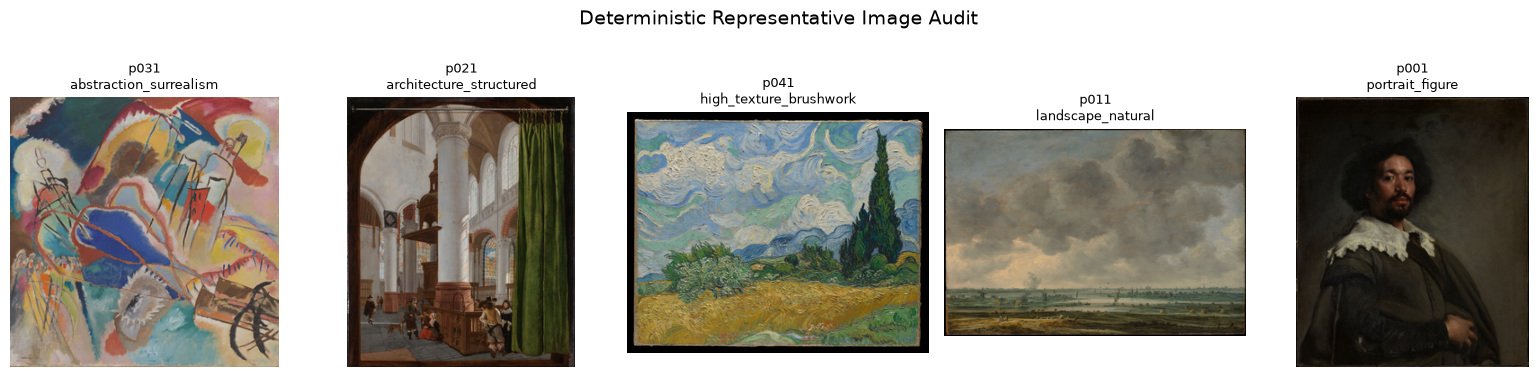

Rendered one deterministic representative image per category.
The preview was not persisted as a canonical artifact.

Batch 3 completed successfully.
Next approved stage: Batch 4 — full 300-image dataset audit and artwork-table construction.


In [9]:
# ---------------------------------------------------------------------------
# Compact representative audit table
# ---------------------------------------------------------------------------

smoke_display_df = (
    smoke_metadata_df[
        [
            "painting_id",
            "category",
            "source",
        ]
    ]
    .merge(
        smoke_image_df[
            [
                "painting_id",
                "raw_width",
                "raw_height",
                "raw_mode",
                "raw_format",
                "raw_exif_orientation",
                "raw_icc_profile_present",
                "raw_icc_profile_description",
                "raw_sha256",
                "raw_dhash64",
                "issue",
            ]
        ],
        on="painting_id",
        how="left",
        validate="one_to_one",
    )
)

smoke_display_df[
    "sha256_prefix"
] = (
    smoke_display_df[
        "raw_sha256"
    ]
    .astype(str)
    .str[:12]
)

smoke_display_df = (
    smoke_display_df.drop(
        columns=[
            "raw_sha256",
        ]
    )
)

print("Representative image evidence:")
display(smoke_display_df)


# ---------------------------------------------------------------------------
# Compact notebook-only visual preview
# ---------------------------------------------------------------------------

figure, axes = plt.subplots(
    1,
    expected_smoke_count,
    figsize=(
        3.2
        * expected_smoke_count,
        3.8,
    ),
    dpi=100,
    squeeze=False,
)

for axis, metadata_row in zip(
    axes.flatten(),
    smoke_metadata_df.itertuples(
        index=False
    ),
):
    image_path = (
        RAW_IMAGE_DIRECTORY
        / str(metadata_row.filename)
    )

    with Image.open(
        image_path
    ) as image:
        preview_image = (
            ImageOps.exif_transpose(
                image
            )
            .convert("RGB")
        )

        preview_image.thumbnail(
            (
                360,
                300,
            ),
            Image.Resampling.LANCZOS,
        )

        axis.imshow(
            preview_image
        )

    axis.set_title(
        (
            f"{metadata_row.painting_id}\n"
            f"{metadata_row.category}"
        ),
        fontsize=9,
    )

    axis.axis("off")

figure.suptitle(
    "Deterministic Representative Image Audit",
    fontsize=14,
)

figure.tight_layout(
    rect=(
        0,
        0,
        1,
        0.92,
    )
)

plt.show()
plt.close(figure)


print(
    "Rendered one deterministic representative image "
    "per category."
)
print(
    "The preview was not persisted as a canonical artifact."
)
print("\nBatch 3 completed successfully.")
print(
    "Next approved stage: Batch 4 — "
    f"full {EXPECTED_IMAGE_COUNT_FROM_CONFIG}-image dataset audit "
    "and artwork-table construction."
)

## Batch 4 — Full Dataset Image Audit and Artwork-Table Construction

This batch expands the successful representative smoke test to all configured images.

It:

- audits every referenced raw image without silently skipping failures;
- checks file existence, decoding, dimensions, format, mode, and resolution;
- detects orphan files and exact duplicates;
- computes deterministic dHash evidence for near-duplicate review;
- constructs the normalized authoritative artwork table in memory;
- computes the dataset content fingerprint.

Near-duplicate candidates are review findings rather than automatic exclusions. Missing near-duplicate hashes remain blocking because they would make the review incomplete.

No canonical outputs are persisted in this batch. Persistence and reload validation occur only after the scientific and product validation gates pass.

In [10]:
# ---------------------------------------------------------------------------
# Batch 4 helper imports
# ---------------------------------------------------------------------------

from restoration_eval.dataset_verification import (
    build_artworks_table,
    dataset_content_fingerprint,
)


# ---------------------------------------------------------------------------
# Full configured image audit
# ---------------------------------------------------------------------------

FULL_EXPECTED_IMAGE_COUNT = int(
    dataset_config["expected"]["referenced_image_count"]
)

full_audit_started = perf_counter()

full_image_audit = audit_image_collection(
    metadata_df,
    RAW_IMAGE_DIRECTORY,
    dataset_config,
    PROJECT_ROOT,
)

full_audit_duration_seconds = round(
    perf_counter() - full_audit_started,
    3,
)

full_image_df = (
    full_image_audit.images
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

full_issue_rows = (
    full_image_df.loc[
        full_image_df["issue"].astype(str).str.len() > 0,
        [
            "painting_id",
            "raw_image_path",
            "issue",
        ],
    ]
    .to_dict("records")
)

print("Full image audit completed.")
print("Expected referenced images:", FULL_EXPECTED_IMAGE_COUNT)
print("Audited image rows:", len(full_image_df))
print("Audit duration seconds:", full_audit_duration_seconds)
print("Rows with recorded issues:", len(full_issue_rows))
print(
    "Orphan image files:",
    len(full_image_audit.orphan_image_paths),
)
print(
    "Exact duplicate groups:",
    len(full_image_audit.exact_duplicate_groups),
)
print(
    "Near-duplicate candidate pairs:",
    len(full_image_audit.near_duplicate_candidates),
)

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\PIL\Image.py:3176: DecompressionBombWarning: Image size (101989188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Full image audit completed.
Expected referenced images: 300
Audited image rows: 300
Audit duration seconds: 52.183
Rows with recorded issues: 0
Orphan image files: 0
Exact duplicate groups: 0
Near-duplicate candidate pairs: 0


In [11]:
# ---------------------------------------------------------------------------
# Prevent accidental partial reruns
# ---------------------------------------------------------------------------

existing_full_image_checks = [
    check.check_id
    for check in VALIDATION.checks
    if check.validation_stage == "full_image_audit"
]

if existing_full_image_checks:
    raise RuntimeError(
        "Batch 4 validation has already been added to the consolidated "
        "collector. Restart the kernel and run the notebook top to bottom "
        "before executing this cell again."
    )


# ---------------------------------------------------------------------------
# Failure evidence
# ---------------------------------------------------------------------------

missing_file_rows = (
    full_image_df.loc[
        ~full_image_df["file_exists"],
        [
            "painting_id",
            "raw_image_path",
            "issue",
        ],
    ]
    .to_dict("records")
)

verification_failure_rows = (
    full_image_df.loc[
        ~full_image_df["image_verified"],
        [
            "painting_id",
            "raw_image_path",
            "issue",
        ],
    ]
    .to_dict("records")
)

decoding_failure_rows = (
    full_image_df.loc[
        ~full_image_df["image_loaded"],
        [
            "painting_id",
            "raw_image_path",
            "issue",
        ],
    ]
    .to_dict("records")
)

extension_format_mask = (
    full_image_df["extension_allowed"]
    & full_image_df["format_allowed"]
)

extension_format_failure_rows = (
    full_image_df.loc[
        ~extension_format_mask,
        [
            "painting_id",
            "raw_image_path",
            "raw_format",
            "extension_allowed",
            "format_allowed",
            "issue",
        ],
    ]
    .to_dict("records")
)

mode_failure_rows = (
    full_image_df.loc[
        ~full_image_df["mode_allowed"],
        [
            "painting_id",
            "raw_image_path",
            "raw_mode",
            "issue",
        ],
    ]
    .to_dict("records")
)

numeric_width = pd.to_numeric(
    full_image_df["raw_width"],
    errors="coerce",
)

numeric_height = pd.to_numeric(
    full_image_df["raw_height"],
    errors="coerce",
)

positive_dimension_mask = (
    numeric_width.gt(0)
    & numeric_height.gt(0)
)

positive_dimension_failure_rows = (
    full_image_df.loc[
        ~positive_dimension_mask,
        [
            "painting_id",
            "raw_width",
            "raw_height",
            "issue",
        ],
    ]
    .to_dict("records")
)

minimum_resolution_failure_rows = (
    full_image_df.loc[
        ~full_image_df["minimum_resolution_passed"],
        [
            "painting_id",
            "raw_width",
            "raw_height",
            "issue",
        ],
    ]
    .to_dict("records")
)

metadata_dimension_mask = (
    full_image_df["width_matches_metadata"]
    & full_image_df["height_matches_metadata"]
)

metadata_dimension_failure_rows = (
    full_image_df.loc[
        ~metadata_dimension_mask,
        [
            "painting_id",
            "raw_width",
            "raw_height",
            "width_matches_metadata",
            "height_matches_metadata",
            "issue",
        ],
    ]
    .to_dict("records")
)

sha256_valid_mask = (
    full_image_df["raw_sha256"]
    .astype("string")
    .str.fullmatch(r"[0-9a-f]{64}")
    .fillna(False)
)

dhash_valid_mask = (
    full_image_df["raw_dhash64"]
    .astype("string")
    .str.fullmatch(r"[0-9a-f]{16}")
    .fillna(False)
)

valid_sha256_count = int(sha256_valid_mask.sum())
valid_dhash_count = int(dhash_valid_mask.sum())

exact_duplicate_groups = [
    list(group)
    for group in full_image_audit.exact_duplicate_groups
]

near_duplicate_records = (
    full_image_audit.near_duplicate_candidates
    .to_dict("records")
)

near_hashes_complete = (
    valid_dhash_count == FULL_EXPECTED_IMAGE_COUNT
)

near_duplicate_passed = (
    near_hashes_complete
    and not near_duplicate_records
)

near_duplicate_severity = (
    "warning"
    if near_hashes_complete
    else "blocking"
)


# ---------------------------------------------------------------------------
# Twelve consolidated full-image checks
# ---------------------------------------------------------------------------

FULL_IMAGE_VALIDATION = ValidationCollector()

full_image_check_specs = [
    {
        "validation_stage": "full_image_audit",
        "check_id": "referenced_image_count",
        "check_description": (
            "The full image audit produces one row per configured "
            "referenced image."
        ),
        "severity": "blocking",
        "expected": FULL_EXPECTED_IMAGE_COUNT,
        "observed": len(full_image_df),
        "passed": len(full_image_df) == FULL_EXPECTED_IMAGE_COUNT,
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "referenced_files_exist",
        "check_description": (
            "Every referenced raw image exists at its declared path."
        ),
        "severity": "blocking",
        "expected": "zero missing referenced files",
        "observed": missing_file_rows,
        "passed": not missing_file_rows,
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "orphan_image_files",
        "check_description": (
            "The configured raw-image directory contains no unreferenced "
            "image files."
        ),
        "severity": "blocking",
        "expected": "zero orphan image files",
        "observed": list(full_image_audit.orphan_image_paths),
        "passed": not full_image_audit.orphan_image_paths,
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "image_structural_verification",
        "check_description": (
            "Every raw image passes Pillow structural verification."
        ),
        "severity": "blocking",
        "expected": "zero structural verification failures",
        "observed": verification_failure_rows,
        "passed": not verification_failure_rows,
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "image_complete_decode",
        "check_description": (
            "Every raw image can be completely decoded into pixel data."
        ),
        "severity": "blocking",
        "expected": "zero complete-decoding failures",
        "observed": decoding_failure_rows,
        "passed": not decoding_failure_rows,
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "image_extension_and_format",
        "check_description": (
            "Every raw image has an allowed extension and decoded format."
        ),
        "severity": "blocking",
        "expected": {
            "extensions": validation_settings["allowed_extensions"],
            "formats": validation_settings["allowed_image_formats"],
        },
        "observed": extension_format_failure_rows,
        "passed": not extension_format_failure_rows,
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "image_mode",
        "check_description": (
            "Every decoded raw image uses an allowed image mode."
        ),
        "severity": "blocking",
        "expected": validation_settings["allowed_image_modes"],
        "observed": mode_failure_rows,
        "passed": not mode_failure_rows,
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "positive_image_dimensions",
        "check_description": (
            "Every decoded raw image has positive width and height."
        ),
        "severity": "blocking",
        "expected": "width > 0 and height > 0 for every image",
        "observed": positive_dimension_failure_rows,
        "passed": not positive_dimension_failure_rows,
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "minimum_image_resolution",
        "check_description": (
            "Every raw image satisfies the configured minimum resolution."
        ),
        "severity": "blocking",
        "expected": {
            "minimum_short_side": validation_settings[
                "minimum_short_side"
            ],
            "minimum_long_side": validation_settings[
                "minimum_long_side"
            ],
        },
        "observed": minimum_resolution_failure_rows,
        "passed": not minimum_resolution_failure_rows,
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "metadata_image_dimensions",
        "check_description": (
            "Decoded image dimensions match the dimensions declared "
            "in the raw metadata."
        ),
        "severity": "blocking",
        "expected": "zero metadata/image dimension mismatches",
        "observed": metadata_dimension_failure_rows,
        "passed": not metadata_dimension_failure_rows,
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "exact_image_duplicates",
        "check_description": (
            "Every image has valid SHA-256 evidence and no exact "
            "duplicate checksum group exists."
        ),
        "severity": "blocking",
        "expected": {
            "valid_sha256_rows": FULL_EXPECTED_IMAGE_COUNT,
            "exact_duplicate_groups": 0,
        },
        "observed": {
            "valid_sha256_rows": valid_sha256_count,
            "exact_duplicate_groups": exact_duplicate_groups,
        },
        "passed": (
            valid_sha256_count == FULL_EXPECTED_IMAGE_COUNT
            and not exact_duplicate_groups
        ),
        "details": {
            "algorithm": validation_settings[
                "exact_duplicate_algorithm"
            ],
        },
    },
    {
        "validation_stage": "full_image_audit",
        "check_id": "near_duplicate_candidates",
        "check_description": (
            "Every image has deterministic dHash evidence and no pair "
            "falls within the configured review threshold."
        ),
        "severity": near_duplicate_severity,
        "expected": {
            "valid_dhash_rows": FULL_EXPECTED_IMAGE_COUNT,
            "candidate_pairs": 0,
        },
        "observed": {
            "valid_dhash_rows": valid_dhash_count,
            "candidate_pairs": len(near_duplicate_records),
            "candidates": near_duplicate_records,
        },
        "passed": near_duplicate_passed,
        "details": validation_settings["near_duplicate"],
    },
]

for check_spec in full_image_check_specs:
    FULL_IMAGE_VALIDATION.add(**check_spec)


# ---------------------------------------------------------------------------
# Batch and consolidated gates
# ---------------------------------------------------------------------------

full_image_checks_df = (
    FULL_IMAGE_VALIDATION.to_dataframe()
)

if len(full_image_checks_df) != 12:
    raise RuntimeError(
        "Batch 4 should produce exactly 12 consolidated checks; "
        f"found {len(full_image_checks_df)}."
    )

FULL_IMAGE_VALIDATION.raise_for_blocking()

VALIDATION.extend(
    FULL_IMAGE_VALIDATION.checks
)

if len(VALIDATION.checks) != 34:
    raise RuntimeError(
        "Batches 1–4 should produce exactly 34 consolidated checks; "
        f"found {len(VALIDATION.checks)}."
    )

VALIDATION.raise_for_blocking()

print("Batch 4 full-image checks:")
display(
    full_image_checks_df[
        [
            "check_id",
            "severity",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nFull-image validation gate passed:",
    FULL_IMAGE_VALIDATION.overall_passed,
)
print(
    "Consolidated validation checks:",
    len(VALIDATION.checks),
)

Batch 4 full-image checks:


,check_id,severity,observed,passed
0,referenced_image_count,blocking,300,True
1,referenced_files_exist,blocking,[],True
2,orphan_image_files,blocking,[],True
3,image_structural_verification,blocking,[],True
4,image_complete_decode,blocking,[],True
5,image_extension_and_format,blocking,[],True
6,image_mode,blocking,[],True
7,positive_image_dimensions,blocking,[],True
8,minimum_image_resolution,blocking,[],True
9,metadata_image_dimensions,blocking,[],True



Full-image validation gate passed: True
Consolidated validation checks: 34


In [12]:
# ---------------------------------------------------------------------------
# Construct normalized in-memory artwork table
# ---------------------------------------------------------------------------

artworks_df = build_artworks_table(
    metadata_df,
    full_image_audit,
    dataset_config,
)

DATASET_CONTENT_SHA256 = dataset_content_fingerprint(
    metadata_df,
    full_image_audit,
    dataset_config,
)

expected_artwork_count = int(
    dataset_config["expected"]["total_paintings"]
)

acceptance_summary_df = (
    artworks_df.groupby(
        "acceptance_status",
        dropna=False,
    )
    .size()
    .rename("painting_count")
    .reset_index()
    .sort_values(
        "acceptance_status",
        kind="stable",
    )
    .reset_index(drop=True)
)

technical_summary_df = pd.DataFrame(
    [
        {
            "audited_images": len(full_image_df),
            "minimum_width": int(
                pd.to_numeric(
                    full_image_df["raw_width"],
                    errors="coerce",
                ).min()
            ),
            "median_width": round(
                float(
                    pd.to_numeric(
                        full_image_df["raw_width"],
                        errors="coerce",
                    ).median()
                ),
                1,
            ),
            "maximum_width": int(
                pd.to_numeric(
                    full_image_df["raw_width"],
                    errors="coerce",
                ).max()
            ),
            "minimum_height": int(
                pd.to_numeric(
                    full_image_df["raw_height"],
                    errors="coerce",
                ).min()
            ),
            "median_height": round(
                float(
                    pd.to_numeric(
                        full_image_df["raw_height"],
                        errors="coerce",
                    ).median()
                ),
                1,
            ),
            "maximum_height": int(
                pd.to_numeric(
                    full_image_df["raw_height"],
                    errors="coerce",
                ).max()
            ),
            "total_size_mb": round(
                float(
                    pd.to_numeric(
                        full_image_df["raw_size_bytes"],
                        errors="coerce",
                    ).sum()
                )
                / (1024**2),
                2,
            ),
        }
    ]
)

format_mode_summary_df = (
    full_image_df.groupby(
        [
            "raw_format",
            "raw_mode",
        ],
        dropna=False,
    )
    .size()
    .rename("image_count")
    .reset_index()
    .sort_values(
        [
            "raw_format",
            "raw_mode",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

icc_summary_df = (
    full_image_df.assign(
        icc_profile_description=(
            full_image_df[
                "raw_icc_profile_description"
            ]
            .astype("string")
            .fillna("not_embedded")
        )
    )
    .groupby(
        [
            "raw_icc_profile_present",
            "icc_profile_description",
        ],
        dropna=False,
    )
    .size()
    .rename("image_count")
    .reset_index()
    .sort_values(
        [
            "raw_icc_profile_present",
            "icc_profile_description",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

exif_summary_df = (
    full_image_df[
        "raw_exif_orientation"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "exif_orientation"
    )
    .rename(
        "image_count"
    )
    .reset_index()
    .sort_values(
        "exif_orientation",
        kind="stable",
    )
    .reset_index(drop=True)
)

artwork_preview_df = (
    artworks_df
    .sort_values(
        [
            "category",
            "painting_id",
        ],
        kind="stable",
    )
    .groupby(
        "category",
        sort=True,
        group_keys=False,
    )
    .head(1)
    .copy()
)

artwork_preview_df["raw_dimensions"] = (
    artwork_preview_df["raw_width"]
    .astype("Int64")
    .astype(str)
    + " × "
    + artwork_preview_df["raw_height"]
    .astype("Int64")
    .astype(str)
)

artwork_preview_df["sha256_prefix"] = (
    artwork_preview_df["raw_sha256"]
    .astype(str)
    .str[:12]
)

artwork_preview_df = artwork_preview_df[
    [
        "painting_id",
        "category",
        "source",
        "raw_dimensions",
        "raw_format",
        "raw_mode",
        "prompt_metadata_status",
        "acceptance_status",
        "sha256_prefix",
    ]
].reset_index(drop=True)


# ---------------------------------------------------------------------------
# Compact Batch 4 evidence
# ---------------------------------------------------------------------------

print("Normalized artwork rows:", len(artworks_df))
print("Expected artwork rows:", expected_artwork_count)
print(
    "Accepted artworks:",
    int(
        (
            artworks_df["acceptance_status"]
            == "accepted"
        ).sum()
    ),
)
print(
    "Excluded artworks:",
    int(
        (
            artworks_df["acceptance_status"]
            == "excluded"
        ).sum()
    ),
)
print(
    "Dataset content fingerprint:",
    DATASET_CONTENT_SHA256,
)

print("\nAcceptance summary:")
display(acceptance_summary_df)

print("Image dimension and storage summary:")
display(technical_summary_df)

print("Decoded format and mode summary:")
display(format_mode_summary_df)

print("ICC profile summary:")
display(icc_summary_df)

print("EXIF orientation summary:")
display(exif_summary_df)

print("One normalized artwork record per category:")
display(artwork_preview_df)

if near_duplicate_records:
    print("Near-duplicate candidates requiring review:")
    display(
        full_image_audit.near_duplicate_candidates
    )
else:
    print("No near-duplicate candidate pairs require review.")

print("\nBatch 4 completed successfully.")
print("No canonical files were persisted.")
print(
    "Next approved stage: Batch 5 — "
    "artwork-product and scientific validation."
)

Normalized artwork rows: 300
Expected artwork rows: 300
Accepted artworks: 300
Excluded artworks: 0
Dataset content fingerprint: 5c8797aebe0c5aced37a274854a8f2584bb7d4fd9babff1fc6ba37f316b2f6b1

Acceptance summary:


,acceptance_status,painting_count
0,accepted,300


Image dimension and storage summary:


,audited_images,minimum_width,median_width,maximum_width,minimum_height,median_height,maximum_height,total_size_mb
0,300,742,2987.0,12172,652,2821.5,10194,747.26


Decoded format and mode summary:


...

EXIF orientation summary:


,exif_orientation,image_count
0,1,300


One normalized artwork record per category:


,painting_id,category,source,raw_dimensions,raw_format,raw_mode,prompt_metadata_status,acceptance_status,sha256_prefix
0,p031,abstraction_surrealism,Art Institute of Chicago,2987 × 3000,JPEG,RGB,partial,accepted,af3931235d0e
1,p021,architecture_structured,Rijksmuseum,4435 × 5246,JPEG,RGB,partial,accepted,5db68c76914a
2,p041,high_texture_brushwork,The Metropolitan Museum of Art,4000 × 3184,JPEG,RGB,complete,accepted,b46d02a42fd3
3,p011,landscape_natural,The Metropolitan Museum of Art,3811 × 2618,JPEG,RGB,partial,accepted,9cb9cb52aab7
4,p001,portrait_figure,The Metropolitan Museum of Art,3427 × 3968,JPEG,RGB,complete,accepted,eb8f7a240d4e


No near-duplicate candidate pairs require review.

Batch 4 completed successfully.
No canonical files were persisted.
Next approved stage: Batch 5 — artwork-product and scientific validation.


## Batch 5 — Artwork-Product and Scientific Validation

This batch validates the normalized artwork product and constructs the consolidated long-form dataset audit in memory.

It verifies:

- artwork and audit schema conformance;
- row counts, unique identifiers, and deterministic ordering;
- dataset identity and acceptance decisions;
- rights-status derivation;
- image-reference and integrity-evidence propagation;
- metadata-completeness and prompt-readiness derivation;
- dataset-fingerprint repeatability;
- scientific summary, distribution, imbalance, and bias coverage.

The 16 checks in this batch bring the consolidated validation contract to 50 checks.

No canonical outputs are persisted yet. Figures and notebook-level analysis follow only after this gate passes.

In [13]:
# ---------------------------------------------------------------------------
# Batch 5 helper imports
# ---------------------------------------------------------------------------

from restoration_eval.dataset_verification import (
    build_dataset_audit,
)

from restoration_eval.schemas import (
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Construct the consolidated in-memory dataset audit
# ---------------------------------------------------------------------------

dataset_audit_df = build_dataset_audit(
    metadata_df,
    full_image_audit,
    artworks_df,
    dataset_config,
)

EXPECTED_ARTWORK_COUNT = int(
    dataset_config["expected"]["total_paintings"]
)

EXPECTED_AUDIT_ROW_COUNT = int(
    dataset_config["expected"]["audit_row_count"]
)


# ---------------------------------------------------------------------------
# Schema evidence
# ---------------------------------------------------------------------------

artworks_schema_result = validate_dataframe(
    artworks_df,
    ARTWORKS_SCHEMA,
    allow_extra_columns=False,
)

dataset_audit_schema_result = validate_dataframe(
    dataset_audit_df,
    DATASET_AUDIT_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Artwork identity and deterministic order
# ---------------------------------------------------------------------------

expected_painting_order = sorted(
    metadata_df["painting_id"]
    .astype(str)
    .tolist()
)

observed_painting_order = (
    artworks_df["painting_id"]
    .astype(str)
    .tolist()
)

duplicate_artwork_ids = (
    artworks_df.loc[
        artworks_df["painting_id"].duplicated(
            keep=False
        ),
        "painting_id",
    ]
    .astype(str)
    .tolist()
)

observed_sort_indices = (
    pd.to_numeric(
        artworks_df["dataset_sort_index"],
        errors="coerce",
    )
    .astype("Int64")
    .tolist()
)

expected_sort_indices = list(
    range(
        1,
        EXPECTED_ARTWORK_COUNT + 1,
    )
)


# ---------------------------------------------------------------------------
# Dataset identity
# ---------------------------------------------------------------------------

expected_dataset_identity = {
    "dataset_id": [
        str(
            dataset_config["dataset"]["dataset_id"]
        )
    ],
    "dataset_version": [
        str(
            dataset_config["dataset"]["dataset_version"]
        )
    ],
    "dataset_scope": [
        str(
            dataset_config["dataset"]["dataset_scope"]
        )
    ],
}

observed_dataset_identity = {
    column: sorted(
        artworks_df[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    for column in expected_dataset_identity
}


# ---------------------------------------------------------------------------
# Acceptance-decision coherence
# ---------------------------------------------------------------------------

acceptance_status_text = (
    artworks_df["acceptance_status"]
    .astype("string")
    .str.strip()
)

exclusion_reason_text = (
    artworks_df["exclusion_reason"]
    .astype("string")
    .str.strip()
)

accepted_mask = acceptance_status_text.eq(
    "accepted"
)

excluded_mask = acceptance_status_text.eq(
    "excluded"
)

unknown_acceptance_rows = (
    artworks_df.loc[
        ~(
            accepted_mask
            | excluded_mask
        ),
        [
            "painting_id",
            "acceptance_status",
            "exclusion_reason",
        ],
    ]
    .to_dict("records")
)

accepted_with_reason_rows = (
    artworks_df.loc[
        accepted_mask
        & exclusion_reason_text.notna()
        & exclusion_reason_text.ne(""),
        [
            "painting_id",
            "acceptance_status",
            "exclusion_reason",
        ],
    ]
    .to_dict("records")
)

excluded_without_reason_rows = (
    artworks_df.loc[
        excluded_mask
        & (
            exclusion_reason_text.isna()
            | exclusion_reason_text.eq("")
        ),
        [
            "painting_id",
            "acceptance_status",
            "exclusion_reason",
        ],
    ]
    .to_dict("records")
)

accepted_artwork_count = int(
    accepted_mask.sum()
)

excluded_artwork_count = int(
    excluded_mask.sum()
)


# ---------------------------------------------------------------------------
# Rights-status derivation
# ---------------------------------------------------------------------------

rights_status_lookup = {
    (
        str(item["source"]),
        str(item["license"]),
    ): str(item["rights_status"])
    for item in validation_settings[
        "accepted_source_license_pairs"
    ]
}

rights_failure_rows = [
    {
        "painting_id": str(row.painting_id),
        "source": str(row.source),
        "license": str(row.license),
        "expected_rights_status": (
            rights_status_lookup.get(
                (
                    str(row.source),
                    str(row.license),
                ),
                "unapproved",
            )
        ),
        "observed_rights_status": str(
            row.rights_status
        ),
    }
    for row in artworks_df.itertuples(
        index=False
    )
    if str(row.rights_status)
    != rights_status_lookup.get(
        (
            str(row.source),
            str(row.license),
        ),
        "unapproved",
    )
]


# ---------------------------------------------------------------------------
# Artwork/image evidence alignment
# ---------------------------------------------------------------------------

comparison_fields = [
    "raw_filename",
    "raw_image_path",
    "raw_width",
    "raw_height",
    "raw_mode",
    "raw_format",
    "raw_size_bytes",
    "raw_sha256",
    "raw_dhash64",
    "raw_exif_orientation",
    "raw_icc_profile_present",
    "raw_icc_profile_description",
]

artwork_image_comparison_df = (
    artworks_df[
        [
            "painting_id",
            *comparison_fields,
        ]
    ]
    .merge(
        full_image_df[
            [
                "painting_id",
                *comparison_fields,
            ]
        ],
        on="painting_id",
        how="outer",
        suffixes=(
            "_artwork",
            "_audit",
        ),
        indicator=True,
        validate="one_to_one",
    )
)

reference_fields = [
    "raw_filename",
    "raw_image_path",
    "raw_width",
    "raw_height",
    "raw_mode",
    "raw_format",
]

integrity_fields = [
    "raw_size_bytes",
    "raw_sha256",
    "raw_dhash64",
    "raw_exif_orientation",
    "raw_icc_profile_present",
    "raw_icc_profile_description",
]

reference_match_mask = pd.Series(
    True,
    index=artwork_image_comparison_df.index,
    dtype=bool,
)

integrity_match_mask = pd.Series(
    True,
    index=artwork_image_comparison_df.index,
    dtype=bool,
)

both_sources_mask = (
    artwork_image_comparison_df["_merge"]
    .eq("both")
)

for field in reference_fields:
    artwork_values = (
        artwork_image_comparison_df[
            f"{field}_artwork"
        ]
        .astype("string")
        .fillna("<NA>")
    )

    audit_values = (
        artwork_image_comparison_df[
            f"{field}_audit"
        ]
        .astype("string")
        .fillna("<NA>")
    )

    reference_match_mask &= (
        artwork_values.eq(audit_values)
    )

for field in integrity_fields:
    artwork_values = (
        artwork_image_comparison_df[
            f"{field}_artwork"
        ]
        .astype("string")
        .fillna("<NA>")
    )

    audit_values = (
        artwork_image_comparison_df[
            f"{field}_audit"
        ]
        .astype("string")
        .fillna("<NA>")
    )

    integrity_match_mask &= (
        artwork_values.eq(audit_values)
    )

reference_match_mask &= both_sources_mask
integrity_match_mask &= both_sources_mask

reference_failure_rows = (
    artwork_image_comparison_df.loc[
        ~reference_match_mask,
        [
            "painting_id",
            "_merge",
            *[
                f"{field}_artwork"
                for field in reference_fields
            ],
            *[
                f"{field}_audit"
                for field in reference_fields
            ],
        ],
    ]
    .to_dict("records")
)

integrity_failure_rows = (
    artwork_image_comparison_df.loc[
        ~integrity_match_mask,
        [
            "painting_id",
            "_merge",
            *[
                f"{field}_artwork"
                for field in integrity_fields
            ],
            *[
                f"{field}_audit"
                for field in integrity_fields
            ],
        ],
    ]
    .to_dict("records")
)


# ---------------------------------------------------------------------------
# Metadata-completeness and prompt-readiness derivation
# ---------------------------------------------------------------------------

metadata_by_id = (
    metadata_df
    .set_index(
        "painting_id",
        drop=False,
    )
    .sort_index()
)

artworks_by_id = (
    artworks_df
    .set_index(
        "painting_id",
        drop=False,
    )
    .sort_index()
)

all_derived_fields = sorted(
    set(
        dataset_config["metadata"][
            "descriptive_completeness_fields"
        ]
    )
    | set(
        dataset_config["metadata"][
            "prompt_metadata_fields"
        ]
    )
)

metadata_usable_df = pd.DataFrame(
    index=metadata_by_id.index
)

unusable_text_values = {
    "",
    "nan",
    "none",
    "null",
    "<na>",
}

for field in all_derived_fields:
    cleaned_values = (
        metadata_by_id[field]
        .astype("string")
        .str.strip()
    )

    metadata_usable_df[field] = (
        metadata_by_id[field].notna()
        & ~cleaned_values
        .str.lower()
        .isin(unusable_text_values)
    ).fillna(False)

descriptive_fields = list(
    dataset_config["metadata"][
        "descriptive_completeness_fields"
    ]
)

expected_completeness_pct = (
    100.0
    * metadata_usable_df[
        descriptive_fields
    ].sum(axis=1)
    / len(descriptive_fields)
).round(2)

observed_completeness_pct = (
    pd.to_numeric(
        artworks_by_id[
            "metadata_completeness_pct"
        ],
        errors="coerce",
    )
    .reindex(
        expected_completeness_pct.index
    )
)

completeness_match_mask = (
    expected_completeness_pct
    .sub(observed_completeness_pct)
    .abs()
    .le(1e-9)
    .fillna(False)
)

completeness_mismatch_ids = (
    expected_completeness_pct.index[
        ~completeness_match_mask
    ]
    .astype(str)
    .tolist()
)

completeness_bounds_passed = bool(
    observed_completeness_pct
    .between(
        0.0,
        100.0,
        inclusive="both",
    )
    .fillna(False)
    .all()
)

prompt_fields = list(
    dataset_config["metadata"][
        "prompt_metadata_fields"
    ]
)

expected_prompt_counts = (
    metadata_usable_df[
        prompt_fields
    ]
    .sum(axis=1)
    .astype(int)
)

expected_prompt_status = pd.Series(
    "partial",
    index=expected_prompt_counts.index,
    dtype="string",
)

expected_prompt_status.loc[
    expected_prompt_counts.eq(0)
] = "none"

expected_prompt_status.loc[
    expected_prompt_counts.eq(
        len(prompt_fields)
    )
] = "complete"

observed_prompt_counts = (
    pd.to_numeric(
        artworks_by_id[
            "prompt_metadata_field_count"
        ],
        errors="coerce",
    )
    .reindex(
        expected_prompt_counts.index
    )
)

observed_prompt_status = (
    artworks_by_id[
        "prompt_metadata_status"
    ]
    .astype("string")
    .reindex(
        expected_prompt_status.index
    )
)

prompt_match_mask = (
    observed_prompt_counts.eq(
        expected_prompt_counts
    )
    & observed_prompt_status.eq(
        expected_prompt_status
    )
)

prompt_mismatch_ids = (
    expected_prompt_counts.index[
        ~prompt_match_mask.fillna(False)
    ]
    .astype(str)
    .tolist()
)


# ---------------------------------------------------------------------------
# Fingerprint repeatability
# ---------------------------------------------------------------------------

recomputed_dataset_fingerprint = (
    dataset_content_fingerprint(
        metadata_df,
        full_image_audit,
        dataset_config,
    )
)

fingerprint_format_passed = (
    len(DATASET_CONTENT_SHA256) == 64
    and all(
        character in "0123456789abcdef"
        for character in DATASET_CONTENT_SHA256
    )
)

fingerprint_repeatability_passed = (
    recomputed_dataset_fingerprint
    == DATASET_CONTENT_SHA256
)


# ---------------------------------------------------------------------------
# Scientific audit coverage and consistency
# ---------------------------------------------------------------------------

expected_summary_metrics = {
    "metadata_row_count": len(metadata_df),
    "accepted_artwork_count": (
        accepted_artwork_count
    ),
    "excluded_artwork_count": (
        excluded_artwork_count
    ),
    "referenced_image_count": len(
        full_image_df
    ),
    "orphan_image_count": len(
        full_image_audit.orphan_image_paths
    ),
    "missing_image_count": int(
        (
            ~full_image_df["file_exists"]
        ).sum()
    ),
    "unreadable_image_count": int(
        (
            ~full_image_df["image_loaded"]
        ).sum()
    ),
    "dimension_mismatch_count": int(
        (
            ~(
                full_image_df[
                    "width_matches_metadata"
                ]
                & full_image_df[
                    "height_matches_metadata"
                ]
            )
        ).sum()
    ),
    "exact_duplicate_group_count": len(
        full_image_audit.exact_duplicate_groups
    ),
    "near_duplicate_candidate_pair_count": len(
        full_image_audit.near_duplicate_candidates
    ),
    "prompt_metadata_complete_count": int(
        (
            artworks_df[
                "prompt_metadata_status"
            ]
            == "complete"
        ).sum()
    ),
    "prompt_metadata_partial_count": int(
        (
            artworks_df[
                "prompt_metadata_status"
            ]
            == "partial"
        ).sum()
    ),
    "icc_profile_present_count": int(
        artworks_df[
            "raw_icc_profile_present"
        ].sum()
    ),
    "non_default_exif_orientation_count": int(
        (
            pd.to_numeric(
                artworks_df[
                    "raw_exif_orientation"
                ],
                errors="coerce",
            )
            != 1
        ).sum()
    ),
}

summary_rows_df = (
    dataset_audit_df.loc[
        dataset_audit_df[
            "audit_section"
        ].eq("summary")
    ]
)

summary_value_lookup = dict(
    zip(
        summary_rows_df["metric_name"],
        summary_rows_df["metric_value"],
    )
)

observed_summary_metrics = {}

for metric_name in expected_summary_metrics:
    metric_value = summary_value_lookup.get(
        metric_name,
        pd.NA,
    )

    observed_summary_metrics[
        metric_name
    ] = (
        None
        if pd.isna(metric_value)
        else int(float(metric_value))
    )

summary_metrics_passed = (
    observed_summary_metrics
    == expected_summary_metrics
)

expected_audit_sections = {
    "summary",
    "metadata_completeness",
    "distribution",
    "prompt_readiness",
    "imbalance",
    "bias_and_limitations",
}

observed_audit_sections = set(
    dataset_audit_df[
        "audit_section"
    ]
    .astype(str)
    .unique()
)

required_distribution_fields = {
    "category",
    "source",
    "license",
    "style_or_period",
    "medium",
    "date_or_period",
}

observed_distribution_fields = set(
    dataset_audit_df.loc[
        dataset_audit_df[
            "audit_section"
        ].eq("distribution"),
        "group_field",
    ]
    .astype(str)
    .unique()
)

required_imbalance_metrics = {
    "category_count_max",
    "category_count_min",
    "category_share_max_pct",
    "category_share_min_pct",
    "category_max_min_ratio",
    "category_hhi",
    "source_count_max",
    "source_count_min",
    "source_share_max_pct",
    "source_max_min_ratio",
    "source_hhi",
    "category_coverage_range_pct",
}

observed_imbalance_metrics = set(
    dataset_audit_df.loc[
        dataset_audit_df[
            "audit_section"
        ].eq("imbalance"),
        "metric_name",
    ]
    .astype(str)
    .unique()
)

metadata_completeness_audit_count = int(
    dataset_audit_df[
        "audit_section"
    ]
    .eq("metadata_completeness")
    .sum()
)

prompt_readiness_audit_count = int(
    dataset_audit_df[
        "audit_section"
    ]
    .eq("prompt_readiness")
    .sum()
)

scientific_coverage_passed = (
    expected_audit_sections.issubset(
        observed_audit_sections
    )
    and required_distribution_fields.issubset(
        observed_distribution_fields
    )
    and required_imbalance_metrics.issubset(
        observed_imbalance_metrics
    )
    and metadata_completeness_audit_count
    == len(metadata_df.columns)
    and prompt_readiness_audit_count
    == (
        2
        * len(
            dataset_config["expected"][
                "categories"
            ]
        )
    )
)

bias_rows_df = (
    dataset_audit_df.loc[
        dataset_audit_df[
            "audit_section"
        ].eq("bias_and_limitations")
    ]
    .copy()
)

expected_bias_pairs = {
    (
        str(item["bias_category"]),
        str(item["bias_id"]),
    )
    for item in dataset_config[
        "bias_notes"
    ]
}

observed_bias_pairs = {
    (
        str(row.group_field),
        str(row.group_value),
    )
    for row in bias_rows_df.itertuples(
        index=False
    )
}

bias_details_present = bool(
    bias_rows_df["details"]
    .astype("string")
    .str.strip()
    .ne("")
    .fillna(False)
    .all()
)

bias_status_passed = bool(
    bias_rows_df["status"]
    .astype(str)
    .eq("documented_limitation")
    .all()
)

In [14]:
# ---------------------------------------------------------------------------
# Prevent accidental partial reruns
# ---------------------------------------------------------------------------

existing_batch5_checks = [
    check.check_id
    for check in VALIDATION.checks
    if check.validation_stage
    in {
        "artwork_product",
        "scientific_audit",
    }
]

if existing_batch5_checks:
    raise RuntimeError(
        "Batch 5 validation has already been added to the consolidated "
        "collector. Restart the kernel and run the notebook top to bottom "
        "before executing this cell again."
    )


# ---------------------------------------------------------------------------
# Sixteen artwork-product and scientific checks
# ---------------------------------------------------------------------------

BATCH5_VALIDATION = ValidationCollector()

batch5_check_specs = [
    {
        "validation_stage": "artwork_product",
        "check_id": "artworks_schema",
        "check_description": (
            "The normalized artwork table satisfies artworks.v1 "
            "without undeclared columns."
        ),
        "severity": "blocking",
        "expected": {
            "schema_name": ARTWORKS_SCHEMA.name,
            "schema_version": ARTWORKS_SCHEMA.version,
            "passed": True,
        },
        "observed": artworks_schema_result.to_dict(),
        "passed": artworks_schema_result.passed,
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "artwork_row_count",
        "check_description": (
            "The artwork table contains the configured number of paintings."
        ),
        "severity": "blocking",
        "expected": EXPECTED_ARTWORK_COUNT,
        "observed": len(artworks_df),
        "passed": (
            len(artworks_df)
            == EXPECTED_ARTWORK_COUNT
        ),
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "unique_artwork_identifiers",
        "check_description": (
            "Every artwork has one unique painting_id."
        ),
        "severity": "blocking",
        "expected": "zero duplicated painting_id values",
        "observed": duplicate_artwork_ids,
        "passed": (
            not duplicate_artwork_ids
            and artworks_df[
                "painting_id"
            ].nunique(dropna=False)
            == len(artworks_df)
        ),
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "deterministic_artwork_order",
        "check_description": (
            "Artwork rows follow stable painting_id order with contiguous "
            "one-based dataset_sort_index values."
        ),
        "severity": "blocking",
        "expected": {
            "painting_order": expected_painting_order,
            "sort_indices": expected_sort_indices,
        },
        "observed": {
            "painting_order": observed_painting_order,
            "sort_indices": observed_sort_indices,
        },
        "passed": (
            observed_painting_order
            == expected_painting_order
            and observed_sort_indices
            == expected_sort_indices
        ),
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "dataset_identity",
        "check_description": (
            "Every artwork carries the configured dataset ID, version, "
            "and scope."
        ),
        "severity": "blocking",
        "expected": expected_dataset_identity,
        "observed": observed_dataset_identity,
        "passed": (
            observed_dataset_identity
            == expected_dataset_identity
        ),
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "acceptance_decisions",
        "check_description": (
            "Acceptance statuses are recognized and exclusion reasons "
            "are coherent with each decision."
        ),
        "severity": "blocking",
        "expected": {
            "accepted": EXPECTED_ARTWORK_COUNT,
            "excluded": 0,
            "unknown_status_rows": 0,
            "accepted_with_reason_rows": 0,
            "excluded_without_reason_rows": 0,
        },
        "observed": {
            "accepted": accepted_artwork_count,
            "excluded": excluded_artwork_count,
            "unknown_status_rows": unknown_acceptance_rows,
            "accepted_with_reason_rows": accepted_with_reason_rows,
            "excluded_without_reason_rows": excluded_without_reason_rows,
        },
        "passed": (
            accepted_artwork_count
            == EXPECTED_ARTWORK_COUNT
            and excluded_artwork_count == 0
            and not unknown_acceptance_rows
            and not accepted_with_reason_rows
            and not excluded_without_reason_rows
        ),
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "rights_status_derivation",
        "check_description": (
            "Each source and licence pair maps to the configured "
            "rights status."
        ),
        "severity": "blocking",
        "expected": "zero rights-status derivation failures",
        "observed": rights_failure_rows,
        "passed": not rights_failure_rows,
        "details": {
            "accepted_mappings": [
                {
                    "source": source,
                    "license": license_value,
                    "rights_status": rights_status,
                }
                for (
                    source,
                    license_value,
                ), rights_status
                in sorted(
                    rights_status_lookup.items()
                )
            ],
        },
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "image_reference_propagation",
        "check_description": (
            "Artwork filenames, paths, dimensions, modes, and formats "
            "match the full image audit."
        ),
        "severity": "blocking",
        "expected": "zero image-reference propagation failures",
        "observed": reference_failure_rows,
        "passed": not reference_failure_rows,
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "image_integrity_propagation",
        "check_description": (
            "Artwork size, hashes, EXIF, and ICC evidence match the "
            "full image audit."
        ),
        "severity": "blocking",
        "expected": "zero integrity-evidence propagation failures",
        "observed": integrity_failure_rows,
        "passed": not integrity_failure_rows,
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "metadata_completeness_derivation",
        "check_description": (
            "Metadata-completeness percentages are reproducible and "
            "remain within zero to one hundred percent."
        ),
        "severity": "blocking",
        "expected": {
            "mismatched_paintings": [],
            "minimum_pct": 0.0,
            "maximum_pct": 100.0,
        },
        "observed": {
            "mismatched_paintings": completeness_mismatch_ids,
            "minimum_pct": float(
                observed_completeness_pct.min()
            ),
            "maximum_pct": float(
                observed_completeness_pct.max()
            ),
        },
        "passed": (
            not completeness_mismatch_ids
            and completeness_bounds_passed
        ),
        "details": {
            "fields": descriptive_fields,
        },
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "prompt_readiness_derivation",
        "check_description": (
            "Prompt metadata counts and readiness statuses are "
            "reproducible from the configured metadata fields."
        ),
        "severity": "blocking",
        "expected": "zero prompt-readiness derivation mismatches",
        "observed": prompt_mismatch_ids,
        "passed": not prompt_mismatch_ids,
        "details": {
            "fields": prompt_fields,
            "status_values": [
                "none",
                "partial",
                "complete",
            ],
        },
    },
    {
        "validation_stage": "artwork_product",
        "check_id": "dataset_fingerprint",
        "check_description": (
            "The dataset fingerprint is a lowercase SHA-256 value and "
            "is reproducible from normalized metadata and image hashes."
        ),
        "severity": "blocking",
        "expected": {
            "format": "64 lowercase hexadecimal characters",
            "repeatable": True,
        },
        "observed": {
            "fingerprint": DATASET_CONTENT_SHA256,
            "recomputed_fingerprint": (
                recomputed_dataset_fingerprint
            ),
        },
        "passed": (
            fingerprint_format_passed
            and fingerprint_repeatability_passed
        ),
        "details": {
            "fingerprint_version": (
                DATASET_FINGERPRINT_VERSION
            ),
        },
    },
    {
        "validation_stage": "scientific_audit",
        "check_id": "dataset_audit_schema",
        "check_description": (
            "The consolidated dataset audit satisfies dataset_audit.v1 "
            "without undeclared columns."
        ),
        "severity": "blocking",
        "expected": {
            "schema_name": DATASET_AUDIT_SCHEMA.name,
            "schema_version": DATASET_AUDIT_SCHEMA.version,
            "passed": True,
        },
        "observed": dataset_audit_schema_result.to_dict(),
        "passed": dataset_audit_schema_result.passed,
    },
    {
        "validation_stage": "scientific_audit",
        "check_id": "dataset_audit_row_count",
        "check_description": (
            "The consolidated audit contains the configured deterministic "
            "number of long-form rows."
        ),
        "severity": "blocking",
        "expected": EXPECTED_AUDIT_ROW_COUNT,
        "observed": len(dataset_audit_df),
        "passed": (
            len(dataset_audit_df)
            == EXPECTED_AUDIT_ROW_COUNT
        ),
    },
    {
        "validation_stage": "scientific_audit",
        "check_id": "scientific_audit_coverage",
        "check_description": (
            "The audit contains consistent summary metrics and required "
            "completeness, distribution, prompt-readiness, and imbalance "
            "evidence."
        ),
        "severity": "blocking",
        "expected": {
            "summary_metrics": expected_summary_metrics,
            "required_sections": sorted(
                expected_audit_sections
            ),
            "distribution_fields": sorted(
                required_distribution_fields
            ),
            "imbalance_metrics": sorted(
                required_imbalance_metrics
            ),
            "metadata_completeness_rows": len(
                metadata_df.columns
            ),
            "prompt_readiness_rows": (
                2
                * len(
                    dataset_config[
                        "expected"
                    ]["categories"]
                )
            ),
        },
        "observed": {
            "summary_metrics": observed_summary_metrics,
            "sections": sorted(
                observed_audit_sections
            ),
            "distribution_fields": sorted(
                observed_distribution_fields
            ),
            "imbalance_metrics": sorted(
                observed_imbalance_metrics
            ),
            "metadata_completeness_rows": (
                metadata_completeness_audit_count
            ),
            "prompt_readiness_rows": (
                prompt_readiness_audit_count
            ),
        },
        "passed": (
            summary_metrics_passed
            and scientific_coverage_passed
        ),
    },
    {
        "validation_stage": "scientific_audit",
        "check_id": "documented_biases_and_limitations",
        "check_description": (
            "Every configured bias or limitation is represented once "
            "with its category, status, statement, and evidence basis."
        ),
        "severity": "blocking",
        "expected": sorted(
            [
                {
                    "bias_category": category,
                    "bias_id": bias_id,
                }
                for category, bias_id
                in expected_bias_pairs
            ],
            key=lambda item: (
                item["bias_category"],
                item["bias_id"],
            ),
        ),
        "observed": sorted(
            [
                {
                    "bias_category": category,
                    "bias_id": bias_id,
                }
                for category, bias_id
                in observed_bias_pairs
            ],
            key=lambda item: (
                item["bias_category"],
                item["bias_id"],
            ),
        ),
        "passed": (
            observed_bias_pairs
            == expected_bias_pairs
            and len(bias_rows_df)
            == len(expected_bias_pairs)
            and bias_details_present
            and bias_status_passed
        ),
    },
]

for check_spec in batch5_check_specs:
    BATCH5_VALIDATION.add(
        **check_spec
    )


# ---------------------------------------------------------------------------
# Batch and consolidated gates
# ---------------------------------------------------------------------------

batch5_checks_df = (
    BATCH5_VALIDATION.to_dataframe()
)

if len(batch5_checks_df) != 16:
    raise RuntimeError(
        "Batch 5 should produce exactly 16 consolidated checks; "
        f"found {len(batch5_checks_df)}."
    )

BATCH5_VALIDATION.raise_for_blocking()

VALIDATION.extend(
    BATCH5_VALIDATION.checks
)

if (
    len(VALIDATION.checks)
    != EXPECTED_CONSOLIDATED_CHECK_COUNT
):
    raise RuntimeError(
        "Batches 1–5 should produce exactly "
        f"{EXPECTED_CONSOLIDATED_CHECK_COUNT} consolidated checks; "
        f"found {len(VALIDATION.checks)}."
    )

VALIDATION.raise_for_blocking()

print("Batch 5 validation checks:")
display(
    batch5_checks_df[
        [
            "validation_stage",
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "\nBatch 5 validation gate passed:",
    BATCH5_VALIDATION.overall_passed,
)
print(
    "Consolidated validation checks:",
    len(VALIDATION.checks),
)

Batch 5 validation checks:


,validation_stage,check_id,severity,passed
0,artwork_product,artworks_schema,blocking,True
1,artwork_product,artwork_row_count,blocking,True
2,artwork_product,unique_artwork_identifiers,blocking,True
3,artwork_product,deterministic_artwork_order,blocking,True
4,artwork_product,dataset_identity,blocking,True
5,artwork_product,acceptance_decisions,blocking,True
6,artwork_product,rights_status_derivation,blocking,True
7,artwork_product,image_reference_propagation,blocking,True
8,artwork_product,image_integrity_propagation,blocking,True
9,artwork_product,metadata_completeness_derivation,blocking,True



Batch 5 validation gate passed: True
Consolidated validation checks: 50


In [15]:
# ---------------------------------------------------------------------------
# Audit section summary
# ---------------------------------------------------------------------------

audit_section_summary_df = (
    dataset_audit_df.groupby(
        "audit_section",
        sort=True,
    )
    .size()
    .rename("audit_row_count")
    .reset_index()
)


# ---------------------------------------------------------------------------
# Core scientific summary
# ---------------------------------------------------------------------------

scientific_summary_df = (
    dataset_audit_df.loc[
        dataset_audit_df[
            "audit_section"
        ].eq("summary"),
        [
            "metric_name",
            "metric_value",
            "metric_unit",
            "status",
        ],
    ]
    .sort_values(
        "metric_name",
        kind="stable",
    )
    .reset_index(drop=True)
)

imbalance_summary_df = (
    dataset_audit_df.loc[
        dataset_audit_df[
            "audit_section"
        ].eq("imbalance"),
        [
            "group_field",
            "group_value",
            "metric_name",
            "metric_value",
            "metric_unit",
        ],
    ]
    .sort_values(
        [
            "group_field",
            "group_value",
            "metric_name",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Prompt-readiness summary by category
# ---------------------------------------------------------------------------

prompt_readiness_display_df = (
    dataset_audit_df.loc[
        dataset_audit_df[
            "audit_section"
        ].eq("prompt_readiness"),
        [
            "group_value",
            "metric_value",
        ],
    ]
    .copy()
)

prompt_readiness_display_df[
    "metric_value"
] = pd.to_numeric(
    prompt_readiness_display_df[
        "metric_value"
    ],
    errors="raise",
)

prompt_readiness_display_df[
    [
        "category",
        "prompt_metadata_status",
    ]
] = (
    prompt_readiness_display_df[
        "group_value"
    ]
    .str.rsplit(
        "|",
        n=1,
        expand=True,
    )
)

prompt_readiness_display_df = (
    prompt_readiness_display_df
    .pivot(
        index="category",
        columns="prompt_metadata_status",
        values="metric_value",
    )
    .fillna(0)
    .reset_index()
    .rename_axis(
        columns=None
    )
)


# ---------------------------------------------------------------------------
# Bias and limitation evidence
# ---------------------------------------------------------------------------

bias_display_df = (
    bias_rows_df[
        [
            "group_field",
            "group_value",
            "status",
            "details",
        ]
    ]
    .rename(
        columns={
            "group_field": "bias_category",
            "group_value": "bias_id",
        }
    )
    .sort_values(
        [
            "bias_category",
            "bias_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Compact rendered evidence
# ---------------------------------------------------------------------------

print(
    "Dataset audit rows:",
    len(dataset_audit_df),
)
print(
    "Expected audit rows:",
    EXPECTED_AUDIT_ROW_COUNT,
)
print(
    "Dataset audit schema passed:",
    dataset_audit_schema_result.passed,
)
print(
    "Consolidated validation passed:",
    VALIDATION.overall_passed,
)

print("\nAudit rows by section:")
display(audit_section_summary_df)

print("Core dataset summary metrics:")
display(scientific_summary_df)

print("Group imbalance evidence:")
display(imbalance_summary_df)

print("Prompt-metadata readiness by category:")
display(prompt_readiness_display_df)

print("Documented biases and limitations:")
display(bias_display_df)

print("\nBatch 5 completed successfully.")
print("No canonical files were persisted.")
print(
    "Next approved stage: Batch 6 — "
    "analysis and canonical visualization generation."
)

Dataset audit rows: 448
Expected audit rows: 448
Dataset audit schema passed: True
Consolidated validation passed: True

Audit rows by section:


,audit_section,audit_row_count
0,bias_and_limitations,5
1,distribution,388
2,imbalance,14
3,metadata_completeness,17
4,prompt_readiness,10
5,summary,14


Core dataset summary metrics:


,metric_name,metric_value,metric_unit,status
0,accepted_artwork_count,300,count,observed
1,dimension_mismatch_count,0,count,observed
2,exact_duplicate_group_count,0,count,observed
3,excluded_artwork_count,0,count,observed
4,icc_profile_present_count,39,count,observed
5,metadata_row_count,300,count,observed
6,missing_image_count,0,count,observed
7,near_duplicate_candidate_pair_count,0,count,observed
8,non_default_exif_orientation_count,0,count,observed
9,orphan_image_count,0,count,observed


Group imbalance evidence:


...

Prompt-metadata readiness by category:


,category,complete,partial
0,abstraction_surrealism,50,10
1,architecture_structured,50,10
2,high_texture_brushwork,58,2
3,landscape_natural,50,10
4,portrait_figure,60,0


Documented biases and limitations:


,bias_category,bias_id,status,details
0,acquisition,open_access_selection_bias,documented_limitation,Restricting acquisition to public-domain or op...
1,historical_geographic_representation,historical_geographic_representation_unresolved,documented_limitation,Historical and geographic representation canno...
2,metadata,metadata_availability_imbalance,documented_limitation,"Date or period, style or period, and medium ar..."
3,sampling,purposeful_visual_category_sampling,documented_limitation,The five balanced visual categories are a purp...
4,source_representation,institutional_source_concentration,documented_limitation,The controlled collection includes 32 recorded...



Batch 5 completed successfully.
No canonical files were persisted.
Next approved stage: Batch 6 — analysis and canonical visualization generation.


## Batch 6 — Analysis and Canonical Visualization Generation

This batch produces the two approved human-facing dataset figures:

1. `figures/dataset_distribution.png`
2. `figures/dataset_preview.png`

The distribution dashboard summarizes:

- configured category balance;
- institutional source concentration;
- prompt-metadata readiness by category;
- optional descriptive-metadata coverage by category.

The preview uses the configuration-defined deterministic selection rule: two accepted paintings per category, ordered by category and `painting_id`.

Preview images are EXIF-transposed, converted to RGB, and resized only for display. They are not cropped or enhanced.

Both figures are written atomically to the Notebook 01 output root and then reloaded for structural verification. Figure checks remain separate from the approved 50-check consolidated validation table.

In [16]:
# ---------------------------------------------------------------------------
# Batch 6 imports
# ---------------------------------------------------------------------------

from textwrap import shorten

from restoration_eval.dataset_verification import (
    select_preview_rows,
)


# ---------------------------------------------------------------------------
# Approved and ownership-validated figure targets
# ---------------------------------------------------------------------------

FIGURE_OUTPUT_PATHS = {
    "dataset_distribution": (
        require_notebook_output_path(
            OUTPUT_PATHS[
                "dataset_distribution"
            ],
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    ),
    "dataset_preview": (
        require_notebook_output_path(
            OUTPUT_PATHS[
                "dataset_preview"
            ],
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    ),
}

missing_figure_directories = [
    str(path.parent)
    for path in FIGURE_OUTPUT_PATHS.values()
    if not path.parent.is_dir()
]

if missing_figure_directories:
    raise FileNotFoundError(
        "Approved figure directories are missing: "
        f"{missing_figure_directories}"
    )


# ---------------------------------------------------------------------------
# Deterministic category and source order
# ---------------------------------------------------------------------------

category_order = list(
    dataset_config["expected"][
        "categories"
    ]
)

category_display_labels = {
    category: (
        category
        .replace("_", " ")
        .title()
    )
    for category in category_order
}

category_counts_for_figure = (
    artworks_df["category"]
    .value_counts()
    .reindex(
        category_order,
        fill_value=0,
    )
)

source_counts_for_figure = (
    artworks_df["source"]
    .value_counts()
    .sort_values(
        ascending=True,
        kind="stable",
    )
)

prompt_status_order = [
    "complete",
    "partial",
    "none",
]

prompt_readiness_for_figure = (
    pd.crosstab(
        artworks_df["category"],
        artworks_df[
            "prompt_metadata_status"
        ],
    )
    .reindex(
        index=category_order,
        columns=prompt_status_order,
        fill_value=0,
    )
)

optional_metadata_fields = list(
    dataset_config["metadata"][
        "optional_descriptive_fields"
    ]
)

optional_coverage_for_figure = (
    metadata_usable_df[
        optional_metadata_fields
    ]
    .join(
        metadata_by_id["category"]
    )
    .groupby(
        "category",
        sort=False,
    )[
        optional_metadata_fields
    ]
    .mean()
    .mul(100.0)
    .reindex(
        category_order
    )
)


# ---------------------------------------------------------------------------
# Configuration-defined preview selection
# ---------------------------------------------------------------------------

preview_rows_df = select_preview_rows(
    artworks_df,
    dataset_config,
)

preview_group_field = str(
    dataset_config["preview"][
        "group_by"
    ]
)

preview_items_per_group = int(
    dataset_config["preview"][
        "items_per_group"
    ]
)

expected_preview_count = (
    len(category_order)
    * preview_items_per_group
)

observed_preview_counts = (
    preview_rows_df[
        preview_group_field
    ]
    .value_counts()
    .reindex(
        category_order,
        fill_value=0,
    )
    .to_dict()
)

expected_preview_counts = {
    category: preview_items_per_group
    for category in category_order
}

preview_selection_passed = (
    len(preview_rows_df)
    == expected_preview_count
    and observed_preview_counts
    == expected_preview_counts
    and preview_rows_df[
        "painting_id"
    ].is_unique
)

if not preview_selection_passed:
    raise RuntimeError(
        "Deterministic preview selection failed: "
        f"expected={expected_preview_counts}, "
        f"observed={observed_preview_counts}, "
        f"rows={len(preview_rows_df)}."
    )

preview_selection_display_df = (
    preview_rows_df[
        [
            "painting_id",
            "category",
            "title",
            "artist",
            "source",
            "raw_image_path",
        ]
    ]
    .copy()
)

print(
    "Distribution figure:",
    FIGURE_OUTPUT_PATHS[
        "dataset_distribution"
    ],
)
print(
    "Preview figure:",
    FIGURE_OUTPUT_PATHS[
        "dataset_preview"
    ],
)
print(
    "Deterministic preview rows:",
    len(preview_rows_df),
)
print(
    "Preview rows per category:",
    observed_preview_counts,
)

display(
    preview_selection_display_df
)

Distribution figure: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\01_dataset_verification\figures\dataset_distribution.png
Preview figure: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\01_dataset_verification\figures\dataset_preview.png
Deterministic preview rows: 10
Preview rows per category: {'portrait_figure': 2, 'landscape_natural': 2, 'architecture_structured': 2, 'abstraction_surrealism': 2, 'high_texture_brushwork': 2}


,painting_id,category,title,artist,source,raw_image_path
0,p031,abstraction_surrealism,Improvisation No. 30 (Cannons),Wassily Kandinsky,Art Institute of Chicago,data/raw/images/p031.jpg
1,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,Piet Mondrian,Art Institute of Chicago,data/raw/images/p032.jpg
2,p021,architecture_structured,Interior of the Oude Kerk in Delft,Gerard Houckgeest,Rijksmuseum,data/raw/images/p021.jpg
3,p022,architecture_structured,"Interior of a Protestant, Gothic Church, with ...",Emanuel de Witte,Rijksmuseum,data/raw/images/p022.jpg
4,p041,high_texture_brushwork,Wheat Field with Cypresses,Vincent van Gogh,The Metropolitan Museum of Art,data/raw/images/p041.jpg
5,p042,high_texture_brushwork,View of Beirut,Jules Coignet,The Metropolitan Museum of Art,data/raw/images/p042.jpg
6,p011,landscape_natural,View of Haarlem and the Haarlemmer Meer,Jan van Goyen,The Metropolitan Museum of Art,data/raw/images/p011.jpg
7,p012,landscape_natural,An Extensive Wooded Landscape,Philips Koninck,The Metropolitan Museum of Art,data/raw/images/p012.jpg
8,p001,portrait_figure,Juan de Pareja,Diego Velázquez,The Metropolitan Museum of Art,data/raw/images/p001.jpg
9,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,The Metropolitan Museum of Art,data/raw/images/p002.jpg


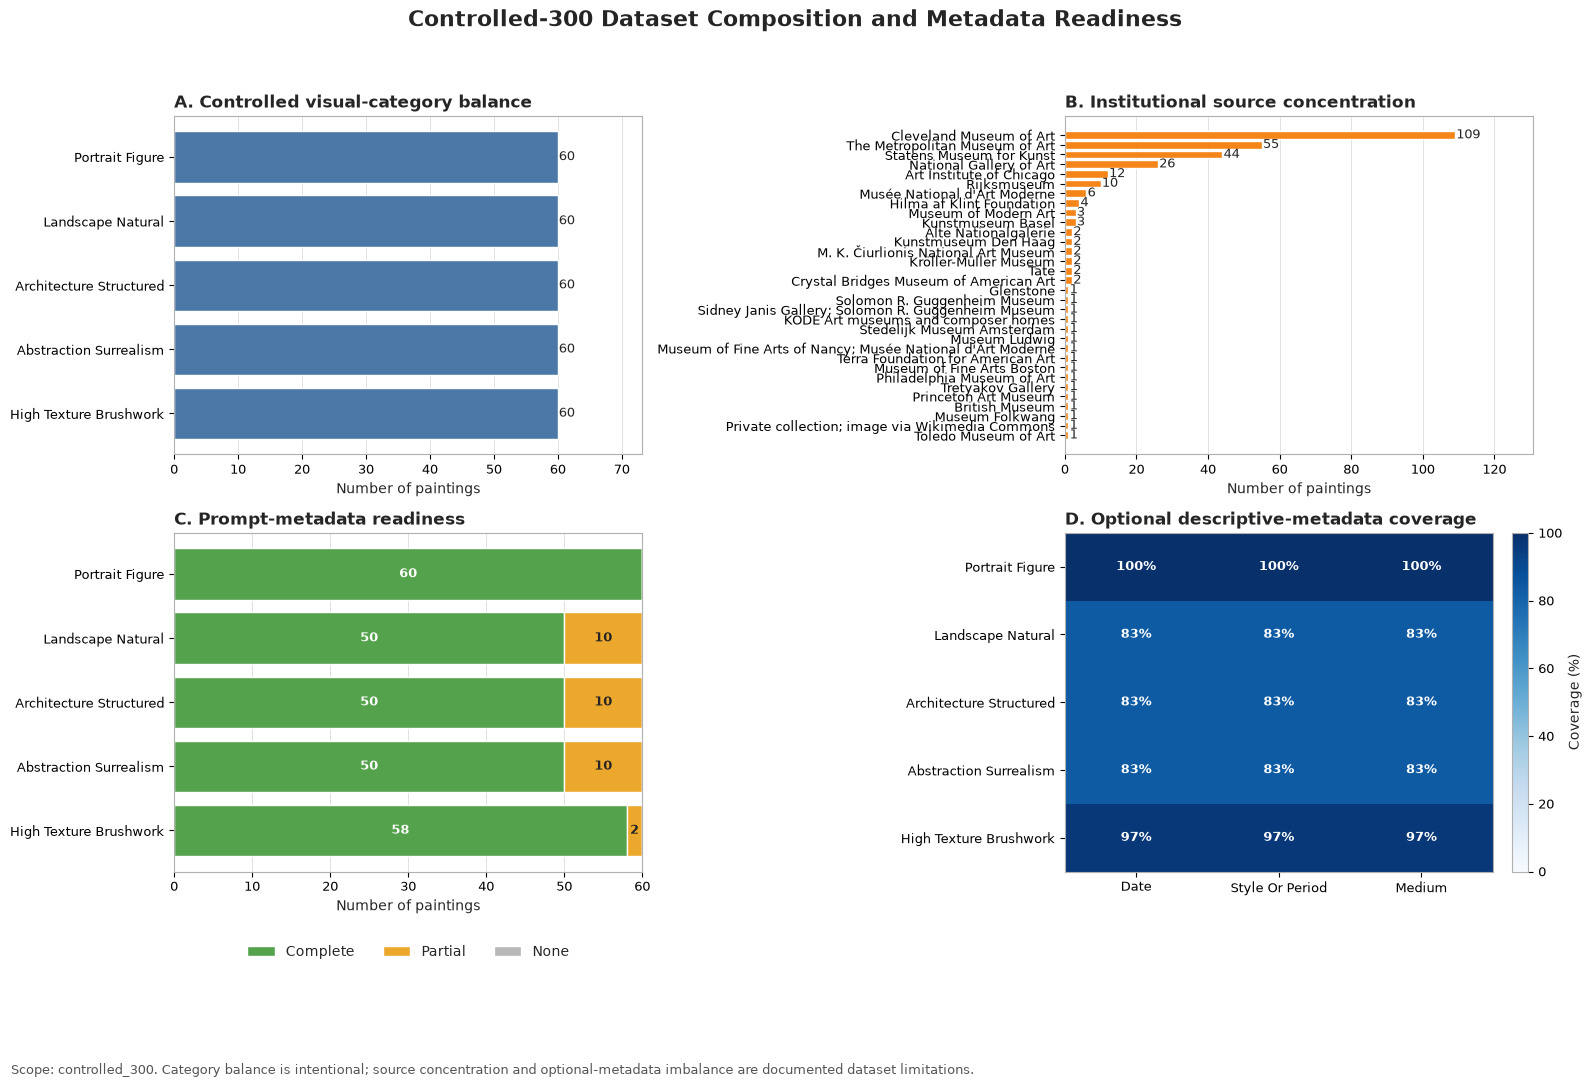

Saved canonical distribution figure: outputs/01_dataset_verification/figures/dataset_distribution.png


In [17]:
# ---------------------------------------------------------------------------
# Standardized visual design
# ---------------------------------------------------------------------------

figure_palette = {
    "category": "#4C78A8",
    "source": "#F58518",
    "complete": "#54A24B",
    "partial": "#ECA82C",
    "none": "#B8B8B8",
    "grid": "#D9D9D9",
    "text": "#252525",
}

distribution_target = FIGURE_OUTPUT_PATHS[
    "dataset_distribution"
]

distribution_temporary = (
    distribution_target.with_name(
        f".{distribution_target.stem}.tmp"
        f"{distribution_target.suffix}"
    )
)


# ---------------------------------------------------------------------------
# Four-panel dataset summary
# ---------------------------------------------------------------------------

with plt.rc_context(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.titlesize": 16,
        "axes.edgecolor": "#B0B0B0",
        "axes.labelcolor": figure_palette[
            "text"
        ],
        "text.color": figure_palette[
            "text"
        ],
    }
):
    distribution_figure, distribution_axes = (
        plt.subplots(
            2,
            2,
            figsize=(16, 11),
            dpi=100,
        )
    )

    category_axis = distribution_axes[0, 0]
    source_axis = distribution_axes[0, 1]
    prompt_axis = distribution_axes[1, 0]
    coverage_axis = distribution_axes[1, 1]

    category_positions = list(
        range(len(category_order))
    )

    category_bars = category_axis.barh(
        category_positions,
        category_counts_for_figure.values,
        color=figure_palette["category"],
        edgecolor="white",
    )

    category_axis.set_yticks(
        category_positions,
        [
            category_display_labels[
                category
            ]
            for category in category_order
        ],
    )

    category_axis.invert_yaxis()
    category_axis.set_xlabel(
        "Number of paintings"
    )
    category_axis.set_title(
        "A. Controlled visual-category balance",
        loc="left",
        fontweight="bold",
    )
    category_axis.set_xlim(
        0,
        max(
            category_counts_for_figure.max()
            * 1.22,
            1,
        ),
    )
    category_axis.grid(
        axis="x",
        color=figure_palette["grid"],
        linewidth=0.7,
        alpha=0.8,
    )
    category_axis.set_axisbelow(True)

    for bar, value in zip(
        category_bars,
        category_counts_for_figure.values,
    ):
        category_axis.text(
            bar.get_width() + 0.15,
            bar.get_y()
            + bar.get_height() / 2,
            str(int(value)),
            va="center",
            fontsize=9,
        )

    source_positions = list(
        range(
            len(
                source_counts_for_figure
            )
        )
    )

    source_bars = source_axis.barh(
        source_positions,
        source_counts_for_figure.values,
        color=figure_palette["source"],
        edgecolor="white",
    )

    source_axis.set_yticks(
        source_positions,
        source_counts_for_figure.index,
    )
    source_axis.set_xlabel(
        "Number of paintings"
    )
    source_axis.set_title(
        "B. Institutional source concentration",
        loc="left",
        fontweight="bold",
    )
    source_axis.set_xlim(
        0,
        max(
            source_counts_for_figure.max()
            * 1.2,
            1,
        ),
    )
    source_axis.grid(
        axis="x",
        color=figure_palette["grid"],
        linewidth=0.7,
        alpha=0.8,
    )
    source_axis.set_axisbelow(True)

    for bar, value in zip(
        source_bars,
        source_counts_for_figure.values,
    ):
        source_axis.text(
            bar.get_width() + 0.35,
            bar.get_y()
            + bar.get_height() / 2,
            str(int(value)),
            va="center",
            fontsize=9,
        )

    prompt_left = pd.Series(
        0,
        index=category_order,
        dtype=float,
    )

    for prompt_status in prompt_status_order:
        prompt_values = (
            prompt_readiness_for_figure[
                prompt_status
            ]
            .astype(float)
        )

        prompt_axis.barh(
            category_positions,
            prompt_values.values,
            left=prompt_left.values,
            color=figure_palette[
                prompt_status
            ],
            edgecolor="white",
            label=(
                prompt_status.title()
            ),
        )

        for position, (
            left_value,
            segment_value,
        ) in enumerate(
            zip(
                prompt_left.values,
                prompt_values.values,
            )
        ):
            if segment_value > 0:
                prompt_axis.text(
                    left_value
                    + segment_value / 2,
                    position,
                    str(
                        int(
                            segment_value
                        )
                    ),
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=(
                        "white"
                        if prompt_status
                        == "complete"
                        else figure_palette[
                            "text"
                        ]
                    ),
                    fontweight="bold",
                )

        prompt_left = (
            prompt_left
            + prompt_values
        )

    prompt_axis.set_yticks(
        category_positions,
        [
            category_display_labels[
                category
            ]
            for category in category_order
        ],
    )
    prompt_axis.invert_yaxis()
    prompt_axis.set_xlabel(
        "Number of paintings"
    )
    prompt_axis.set_title(
        "C. Prompt-metadata readiness",
        loc="left",
        fontweight="bold",
    )
    prompt_axis.legend(
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            -0.18,
        ),
        frameon=False,
        ncols=3,
    )
    prompt_axis.grid(
        axis="x",
        color=figure_palette["grid"],
        linewidth=0.7,
        alpha=0.8,
    )
    prompt_axis.set_axisbelow(True)

    coverage_image = coverage_axis.imshow(
        optional_coverage_for_figure.values,
        cmap="Blues",
        vmin=0,
        vmax=100,
        aspect="auto",
    )

    coverage_axis.set_xticks(
        range(
            len(
                optional_metadata_fields
            )
        ),
        [
            field
            .replace("_", " ")
            .title()
            for field
            in optional_metadata_fields
        ],
    )

    coverage_axis.set_yticks(
        range(len(category_order)),
        [
            category_display_labels[
                category
            ]
            for category in category_order
        ],
    )

    coverage_axis.set_title(
        "D. Optional descriptive-metadata coverage",
        loc="left",
        fontweight="bold",
    )

    for row_index, category in enumerate(
        category_order
    ):
        for column_index, field in enumerate(
            optional_metadata_fields
        ):
            coverage_value = float(
                optional_coverage_for_figure.loc[
                    category,
                    field,
                ]
            )

            coverage_axis.text(
                column_index,
                row_index,
                f"{coverage_value:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                color=(
                    "white"
                    if coverage_value >= 60
                    else figure_palette[
                        "text"
                    ]
                ),
                fontweight="bold",
            )

    coverage_colorbar = (
        distribution_figure.colorbar(
            coverage_image,
            ax=coverage_axis,
            fraction=0.046,
            pad=0.04,
        )
    )
    coverage_colorbar.set_label(
        "Coverage (%)"
    )

    distribution_figure.suptitle(
        "Controlled-300 Dataset Composition and Metadata Readiness",
        fontweight="bold",
    )

    distribution_figure.text(
        0.01,
        0.012,
        (
            "Scope: controlled_300. Category balance is intentional; "
            "source concentration and optional-metadata imbalance are "
            "documented dataset limitations."
        ),
        fontsize=9,
        color="#555555",
    )

    distribution_figure.tight_layout(
        rect=(
            0,
            0.09,
            1,
            0.95,
        )
    )

    try:
        distribution_figure.savefig(
            distribution_temporary,
            dpi=180,
            bbox_inches="tight",
            facecolor="white",
            metadata={
                "Title": (
                    "Controlled-300 Dataset Composition "
                    "and Metadata Readiness"
                ),
                "Creator": NOTEBOOK_STEM,
            },
        )

        distribution_temporary.replace(
            distribution_target
        )
    finally:
        distribution_temporary.unlink(
            missing_ok=True
        )

    plt.show()
    plt.close(
        distribution_figure
    )

print(
    "Saved canonical distribution figure:",
    to_repo_relative(
        distribution_target,
        PROJECT_ROOT,
    ),
)

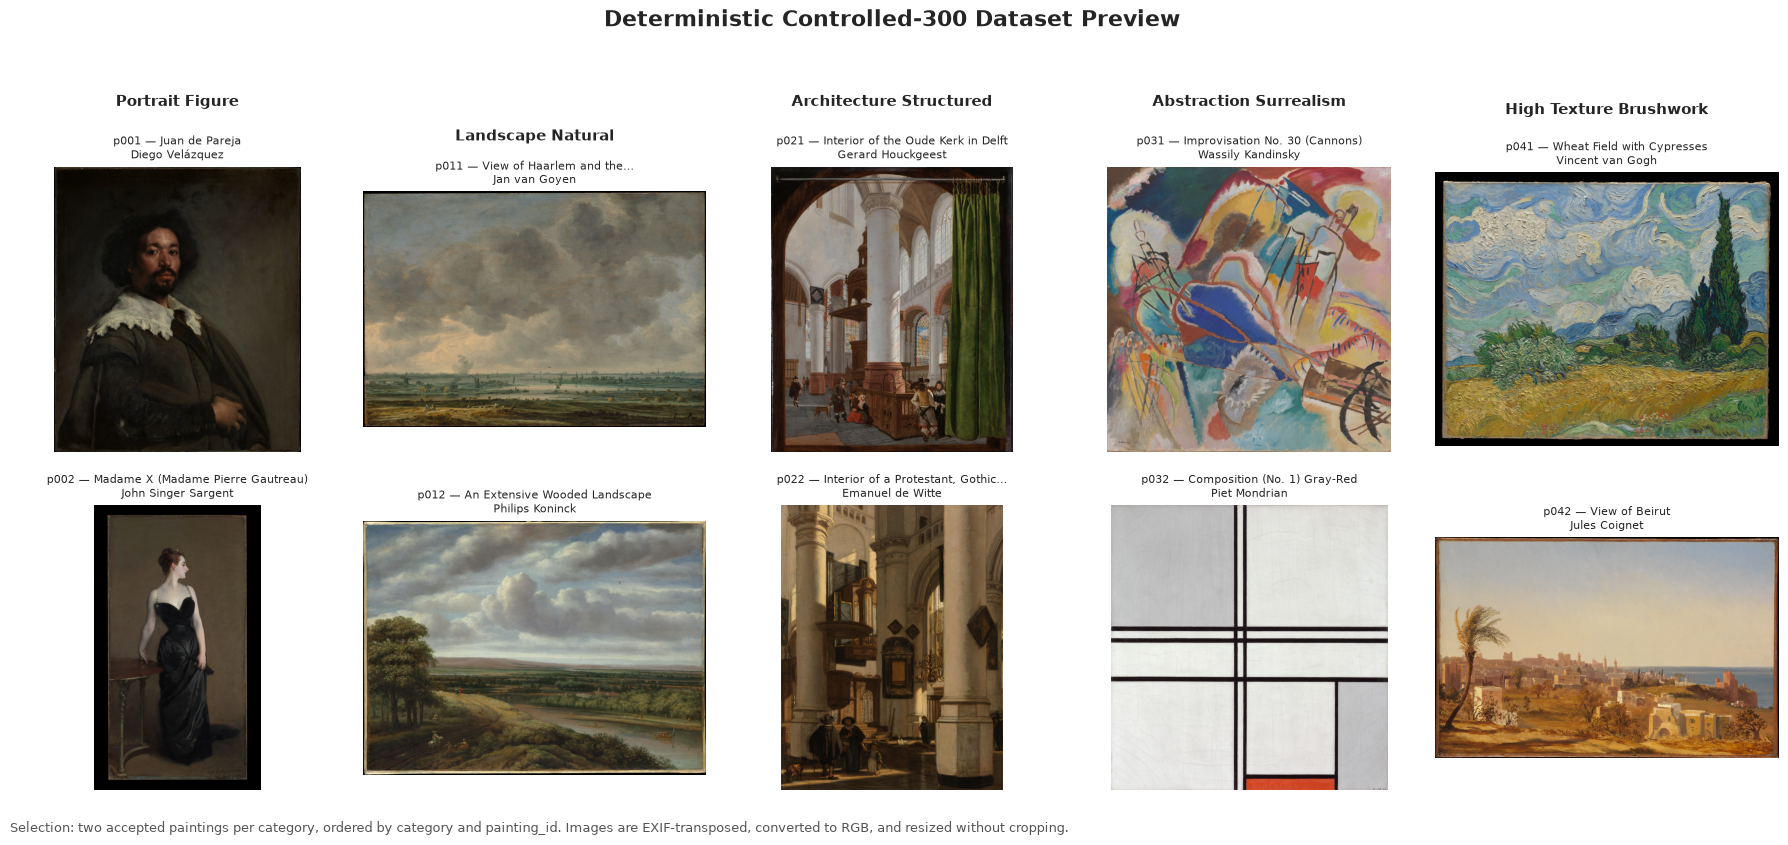

Saved canonical preview figure: outputs/01_dataset_verification/figures/dataset_preview.png


In [18]:
# ---------------------------------------------------------------------------
# Canonical deterministic preview grid
# ---------------------------------------------------------------------------

preview_target = FIGURE_OUTPUT_PATHS[
    "dataset_preview"
]

preview_temporary = (
    preview_target.with_name(
        f".{preview_target.stem}.tmp"
        f"{preview_target.suffix}"
    )
)

with plt.rc_context(
    {
        "font.size": 9,
        "axes.titlesize": 8,
        "figure.titlesize": 16,
        "text.color": figure_palette[
            "text"
        ],
    }
):
    preview_figure, preview_axes = (
        plt.subplots(
            preview_items_per_group,
            len(category_order),
            figsize=(18, 8.5),
            dpi=100,
            squeeze=False,
        )
    )

    for column_index, category in enumerate(
        category_order
    ):
        category_preview_rows = (
            preview_rows_df.loc[
                preview_rows_df[
                    preview_group_field
                ].eq(category)
            ]
            .sort_values(
                "painting_id",
                kind="stable",
            )
            .reset_index(drop=True)
        )

        for row_index in range(
            preview_items_per_group
        ):
            axis = preview_axes[
                row_index,
                column_index,
            ]

            artwork_row = (
                category_preview_rows.iloc[
                    row_index
                ]
            )

            preview_image_path = (
                resolve_repo_path(
                    artwork_row[
                        "raw_image_path"
                    ],
                    PROJECT_ROOT,
                    must_exist=True,
                )
            )

            with Image.open(
                preview_image_path
            ) as raw_preview_image:
                display_preview_image = (
                    ImageOps.exif_transpose(
                        raw_preview_image
                    )
                    .convert("RGB")
                )

                display_preview_image.thumbnail(
                    (
                        900,
                        700,
                    ),
                    Image.Resampling.LANCZOS,
                )

                axis.imshow(
                    display_preview_image
                )

            shortened_title = shorten(
                str(
                    artwork_row["title"]
                ),
                width=34,
                placeholder="…",
            )

            shortened_artist = shorten(
                str(
                    artwork_row["artist"]
                ),
                width=30,
                placeholder="…",
            )

            axis.set_title(
                (
                    f"{artwork_row['painting_id']} — "
                    f"{shortened_title}\n"
                    f"{shortened_artist}"
                ),
                pad=6,
            )

            axis.axis("off")

            if row_index == 0:
                axis.text(
                    0.5,
                    1.20,
                    category_display_labels[
                        category
                    ],
                    transform=axis.transAxes,
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold",
                )

    preview_figure.suptitle(
        "Deterministic Controlled-300 Dataset Preview",
        fontweight="bold",
    )

    preview_figure.text(
        0.01,
        0.012,
        (
            "Selection: two accepted paintings per category, ordered "
            "by category and painting_id. Images are EXIF-transposed, "
            "converted to RGB, and resized without cropping."
        ),
        fontsize=9,
        color="#555555",
    )

    preview_figure.tight_layout(
        rect=(
            0,
            0.045,
            1,
            0.93,
        ),
        h_pad=2.2,
        w_pad=1.1,
    )

    try:
        preview_figure.savefig(
            preview_temporary,
            dpi=180,
            bbox_inches="tight",
            facecolor="white",
            metadata={
                "Title": (
                    "Deterministic Controlled-300 "
                    "Dataset Preview"
                ),
                "Creator": NOTEBOOK_STEM,
            },
        )

        preview_temporary.replace(
            preview_target
        )
    finally:
        preview_temporary.unlink(
            missing_ok=True
        )

    plt.show()
    plt.close(
        preview_figure
    )

print(
    "Saved canonical preview figure:",
    to_repo_relative(
        preview_target,
        PROJECT_ROOT,
    ),
)

In [19]:
# ---------------------------------------------------------------------------
# Reload persisted figures
# ---------------------------------------------------------------------------

figure_evidence_records = []

for figure_id, figure_path in (
    FIGURE_OUTPUT_PATHS.items()
):
    evidence_record = {
        "figure_id": figure_id,
        "relative_path": to_repo_relative(
            figure_path,
            PROJECT_ROOT,
        ),
        "file_exists": (
            figure_path.is_file()
        ),
        "size_bytes": (
            int(
                figure_path.stat().st_size
            )
            if figure_path.is_file()
            else 0
        ),
        "format": "",
        "mode": "",
        "width": pd.NA,
        "height": pd.NA,
        "sha256": "",
        "verified": False,
        "issue": "",
    }

    if figure_path.is_file():
        try:
            with Image.open(
                figure_path
            ) as figure_image:
                figure_image.verify()

            with Image.open(
                figure_path
            ) as figure_image:
                figure_image.load()
                evidence_record[
                    "format"
                ] = str(
                    figure_image.format
                )
                evidence_record[
                    "mode"
                ] = str(
                    figure_image.mode
                )
                (
                    evidence_record["width"],
                    evidence_record["height"],
                ) = map(
                    int,
                    figure_image.size,
                )

            evidence_record[
                "sha256"
            ] = sha256_file(
                figure_path
            )
            evidence_record[
                "verified"
            ] = True

        except Exception as exc:
            evidence_record[
                "issue"
            ] = (
                f"{type(exc).__name__}: "
                f"{exc}"
            )

    figure_evidence_records.append(
        evidence_record
    )

figure_evidence_df = pd.DataFrame(
    figure_evidence_records
)

declared_figure_names = {
    path.name
    for path in FIGURE_OUTPUT_PATHS.values()
}

observed_figure_names = {
    path.name
    for path in (
        OUTPUT_ROOT
        / "figures"
    ).iterdir()
    if path.is_file()
}

undeclared_figure_names = sorted(
    observed_figure_names
    - declared_figure_names
)

missing_declared_figure_names = sorted(
    declared_figure_names
    - observed_figure_names
)


# ---------------------------------------------------------------------------
# Separate figure-validation gate
# ---------------------------------------------------------------------------

FIGURE_VALIDATION = ValidationCollector()

FIGURE_VALIDATION.add(
    validation_stage="figure_generation",
    check_id="preview_selection",
    check_description=(
        "The canonical preview contains the configured deterministic "
        "number of accepted paintings per category."
    ),
    severity="blocking",
    expected=expected_preview_counts,
    observed=observed_preview_counts,
    passed=preview_selection_passed,
)

FIGURE_VALIDATION.add(
    validation_stage="figure_generation",
    check_id="figure_output_ownership",
    check_description=(
        "Both canonical figure paths remain inside the exact "
        "Notebook 01 output root."
    ),
    severity="blocking",
    expected=to_repo_relative(
        OUTPUT_ROOT,
        PROJECT_ROOT,
    ),
    observed={
        figure_id: to_repo_relative(
            figure_path,
            PROJECT_ROOT,
        )
        for figure_id, figure_path
        in FIGURE_OUTPUT_PATHS.items()
    },
    passed=all(
        require_notebook_output_path(
            figure_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
        == figure_path.resolve()
        for figure_path
        in FIGURE_OUTPUT_PATHS.values()
    ),
)

for figure_id in (
    "dataset_distribution",
    "dataset_preview",
):
    figure_record = (
        figure_evidence_df.loc[
            figure_evidence_df[
                "figure_id"
            ].eq(figure_id)
        ]
        .iloc[0]
    )

    figure_passed = (
        bool(
            figure_record[
                "file_exists"
            ]
        )
        and bool(
            figure_record[
                "verified"
            ]
        )
        and figure_record[
            "format"
        ] == "PNG"
        and int(
            figure_record[
                "size_bytes"
            ]
        ) > 0
        and int(
            figure_record[
                "width"
            ]
        ) >= 1600
        and int(
            figure_record[
                "height"
            ]
        ) >= 1000
        and len(
            str(
                figure_record[
                    "sha256"
                ]
            )
        ) == 64
    )

    FIGURE_VALIDATION.add(
        validation_stage="figure_generation",
        check_id=(
            f"{figure_id}_png"
        ),
        check_description=(
            f"{figure_id} is a non-empty, readable, "
            "high-resolution PNG with SHA-256 evidence."
        ),
        severity="blocking",
        expected={
            "format": "PNG",
            "minimum_width": 1600,
            "minimum_height": 1000,
            "sha256_length": 64,
        },
        observed=(
            figure_record.to_dict()
        ),
        passed=figure_passed,
    )

FIGURE_VALIDATION.add(
    validation_stage="figure_generation",
    check_id="declared_figure_set",
    check_description=(
        "The figure directory contains exactly the two declared "
        "canonical figure files."
    ),
    severity="blocking",
    expected=sorted(
        declared_figure_names
    ),
    observed={
        "observed": sorted(
            observed_figure_names
        ),
        "undeclared": (
            undeclared_figure_names
        ),
        "missing": (
            missing_declared_figure_names
        ),
    },
    passed=(
        not undeclared_figure_names
        and not missing_declared_figure_names
    ),
)

figure_checks_df = (
    FIGURE_VALIDATION.to_dataframe()
)

if len(figure_checks_df) != 5:
    raise RuntimeError(
        "Batch 6 should produce exactly 5 separate figure checks; "
        f"found {len(figure_checks_df)}."
    )

FIGURE_VALIDATION.raise_for_blocking()

if (
    len(VALIDATION.checks)
    != EXPECTED_CONSOLIDATED_CHECK_COUNT
):
    raise RuntimeError(
        "Figure checks must not modify the approved "
        f"{EXPECTED_CONSOLIDATED_CHECK_COUNT} consolidated checks; "
        f"found {len(VALIDATION.checks)}."
    )

print("Canonical figure evidence:")
display(
    figure_evidence_df.assign(
        sha256_prefix=(
            figure_evidence_df[
                "sha256"
            ]
            .astype(str)
            .str[:12]
        )
    )[
        [
            "figure_id",
            "relative_path",
            "size_bytes",
            "format",
            "mode",
            "width",
            "height",
            "verified",
            "sha256_prefix",
            "issue",
        ]
    ]
)

print("Batch 6 figure checks:")
display(
    figure_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "\nFigure validation passed:",
    FIGURE_VALIDATION.overall_passed,
)
print(
    "Consolidated validation remains:",
    len(VALIDATION.checks),
)
print(
    "Next approved stage: Batch 7 — "
    "canonical table persistence and manifest handoff."
)

Canonical figure evidence:


,figure_id,relative_path,size_bytes,format,mode,width,height,verified,sha256_prefix,issue
0,dataset_distribution,outputs/01_dataset_verification/figures/datase...,429956,PNG,RGBA,2864,1958,True,71175fab126c,
1,dataset_preview,outputs/01_dataset_verification/figures/datase...,4338408,PNG,RGBA,3219,1522,True,86b3150ae2ae,


Batch 6 figure checks:


,check_id,severity,passed
0,preview_selection,blocking,True
1,figure_output_ownership,blocking,True
2,dataset_distribution_png,blocking,True
3,dataset_preview_png,blocking,True
4,declared_figure_set,blocking,True



Figure validation passed: True
Consolidated validation remains: 50
Next approved stage: Batch 7 — canonical table persistence and manifest handoff.


## Batch 7 — Canonical Persistence and Manifest Handoff

This batch atomically persists the validated canonical tables:

- `data/artworks.csv`
- `metrics/dataset_audit.csv`
- `validation/checks.csv`

It then creates:

- the normalized five-row artifact manifest;
- the reproducibility run manifest;
- immediate reload, checksum, ownership, and exact-output-set evidence.

The artifact manifest contains the five scientific and validation artifacts consumed outside the notebook. It does not recursively register itself or the run manifest.

The run manifest remains in `running` state with `completion_gate_passed: false` until Batch 8 verifies the complete notebook contract.

In [20]:
# ---------------------------------------------------------------------------
# Batch 7 helper imports
# ---------------------------------------------------------------------------

from restoration_eval.dataset_verification import (
    write_dataframe_atomic,
)

from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


# ---------------------------------------------------------------------------
# Pre-persistence gate
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        f"The {EXPECTED_CONSOLIDATED_CHECK_COUNT}-check consolidated "
        "validation gate has not passed."
    )

if not FIGURE_VALIDATION.overall_passed:
    raise RuntimeError(
        "The separate canonical-figure validation gate has not passed."
    )

validation_checks_df = VALIDATION.to_dataframe()

if (
    len(validation_checks_df)
    != EXPECTED_CONSOLIDATED_CHECK_COUNT
):
    raise RuntimeError(
        "Exactly "
        f"{EXPECTED_CONSOLIDATED_CHECK_COUNT} consolidated validation "
        f"rows are required; found {len(validation_checks_df)}."
    )


# ---------------------------------------------------------------------------
# Validate ownership of every declared output target
# ---------------------------------------------------------------------------

output_ownership_failures = []

for output_key, output_path in OUTPUT_PATHS.items():
    try:
        validated_path = (
            require_notebook_output_path(
                output_path,
                NOTEBOOK_STEM,
                PROJECT_ROOT,
            )
        )

        if validated_path != output_path.resolve():
            output_ownership_failures.append(
                {
                    "output_key": output_key,
                    "path": str(output_path),
                    "issue": "resolved_path_mismatch",
                }
            )

    except Exception as exc:
        output_ownership_failures.append(
            {
                "output_key": output_key,
                "path": str(output_path),
                "issue": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )

if output_ownership_failures:
    raise RuntimeError(
        "One or more output paths violate notebook ownership: "
        f"{output_ownership_failures}"
    )


# ---------------------------------------------------------------------------
# Atomic table persistence
# ---------------------------------------------------------------------------

write_dataframe_atomic(
    artworks_df,
    OUTPUT_PATHS["artworks"],
)

write_dataframe_atomic(
    dataset_audit_df,
    OUTPUT_PATHS["dataset_audit"],
)

write_dataframe_atomic(
    validation_checks_df,
    OUTPUT_PATHS["validation_checks"],
)


# ---------------------------------------------------------------------------
# Immediate reload
# ---------------------------------------------------------------------------

artworks_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["artworks"],
    low_memory=False,
)

dataset_audit_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["dataset_audit"],
    low_memory=False,
)

validation_checks_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["validation_checks"],
    low_memory=False,
)

artworks_reload_schema_result = (
    validate_dataframe(
        artworks_reloaded_df,
        ARTWORKS_SCHEMA,
        allow_extra_columns=False,
    )
)

dataset_audit_reload_schema_result = (
    validate_dataframe(
        dataset_audit_reloaded_df,
        DATASET_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)

validation_reload_schema_result = (
    validate_dataframe(
        validation_checks_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Reloaded identity evidence
# ---------------------------------------------------------------------------

expected_artwork_ids = set(
    artworks_df["painting_id"]
    .astype(str)
)

reloaded_artwork_ids = set(
    artworks_reloaded_df[
        "painting_id"
    ]
    .astype(str)
)

expected_audit_ids = set(
    dataset_audit_df["audit_row_id"]
    .astype(str)
)

reloaded_audit_ids = set(
    dataset_audit_reloaded_df[
        "audit_row_id"
    ]
    .astype(str)
)

expected_validation_keys = {
    (
        str(check.validation_stage),
        str(check.check_id),
    )
    for check in VALIDATION.checks
}

reloaded_validation_keys = {
    (
        str(row.validation_stage),
        str(row.check_id),
    )
    for row
    in validation_checks_reloaded_df.itertuples(
        index=False
    )
}

reloaded_passed_values = (
    validation_checks_reloaded_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
)

all_reloaded_checks_passed = bool(
    reloaded_passed_values
    .eq("true")
    .all()
)


# ---------------------------------------------------------------------------
# Reconfirm current figure hashes
# ---------------------------------------------------------------------------

figure_hash_failures = []

for figure_row in figure_evidence_df.itertuples(
    index=False
):
    figure_path = resolve_repo_path(
        figure_row.relative_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    current_checksum = sha256_file(
        figure_path
    )

    if current_checksum != str(
        figure_row.sha256
    ):
        figure_hash_failures.append(
            {
                "figure_id": (
                    figure_row.figure_id
                ),
                "expected_checksum": (
                    str(
                        figure_row.sha256
                    )
                ),
                "observed_checksum": (
                    current_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Separate persistence-validation gate
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = ValidationCollector()

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="output_path_ownership",
    check_description=(
        "Every declared output path remains inside the exact "
        "Notebook 01 output root."
    ),
    severity="blocking",
    expected="zero ownership failures",
    observed=output_ownership_failures,
    passed=not output_ownership_failures,
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="artworks_csv_reload",
    check_description=(
        "Persisted artworks.csv reloads under artworks.v1 with "
        "the expected row count and painting identities."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED_ARTWORK_COUNT,
        "schema_passed": True,
        "painting_ids_match": True,
    },
    observed={
        "rows": len(
            artworks_reloaded_df
        ),
        "schema": (
            artworks_reload_schema_result
            .to_dict()
        ),
        "painting_ids_match": (
            reloaded_artwork_ids
            == expected_artwork_ids
        ),
    },
    passed=(
        artworks_reload_schema_result.passed
        and len(artworks_reloaded_df)
        == EXPECTED_ARTWORK_COUNT
        and reloaded_artwork_ids
        == expected_artwork_ids
    ),
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="dataset_audit_csv_reload",
    check_description=(
        "Persisted dataset_audit.csv reloads under dataset_audit.v1 "
        "with the expected row count and audit identities."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED_AUDIT_ROW_COUNT,
        "schema_passed": True,
        "audit_ids_match": True,
    },
    observed={
        "rows": len(
            dataset_audit_reloaded_df
        ),
        "schema": (
            dataset_audit_reload_schema_result
            .to_dict()
        ),
        "audit_ids_match": (
            reloaded_audit_ids
            == expected_audit_ids
        ),
    },
    passed=(
        dataset_audit_reload_schema_result.passed
        and len(
            dataset_audit_reloaded_df
        )
        == EXPECTED_AUDIT_ROW_COUNT
        and reloaded_audit_ids
        == expected_audit_ids
    ),
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="validation_checks_csv_reload",
    check_description=(
        "Persisted checks.csv reloads under validation_checks.v1 "
        f"with all {EXPECTED_CONSOLIDATED_CHECK_COUNT} expected "
        "passing check identities."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED_CONSOLIDATED_CHECK_COUNT,
        "schema_passed": True,
        "keys_match": True,
        "all_passed": True,
    },
    observed={
        "rows": len(validation_checks_reloaded_df),
        "schema": validation_reload_schema_result.to_dict(),
        "keys_match": (
            reloaded_validation_keys
            == expected_validation_keys
        ),
        "all_passed": all_reloaded_checks_passed,
    },
    passed=(
        validation_reload_schema_result.passed
        and len(validation_checks_reloaded_df)
        == EXPECTED_CONSOLIDATED_CHECK_COUNT
        and reloaded_validation_keys
        == expected_validation_keys
        and all_reloaded_checks_passed
    ),
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="canonical_figure_hashes",
    check_description=(
        "Both validated canonical figures still match the hashes "
        "recorded immediately after generation."
    ),
    severity="blocking",
    expected="zero figure checksum changes",
    observed=figure_hash_failures,
    passed=not figure_hash_failures,
)

persistence_checks_df = (
    PERSISTENCE_VALIDATION
    .to_dataframe()
)

if len(persistence_checks_df) != 5:
    raise RuntimeError(
        "Batch 7 should produce exactly 5 separate persistence checks; "
        f"found {len(persistence_checks_df)}."
    )

PERSISTENCE_VALIDATION.raise_for_blocking()

if (
    len(VALIDATION.checks)
    != EXPECTED_CONSOLIDATED_CHECK_COUNT
):
    raise RuntimeError(
        "Persistence checks must not modify the approved "
        f"{EXPECTED_CONSOLIDATED_CHECK_COUNT} consolidated checks; "
        f"found {len(VALIDATION.checks)}."
    )

print("Canonical tables persisted and reloaded.")
print(
    "Persistence validation passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)

display(
    persistence_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Canonical tables persisted and reloaded.
Persistence validation passed: True


,check_id,severity,passed
0,output_path_ownership,blocking,True
1,artworks_csv_reload,blocking,True
2,dataset_audit_csv_reload,blocking,True
3,validation_checks_csv_reload,blocking,True
4,canonical_figure_hashes,blocking,True


In [21]:
# ---------------------------------------------------------------------------
# Five externally meaningful artifact records
# ---------------------------------------------------------------------------

dataset_scope = str(
    dataset_config["dataset"][
        "dataset_scope"
    ]
)

artifact_specifications = [
    {
        "artifact_key": "artworks",
        "path": OUTPUT_PATHS[
            "artworks"
        ],
        "artifact_type": "dataset_table",
        "artifact_role": OUTPUTS[
            "artworks"
        ]["artifact_role"],
        "schema_version": (
            ARTWORKS_SCHEMA.version
        ),
        "row_count": len(
            artworks_reloaded_df
        ),
    },
    {
        "artifact_key": "dataset_audit",
        "path": OUTPUT_PATHS[
            "dataset_audit"
        ],
        "artifact_type": "audit_table",
        "artifact_role": OUTPUTS[
            "dataset_audit"
        ]["artifact_role"],
        "schema_version": (
            DATASET_AUDIT_SCHEMA.version
        ),
        "row_count": len(
            dataset_audit_reloaded_df
        ),
    },
    {
        "artifact_key": "dataset_distribution",
        "path": OUTPUT_PATHS[
            "dataset_distribution"
        ],
        "artifact_type": "figure",
        "artifact_role": OUTPUTS[
            "dataset_distribution"
        ]["artifact_role"],
        "schema_version": OUTPUTS[
            "dataset_distribution"
        ]["schema_version"],
        "row_count": None,
    },
    {
        "artifact_key": "dataset_preview",
        "path": OUTPUT_PATHS[
            "dataset_preview"
        ],
        "artifact_type": "figure",
        "artifact_role": OUTPUTS[
            "dataset_preview"
        ]["artifact_role"],
        "schema_version": OUTPUTS[
            "dataset_preview"
        ]["schema_version"],
        "row_count": None,
    },
    {
        "artifact_key": "validation_checks",
        "path": OUTPUT_PATHS[
            "validation_checks"
        ],
        "artifact_type": "validation_table",
        "artifact_role": OUTPUTS[
            "validation_checks"
        ]["artifact_role"],
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "row_count": len(
            validation_checks_reloaded_df
        ),
    },
]

artifact_records = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=NOTEBOOK_STEM,
        path=specification["path"],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope=dataset_scope,
        experiment_id="",
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification
    in artifact_specifications
]

artifact_manifest_df = (
    artifact_records_dataframe(
        artifact_records
    )
)

if len(artifact_manifest_df) != 5:
    raise RuntimeError(
        "The normalized artifact manifest must contain exactly "
        f"5 records; found {len(artifact_manifest_df)}."
    )

write_artifact_manifest(
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    artifact_records,
)


# ---------------------------------------------------------------------------
# Reproducibility and run-state evidence
# ---------------------------------------------------------------------------

configuration_paths = [
    to_repo_relative(
        DATASET_CONFIG_PATH,
        PROJECT_ROOT,
    )
]

configuration_checksums_by_path = (
    configuration_checksums(
        [
            DATASET_CONFIG_PATH,
        ],
        PROJECT_ROOT,
    )
)

run_inputs = [
    {
        "input_key": input_key,
        **input_contract,
    }
    for input_key, input_contract
    in INPUTS.items()
]

run_outputs = [
    {
        "output_key": output_key,
        **output_contract,
    }
    for output_key, output_contract
    in OUTPUTS.items()
]

expected_run_counts = {
    "metadata_rows": int(
        dataset_config["expected"][
            "total_paintings"
        ]
    ),
    "referenced_images": int(
        dataset_config["expected"][
            "referenced_image_count"
        ]
    ),
    "artwork_rows": int(
        OUTPUTS["artworks"][
            "expected_cardinality"
        ]
    ),
    "dataset_audit_rows": int(
        OUTPUTS["dataset_audit"][
            "expected_cardinality"
        ]
    ),
    "validation_rows": int(
        OUTPUTS["validation_checks"][
            "expected_cardinality"
        ]
    ),
    "artifact_records": int(
        OUTPUTS["artifact_manifest"][
            "expected_cardinality"
        ]
    ),
    "canonical_figures": 2,
}

observed_run_counts = {
    "metadata_rows": len(
        metadata_df
    ),
    "referenced_images": len(
        full_image_df
    ),
    "accepted_artworks": int(
        accepted_artwork_count
    ),
    "excluded_artworks": int(
        excluded_artwork_count
    ),
    "artwork_rows": len(
        artworks_reloaded_df
    ),
    "dataset_audit_rows": len(
        dataset_audit_reloaded_df
    ),
    "validation_rows": len(
        validation_checks_reloaded_df
    ),
    "artifact_records": len(
        artifact_manifest_df
    ),
    "canonical_figures": len(
        figure_evidence_df
    ),
    "exact_duplicate_groups": len(
        full_image_audit
        .exact_duplicate_groups
    ),
    "near_duplicate_candidate_pairs": len(
        full_image_audit
        .near_duplicate_candidates
    ),
}

known_limitations = [
    str(item["statement"])
    for item
    in dataset_config[
        "bias_notes"
    ]
]

known_limitations.append(
    "Dataset verification establishes technical and metadata "
    "suitability; it does not certify historical representativeness "
    "or conservation suitability."
)

run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            dataset_config["dataset"][
                "dataset_id"
            ]
        ),
        "dataset_version": (
            dataset_config["dataset"][
                "dataset_version"
            ]
        ),
        "dataset_scope": dataset_scope,
        "execution_profile": (
            dataset_config["dataset"][
                "execution_profile"
            ]
        ),
        "content_fingerprint": (
            DATASET_CONTENT_SHA256
        ),
        "fingerprint_version": (
            DATASET_FINGERPRINT_VERSION
        ),
        "metadata_schema": (
            RAW_ARTWORK_METADATA_SCHEMA
            .version
        ),
        "artworks_schema": (
            ARTWORKS_SCHEMA.version
        ),
        "dataset_audit_schema": (
            DATASET_AUDIT_SCHEMA.version
        ),
    },
    configuration_paths=(
        configuration_paths
    ),
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=(
        expected_run_counts
    ),
    observed_counts=(
        observed_run_counts
    ),
    validation_summary={
        "consolidated": (
            VALIDATION.summary()
        ),
        "representative_smoke": (
            SMOKE_VALIDATION.summary()
        ),
        "figure_generation": (
            FIGURE_VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION
            .summary()
        ),
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=known_limitations,
    project_root=PROJECT_ROOT,
    package_names=(
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
    ),
    hardware={
        "execution_device": "CPU",
        "gpu_required": False,
    },
)

run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": (
            "passed_pending_completion_gate"
        ),
        "depends_on": [
            "raw metadata",
            "raw images",
            "dataset configuration",
            "current inventory",
        ],
        "applicable_dataset_scopes": [
            dataset_scope,
        ],
        "applicable_experiment_scopes": [],
        "expensive_execution": False,
        "completion_gate_passed": False,
    }
)

RUN_ID = str(
    run_manifest["run_id"]
)

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    run_manifest,
)

print(
    "Artifact manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "artifact_manifest"
        ],
        PROJECT_ROOT,
    ),
)
print(
    "Provisional run manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "run_manifest"
        ],
        PROJECT_ROOT,
    ),
)
print(
    "Provisional run ID:",
    RUN_ID,
)
print(
    "Run status:",
    run_manifest[
        "run_status"
    ],
)

Artifact manifest written: outputs/01_dataset_verification/manifests/artifacts.csv
Provisional run manifest written: outputs/01_dataset_verification/manifests/run_manifest.json
Provisional run ID: run_49a7e3c485394878ab4323ce661f3ef5
Run status: running


In [22]:
# ---------------------------------------------------------------------------
# Reload normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    low_memory=False,
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as run_manifest_file:
    run_manifest_reloaded = json.load(
        run_manifest_file
    )

artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Artifact-manifest contract and checksum reconciliation
# ---------------------------------------------------------------------------

expected_artifact_keys = {
    "artworks",
    "dataset_audit",
    "dataset_distribution",
    "dataset_preview",
    "validation_checks",
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ]
    .astype(str)
)

artifact_checksum_failures = []
artifact_path_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df
    .itertuples(index=False)
):
    try:
        artifact_path = resolve_repo_path(
            artifact_row.relative_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = sha256_file(
            artifact_path
        )

        if observed_checksum != str(
            artifact_row.checksum
        ):
            artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row
                        .artifact_key
                    ),
                    "expected_checksum": (
                        str(
                            artifact_row
                            .checksum
                        )
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Run-manifest contract
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(run_manifest_reloaded)
)

run_manifest_matches_memory = (
    run_manifest_reloaded
    == run_manifest
)

run_manifest_state_passed = (
    not run_manifest_missing_keys
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded[
        "run_status"
    ]
    == "running"
    and not run_manifest_reloaded[
        "completion_gate_passed"
    ]
    and run_manifest_reloaded[
        "inventory_run_id"
    ]
    == inventory_run[
        "inventory_run_id"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ]["content_fingerprint"]
    == DATASET_CONTENT_SHA256
)


# ---------------------------------------------------------------------------
# Exact seven-file output contract
# ---------------------------------------------------------------------------

expected_output_relative_paths = {
    str(
        output_contract[
            "relative_path"
        ]
    )
    for output_contract
    in OUTPUTS.values()
}

observed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

undeclared_output_paths = sorted(
    observed_output_relative_paths
    - expected_output_relative_paths
)

missing_output_paths = sorted(
    expected_output_relative_paths
    - observed_output_relative_paths
)

exact_output_set_passed = (
    not undeclared_output_paths
    and not missing_output_paths
    and len(
        observed_output_relative_paths
    )
    == 7
)


# ---------------------------------------------------------------------------
# Separate handoff validation
# ---------------------------------------------------------------------------

HANDOFF_VALIDATION = ValidationCollector()

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_manifest_contract",
    check_description=(
        "artifacts.csv satisfies artifact_manifest.v1 and contains "
        "exactly the five declared externally meaningful artifacts."
    ),
    severity="blocking",
    expected=sorted(
        expected_artifact_keys
    ),
    observed={
        "schema": (
            artifact_manifest_reload_result
            .to_dict()
        ),
        "artifact_keys": sorted(
            observed_artifact_keys
        ),
    },
    passed=(
        artifact_manifest_reload_result.passed
        and len(
            artifact_manifest_reloaded_df
        )
        == 5
        and observed_artifact_keys
        == expected_artifact_keys
    ),
)

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_paths_and_checksums",
    check_description=(
        "Every artifact-manifest path is notebook-owned, exists, "
        "and matches its recorded checksum."
    ),
    severity="blocking",
    expected={
        "path_failures": [],
        "checksum_failures": [],
    },
    observed={
        "path_failures": (
            artifact_path_failures
        ),
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
    passed=(
        not artifact_path_failures
        and not artifact_checksum_failures
    ),
)

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="provisional_run_manifest",
    check_description=(
        "run_manifest.json reloads under run_manifest.v1 with the "
        "current inventory, dataset fingerprint, and pending "
        "completion-gate state."
    ),
    severity="blocking",
    expected={
        "missing_required_keys": [],
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_in_memory": True,
    },
    observed={
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_in_memory": (
            run_manifest_matches_memory
        ),
    },
    passed=run_manifest_state_passed,
)

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="exact_output_file_set",
    check_description=(
        "The Notebook 01 output root contains exactly the seven "
        "declared canonical files and no undeclared files."
    ),
    severity="blocking",
    expected=sorted(
        expected_output_relative_paths
    ),
    observed={
        "files": sorted(
            observed_output_relative_paths
        ),
        "undeclared": (
            undeclared_output_paths
        ),
        "missing": (
            missing_output_paths
        ),
    },
    passed=exact_output_set_passed,
)

handoff_checks_df = (
    HANDOFF_VALIDATION.to_dataframe()
)

if len(handoff_checks_df) != 4:
    raise RuntimeError(
        "Batch 7 should produce exactly 4 separate handoff checks; "
        f"found {len(handoff_checks_df)}."
    )

HANDOFF_VALIDATION.raise_for_blocking()

if (
    len(VALIDATION.checks)
    != EXPECTED_CONSOLIDATED_CHECK_COUNT
):
    raise RuntimeError(
        "Handoff checks must not modify the approved "
        f"{EXPECTED_CONSOLIDATED_CHECK_COUNT} consolidated checks; "
        f"found {len(VALIDATION.checks)}."
    )

print(
    "Manifest handoff validation passed:",
    HANDOFF_VALIDATION.overall_passed,
)

display(
    handoff_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Manifest handoff validation passed: True


,check_id,severity,passed
0,artifact_manifest_contract,blocking,True
1,artifact_paths_and_checksums,blocking,True
2,provisional_run_manifest,blocking,True
3,exact_output_file_set,blocking,True


In [23]:
# ---------------------------------------------------------------------------
# Compact artifact and run summary
# ---------------------------------------------------------------------------

artifact_manifest_display_df = (
    artifact_manifest_reloaded_df[
        [
            "artifact_key",
            "artifact_type",
            "artifact_role",
            "relative_path",
            "format",
            "schema_version",
            "row_count",
            "file_count",
            "size_bytes",
            "checksum",
            "validation_status",
        ]
    ]
    .copy()
)

artifact_manifest_display_df[
    "checksum_prefix"
] = (
    artifact_manifest_display_df[
        "checksum"
    ]
    .astype(str)
    .str[:12]
)

artifact_manifest_display_df = (
    artifact_manifest_display_df.drop(
        columns=[
            "checksum",
        ]
    )
)

run_manifest_display_df = pd.DataFrame(
    [
        {
            "run_id": (
                run_manifest_reloaded[
                    "run_id"
                ]
            ),
            "run_status": (
                run_manifest_reloaded[
                    "run_status"
                ]
            ),
            "completion_gate_passed": (
                run_manifest_reloaded[
                    "completion_gate_passed"
                ]
            ),
            "dataset_scope": (
                run_manifest_reloaded[
                    "dataset_versions"
                ]["dataset_scope"]
            ),
            "dataset_version": (
                run_manifest_reloaded[
                    "dataset_versions"
                ]["dataset_version"]
            ),
            "content_fingerprint_prefix": (
                run_manifest_reloaded[
                    "dataset_versions"
                ]["content_fingerprint"][:12]
            ),
            "inventory_run_id": (
                run_manifest_reloaded[
                    "inventory_run_id"
                ]
            ),
            "git_commit": (
                run_manifest_reloaded[
                    "git_commit"
                ][:12]
            ),
            "git_dirty": (
                run_manifest_reloaded[
                    "git_dirty"
                ]
            ),
            "python_version": (
                run_manifest_reloaded[
                    "python_version"
                ]
            ),
        }
    ]
)

print("Normalized artifact manifest:")
display(
    artifact_manifest_display_df
)

print("Provisional run manifest:")
display(
    run_manifest_display_df
)

print(
    "Persisted output files:",
    len(
        observed_output_relative_paths
    ),
)
print(
    "Consolidated checks:",
    len(VALIDATION.checks),
)
print(
    "Persistence checks passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)
print(
    "Handoff checks passed:",
    HANDOFF_VALIDATION.overall_passed,
)

print("\nBatch 7 completed successfully.")
print(
    "Next approved stage: Batch 8 — "
    "final completion gate and post-gate registry update."
)

Normalized artifact manifest:


,artifact_key,artifact_type,artifact_role,relative_path,format,schema_version,row_count,file_count,size_bytes,validation_status,checksum_prefix
0,artworks,dataset_table,primary_downstream,outputs/01_dataset_verification/data/artworks.csv,csv,artworks.v1,300.0,1,280991,passed,be5c78657a7b
1,dataset_audit,audit_table,audit_reporting,outputs/01_dataset_verification/metrics/datase...,csv,dataset_audit.v1,448.0,1,78442,passed,68fba080332d
2,dataset_distribution,figure,reporting,outputs/01_dataset_verification/figures/datase...,png,figure.dataset_distribution.v1,NaN,1,429956,passed,71175fab126c
3,dataset_preview,figure,qa_reporting,outputs/01_dataset_verification/figures/datase...,png,figure.dataset_preview.v1,NaN,1,4338408,passed,86b3150ae2ae
4,validation_checks,validation_table,validation,outputs/01_dataset_verification/validation/che...,csv,validation_checks.v1,50.0,1,39092,passed,16b51dc3d1ec


Provisional run manifest:


,run_id,run_status,completion_gate_passed,dataset_scope,dataset_version,content_fingerprint_prefix,inventory_run_id,git_commit,git_dirty,python_version
0,run_49a7e3c485394878ab4323ce661f3ef5,running,False,controlled_300,2.0.0,5c8797aebe0c,inventory_20260909T113928Z_adc18e36,3659243655dc,True,3.12.6


Persisted output files: 7
Consolidated checks: 50
Persistence checks passed: True
Handoff checks passed: True

Batch 7 completed successfully.
Next approved stage: Batch 8 — final completion gate and post-gate registry update.


## Batch 8 — Final Completion Gate and Registry Update

This final batch:

1. maps every Notebook 01 roadmap responsibility to implementation evidence;
2. verifies all validation layers and canonical outputs;
3. passes the completion gate before any registry mutation;
4. registers the five validated artifacts in the global project-path registry;
5. finalizes `run_manifest.json` with completed status;
6. revalidates the final output and registry state.

The notebook-local artifact manifest uses concise local keys. The global registry uses qualified semantic keys so common outputs such as `validation_checks` cannot overwrite entries from other notebooks.

The project inventory is not refreshed inside this notebook. It must be refreshed after the completed notebook is saved and independently inspected.

In [24]:
# ---------------------------------------------------------------------------
# Final independent schema evidence
# ---------------------------------------------------------------------------

final_metadata_schema_result = validate_dataframe(
    metadata_df,
    RAW_ARTWORK_METADATA_SCHEMA,
    allow_extra_columns=False,
)

final_validation_layer_status = {
    "consolidated_validation": (
        VALIDATION.overall_passed
        and len(VALIDATION.checks)
        == EXPECTED_CONSOLIDATED_CHECK_COUNT
    ),
    "representative_smoke": SMOKE_VALIDATION.overall_passed,
    "figure_generation": FIGURE_VALIDATION.overall_passed,
    "canonical_persistence": PERSISTENCE_VALIDATION.overall_passed,
    "manifest_handoff": HANDOFF_VALIDATION.overall_passed,
}


# ---------------------------------------------------------------------------
# Roadmap and implementation-guideline coverage
# ---------------------------------------------------------------------------

completion_requirement_records = [
    {
        "requirement_id": "metadata_contract",
        "requirement": (
            "Raw metadata satisfies its schema and configured cardinality."
        ),
        "evidence": (
            f"schema={final_metadata_schema_result.passed}; "
            f"rows={len(metadata_df)}"
        ),
        "passed": (
            final_metadata_schema_result.passed
            and len(metadata_df) == EXPECTED_ARTWORK_COUNT
        ),
    },
    {
        "requirement_id": "painting_identity",
        "requirement": (
            "Painting identifiers are complete, unique, and deterministic."
        ),
        "evidence": (
            f"duplicates={len(duplicate_artwork_ids)}; "
            "order verified against stable painting_id sorting"
        ),
        "passed": (
            not duplicate_artwork_ids
            and observed_painting_order == expected_painting_order
            and observed_sort_indices == expected_sort_indices
        ),
    },
    {
        "requirement_id": "image_existence_and_decode",
        "requirement": (
            "Every referenced image exists, verifies, and fully decodes."
        ),
        "evidence": (
            f"audited={len(full_image_df)}; "
            f"issues={len(full_issue_rows)}"
        ),
        "passed": (
            len(full_image_df) == FULL_EXPECTED_IMAGE_COUNT
            and bool(full_image_df["file_exists"].all())
            and bool(full_image_df["image_verified"].all())
            and bool(full_image_df["image_loaded"].all())
        ),
    },
    {
        "requirement_id": "image_technical_contract",
        "requirement": (
            "Image format, mode, dimensions, and minimum resolution pass."
        ),
        "evidence": (
            f"{FULL_EXPECTED_IMAGE_COUNT} JPEG/RGB images; "
            "dimension and resolution checks passed"
        ),
        "passed": bool(
            (
                full_image_df["extension_allowed"]
                & full_image_df["format_allowed"]
                & full_image_df["mode_allowed"]
                & full_image_df["width_matches_metadata"]
                & full_image_df["height_matches_metadata"]
                & full_image_df["minimum_resolution_passed"]
            ).all()
        ),
    },
    {
        "requirement_id": "duplicate_evidence",
        "requirement": (
            "Exact and near-duplicate methods are documented and resolved."
        ),
        "evidence": (
            f"exact_groups={len(full_image_audit.exact_duplicate_groups)}; "
            "near_pairs="
            f"{len(full_image_audit.near_duplicate_candidates)}; "
            f"method={DHASH_METHOD_VERSION}"
        ),
        "passed": (
            not full_image_audit.exact_duplicate_groups
            and full_image_audit.near_duplicate_candidates.empty
            and valid_sha256_count == FULL_EXPECTED_IMAGE_COUNT
            and valid_dhash_count == FULL_EXPECTED_IMAGE_COUNT
        ),
    },
    {
        "requirement_id": "source_licence_rights",
        "requirement": (
            "Every accepted artwork has approved source, licence, URL, "
            "and rights-status evidence."
        ),
        "evidence": (
            f"accepted={accepted_artwork_count}; "
            f"rights_failures={len(rights_failure_rows)}"
        ),
        "passed": (
            accepted_artwork_count == EXPECTED_ARTWORK_COUNT
            and not rights_failure_rows
            and artworks_df["source_url"]
            .astype("string")
            .str.strip()
            .ne("")
            .fillna(False)
            .all()
        ),
    },
    {
        "requirement_id": "descriptive_metadata",
        "requirement": (
            "Artist, title, date/period, style, medium, category, "
            "source, and notes are retained where available."
        ),
        "evidence": (
            "Normalized artworks.v1 contains all approved descriptive fields"
        ),
        "passed": {
            "title",
            "artist",
            "date_or_period",
            "style_or_period",
            "medium",
            "category",
            "source",
            "source_notes",
        }.issubset(artworks_df.columns),
    },
    {
        "requirement_id": "metadata_completeness",
        "requirement": (
            "Metadata completeness is quantified and reproducible."
        ),
        "evidence": (
            f"mismatches={len(completeness_mismatch_ids)}; "
            f"{metadata_completeness_audit_count} field-level audit rows"
        ),
        "passed": (
            not completeness_mismatch_ids
            and completeness_bounds_passed
            and metadata_completeness_audit_count
            == len(metadata_df.columns)
        ),
    },
    {
        "requirement_id": "dataset_distributions",
        "requirement": (
            "Category, source, licence, style, medium, and period "
            "distributions are recorded."
        ),
        "evidence": (
            "All six required distribution fields occur in dataset_audit.v1"
        ),
        "passed": required_distribution_fields.issubset(
            observed_distribution_fields
        ),
    },
    {
        "requirement_id": "group_imbalance",
        "requirement": (
            "Category, source, and optional-metadata imbalance are recorded."
        ),
        "evidence": (
            f"imbalance_metrics={len(observed_imbalance_metrics)}"
        ),
        "passed": required_imbalance_metrics.issubset(
            observed_imbalance_metrics
        ),
    },
    {
        "requirement_id": "biases_and_limitations",
        "requirement": (
            "Historical, geographic, source, acquisition, metadata, "
            "and sampling limitations are documented."
        ),
        "evidence": (
            f"documented_limitations={len(bias_rows_df)}"
        ),
        "passed": (
            observed_bias_pairs == expected_bias_pairs
            and bias_details_present
            and bias_status_passed
        ),
    },
    {
        "requirement_id": "dataset_identity_and_version",
        "requirement": (
            "Dataset identity, version, scope, and content fingerprint "
            "are deterministic."
        ),
        "evidence": (
            f"scope={dataset_scope}; "
            f"version={dataset_config['dataset']['dataset_version']}; "
            f"fingerprint={DATASET_CONTENT_SHA256}"
        ),
        "passed": (
            observed_dataset_identity == expected_dataset_identity
            and fingerprint_format_passed
            and fingerprint_repeatability_passed
        ),
    },
    {
        "requirement_id": "execution_profile",
        "requirement": (
            "The controlled_300 execution profile is explicit and supported."
        ),
        "evidence": (
            f"scope={dataset_scope}; "
            f"configuration={DATASET_CONFIG_SCHEMA_VERSION}"
        ),
        "passed": (
            dataset_scope == "controlled_300"
            and dataset_config["dataset"]["execution_profile"]
            == dataset_scope
            and not dataset_config_errors
        ),
    },
    {
        "requirement_id": "prompt_metadata_readiness",
        "requirement": (
            "Prompt-metadata readiness is recorded without defining "
            "prompt policy."
        ),
        "evidence": (
            f"mismatches={len(prompt_mismatch_ids)}; "
            f"rows={prompt_readiness_audit_count}"
        ),
        "passed": (
            not prompt_mismatch_ids
            and prompt_readiness_audit_count
            == 2 * len(category_order)
        ),
    },
    {
        "requirement_id": "deterministic_preview",
        "requirement": (
            "The preview contains two rule-selected accepted paintings "
            "per category."
        ),
        "evidence": (
            f"preview_rows={len(preview_rows_df)}; "
            f"counts={observed_preview_counts}"
        ),
        "passed": preview_selection_passed,
    },
    {
        "requirement_id": "canonical_figures",
        "requirement": (
            "Both canonical figures are readable, high-resolution, "
            "owned, and checksum-verified."
        ),
        "evidence": (
            f"figures={len(figure_evidence_df)}; "
            f"figure_checks={len(figure_checks_df)}"
        ),
        "passed": (
            FIGURE_VALIDATION.overall_passed
            and not figure_hash_failures
            and len(figure_evidence_df) == 2
        ),
    },
    {
        "requirement_id": "canonical_tables",
        "requirement": (
            "Artwork, audit, and validation tables persist and reload "
            "under their declared schemas."
        ),
        "evidence": (
            f"artworks={len(artworks_reloaded_df)}; "
            f"dataset_audit={len(dataset_audit_reloaded_df)}; "
            f"validation_checks={len(validation_checks_reloaded_df)}"
        ),
        "passed": (
            artworks_reload_schema_result.passed
            and dataset_audit_reload_schema_result.passed
            and validation_reload_schema_result.passed
            and len(artworks_reloaded_df) == EXPECTED_ARTWORK_COUNT
            and len(dataset_audit_reloaded_df)
            == EXPECTED_AUDIT_ROW_COUNT
            and len(validation_checks_reloaded_df)
            == EXPECTED_CONSOLIDATED_CHECK_COUNT
        ),
    },
    {
        "requirement_id": "consolidated_validation",
        "requirement": (
            "One compact validation table contains no blocking failure."
        ),
        "evidence": (
            f"checks={len(VALIDATION.checks)}; "
            f"overall_passed={VALIDATION.overall_passed}"
        ),
        "passed": (
            VALIDATION.overall_passed
            and len(VALIDATION.checks)
            == EXPECTED_CONSOLIDATED_CHECK_COUNT
            and all_reloaded_checks_passed
        ),
    },
    {
        "requirement_id": "normalized_manifests",
        "requirement": (
            "Artifact and provisional run manifests reload and reconcile."
        ),
        "evidence": (
            f"artifacts={len(artifact_manifest_reloaded_df)}; "
            f"run_id={RUN_ID}"
        ),
        "passed": (
            HANDOFF_VALIDATION.overall_passed
            and artifact_manifest_reload_result.passed
            and not artifact_path_failures
            and not artifact_checksum_failures
            and run_manifest_state_passed
        ),
    },
    {
        "requirement_id": "output_ownership_and_minimization",
        "requirement": (
            "The output root contains exactly seven declared files "
            "and no undeclared artifacts."
        ),
        "evidence": (
            f"files={len(observed_output_relative_paths)}; "
            f"undeclared={undeclared_output_paths}; "
            f"missing={missing_output_paths}"
        ),
        "passed": (
            exact_output_set_passed
            and not output_ownership_failures
        ),
    },
    {
        "requirement_id": "interpretation_boundary",
        "requirement": (
            "Known limitations explicitly prevent historical or "
            "conservation claims."
        ),
        "evidence": (
            f"known_limitations={len(known_limitations)}"
        ),
        "passed": (
            len(known_limitations) >= 6
            and any(
                "conservation" in limitation.lower()
                for limitation in known_limitations
            )
            and any(
                "historical" in limitation.lower()
                for limitation in known_limitations
            )
        ),
    },
]

completion_gate_df = pd.DataFrame(
    completion_requirement_records
)

completion_gate_df["status"] = completion_gate_df["passed"].map(
    {
        True: "passed",
        False: "failed",
    }
)

failed_completion_requirements = (
    completion_gate_df.loc[
        ~completion_gate_df["passed"],
        [
            "requirement_id",
            "requirement",
            "evidence",
        ],
    ]
    .to_dict("records")
)


# ---------------------------------------------------------------------------
# Final pre-registry completion validation
# ---------------------------------------------------------------------------

FINAL_COMPLETION_VALIDATION = ValidationCollector()

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion_gate",
    check_id="truth_source_coverage",
    check_description=(
        "Every approved Notebook 01 roadmap and implementation "
        "requirement has passing implementation evidence."
    ),
    severity="blocking",
    expected={
        "failed_requirements": [],
        "requirement_count": len(completion_gate_df),
    },
    observed={
        "failed_requirements": failed_completion_requirements,
        "requirement_count": len(completion_gate_df),
    },
    passed=not failed_completion_requirements,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion_gate",
    check_id="all_validation_layers",
    check_description=(
        "All consolidated and separate validation layers pass."
    ),
    severity="blocking",
    expected={
        layer_name: True
        for layer_name in final_validation_layer_status
    },
    observed=final_validation_layer_status,
    passed=all(final_validation_layer_status.values()),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion_gate",
    check_id="canonical_handoff_state",
    check_description=(
        "The seven-file canonical handoff is complete, owned, "
        "and checksum-consistent before registry mutation."
    ),
    severity="blocking",
    expected={
        "output_files": len(OUTPUTS),
        "artifact_records": EXPECTED_ARTIFACT_RECORD_COUNT,
        "checksum_failures": [],
    },
    observed={
        "output_files": len(observed_output_relative_paths),
        "artifact_records": len(artifact_manifest_reloaded_df),
        "checksum_failures": artifact_checksum_failures,
    },
    passed=(
        exact_output_set_passed
        and len(artifact_manifest_reloaded_df)
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and not artifact_path_failures
        and not artifact_checksum_failures
    ),
)

final_completion_checks_df = (
    FINAL_COMPLETION_VALIDATION.to_dataframe()
)

FINAL_COMPLETION_VALIDATION.raise_for_blocking()

PRE_REGISTRY_COMPLETION_PASSED = (
    FINAL_COMPLETION_VALIDATION.overall_passed
)

print(
    "Pre-registry completion gate passed:",
    PRE_REGISTRY_COMPLETION_PASSED,
)
print(
    "Requirements evaluated:",
    len(completion_gate_df),
)
print(
    "Failed requirements:",
    len(failed_completion_requirements),
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "status",
            "evidence",
        ]
    ]
)

Pre-registry completion gate passed: True
Requirements evaluated: 21
Failed requirements: 0


,requirement_id,status,evidence
0,metadata_contract,passed,schema=True; rows=300
1,painting_identity,passed,duplicates=0; order verified against stable pa...
2,image_existence_and_decode,passed,audited=300; issues=0
3,image_technical_contract,passed,300 JPEG/RGB images; dimension and resolution ...
4,duplicate_evidence,passed,exact_groups=0; near_pairs=0; method=dhash64.v1
5,source_licence_rights,passed,accepted=300; rights_failures=0
6,descriptive_metadata,passed,Normalized artworks.v1 contains all approved d...
7,metadata_completeness,passed,mismatches=0; 17 field-level audit rows
8,dataset_distributions,passed,All six required distribution fields occur in ...
9,group_imbalance,passed,imbalance_metrics=12


In [25]:
# ---------------------------------------------------------------------------
# Registry helper imports
# ---------------------------------------------------------------------------

from restoration_eval.paths import (
    render_project_paths_markdown,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Guard the sole global write in this notebook
# ---------------------------------------------------------------------------

if not PRE_REGISTRY_COMPLETION_PASSED:
    raise RuntimeError(
        "The project-path registry cannot be updated before "
        "the Notebook 01 completion gate passes."
    )


# ---------------------------------------------------------------------------
# Globally unique semantic registry keys
# ---------------------------------------------------------------------------

GLOBAL_REGISTRY_KEY_BY_LOCAL = {
    "artworks": "dataset.artworks",
    "dataset_audit": "dataset.audit",
    "dataset_distribution": (
        "dataset.figure_distribution"
    ),
    "dataset_preview": (
        "dataset.figure_preview"
    ),
    "validation_checks": (
        "validation.01_dataset_verification"
    ),
}

registry_artifact_records = []

for artifact_row in (
    artifact_manifest_reloaded_df
    .itertuples(index=False)
):
    local_artifact_key = str(
        artifact_row.artifact_key
    )

    global_artifact_key = (
        GLOBAL_REGISTRY_KEY_BY_LOCAL[
            local_artifact_key
        ]
    )

    registry_artifact_records.append(
        {
            "artifact_key": (
                global_artifact_key
            ),
            "producer_notebook": (
                str(
                    artifact_row
                    .producer_notebook
                )
            ),
            "relative_path": (
                str(
                    artifact_row
                    .relative_path
                )
            ),
            "artifact_type": (
                str(
                    artifact_row
                    .artifact_type
                )
            ),
            "artifact_role": (
                str(
                    artifact_row
                    .artifact_role
                )
            ),
            "schema_version": (
                str(
                    artifact_row
                    .schema_version
                )
            ),
            "dataset_scope": (
                str(
                    artifact_row
                    .dataset_scope
                )
            ),
            "experiment_id": "",
            "validation_status": (
                str(
                    artifact_row
                    .validation_status
                )
            ),
            "row_count": (
                ""
                if pd.isna(
                    artifact_row.row_count
                )
                else int(
                    artifact_row.row_count
                )
            ),
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )

current_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths_registry = (
    upsert_project_path_artifacts(
        current_project_paths_registry,
        registry_artifact_records,
    )
)

registry_json_path, registry_markdown_path = (
    write_project_paths_registry(
        updated_project_paths_registry,
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Reload and validate both registry representations
# ---------------------------------------------------------------------------

final_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_contract_errors = (
    validate_project_paths_registry(
        final_project_paths_registry
    )
)

with registry_markdown_path.open(
    "r",
    encoding="utf-8-sig",
) as registry_markdown_file:
    registry_markdown_text = (
        registry_markdown_file.read()
    )

expected_registry_markdown = (
    render_project_paths_markdown(
        final_project_paths_registry
    )
)

registry_markdown_matches = (
    registry_markdown_text
    == expected_registry_markdown
)

registered_artifacts_by_key = {
    str(record["artifact_key"]): record
    for record
    in final_project_paths_registry[
        "artifacts"
    ]
}

expected_global_registry_keys = set(
    GLOBAL_REGISTRY_KEY_BY_LOCAL
    .values()
)

registry_reconciliation_failures = []

for registry_record in (
    registry_artifact_records
):
    registry_key = str(
        registry_record["artifact_key"]
    )

    observed_record = (
        registered_artifacts_by_key.get(
            registry_key
        )
    )

    if observed_record is None:
        registry_reconciliation_failures.append(
            {
                "artifact_key": (
                    registry_key
                ),
                "issue": (
                    "missing_registry_record"
                ),
            }
        )
        continue

    for field in (
        "producer_notebook",
        "relative_path",
        "artifact_type",
        "artifact_role",
        "schema_version",
        "dataset_scope",
        "validation_status",
        "file_count",
        "checksum",
    ):
        if str(
            observed_record.get(
                field,
                ""
            )
        ) != str(
            registry_record.get(
                field,
                ""
            )
        ):
            registry_reconciliation_failures.append(
                {
                    "artifact_key": (
                        registry_key
                    ),
                    "field": field,
                    "expected": (
                        registry_record.get(
                            field,
                            ""
                        )
                    ),
                    "observed": (
                        observed_record.get(
                            field,
                            ""
                        )
                    ),
                }
            )


# ---------------------------------------------------------------------------
# Registry validation
# ---------------------------------------------------------------------------

REGISTRY_VALIDATION = ValidationCollector()

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_schema",
    check_description=(
        "The reloaded global project-path registry satisfies "
        "project_paths.v1."
    ),
    severity="blocking",
    expected="zero registry contract errors",
    observed=registry_contract_errors,
    passed=not registry_contract_errors,
)

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="notebook_artifact_registration",
    check_description=(
        "All five Notebook 01 artifacts are registered under "
        "globally unique semantic keys with matching evidence."
    ),
    severity="blocking",
    expected=sorted(
        expected_global_registry_keys
    ),
    observed={
        "registered_keys": sorted(
            expected_global_registry_keys
            & set(
                registered_artifacts_by_key
            )
        ),
        "reconciliation_failures": (
            registry_reconciliation_failures
        ),
    },
    passed=(
        expected_global_registry_keys
        .issubset(
            registered_artifacts_by_key
        )
        and not registry_reconciliation_failures
    ),
)

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_markdown_view",
    check_description=(
        "project_paths.md exactly reflects the authoritative "
        "project_paths.json registry."
    ),
    severity="blocking",
    expected=True,
    observed=registry_markdown_matches,
    passed=registry_markdown_matches,
)

registry_checks_df = (
    REGISTRY_VALIDATION.to_dataframe()
)

REGISTRY_VALIDATION.raise_for_blocking()

project_paths_registry = (
    final_project_paths_registry
)

print(
    "Project-path registry updated:",
    to_repo_relative(
        registry_json_path,
        PROJECT_ROOT,
    ),
)
print(
    "Markdown registry updated:",
    to_repo_relative(
        registry_markdown_path,
        PROJECT_ROOT,
    ),
)
print(
    "Notebook 01 registry artifacts:",
    len(
        expected_global_registry_keys
    ),
)
print(
    "Registry validation passed:",
    REGISTRY_VALIDATION.overall_passed,
)

display(
    registry_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Project-path registry updated: outputs/inventory/project_paths.json
Markdown registry updated: outputs/inventory/project_paths.md
Notebook 01 registry artifacts: 5
Registry validation passed: True


,check_id,severity,passed
0,registry_schema,blocking,True
1,notebook_artifact_registration,blocking,True
2,registry_markdown_view,blocking,True


In [26]:
# ---------------------------------------------------------------------------
# Final completed run manifest
# ---------------------------------------------------------------------------

if not REGISTRY_VALIDATION.overall_passed:
    raise RuntimeError(
        "The run manifest cannot be finalized before the "
        "post-gate registry validation passes."
    )

RUN_COMPLETED_AT_UTC = utc_now_iso()

final_run_manifest = json.loads(
    json.dumps(
        run_manifest
    )
)

final_validation_summary = dict(
    final_run_manifest[
        "validation_summary"
    ]
)

final_validation_summary.update(
    {
        "manifest_handoff": (
            HANDOFF_VALIDATION.summary()
        ),
        "final_completion_gate": (
            FINAL_COMPLETION_VALIDATION
            .summary()
        ),
        "registry_update": (
            REGISTRY_VALIDATION.summary()
        ),
        "completion_gate": {
            "status": "passed",
            "passed": True,
            "requirement_count": len(
                completion_gate_df
            ),
            "failed_requirement_ids": [],
        },
    }
)

final_run_manifest.update(
    {
        "run_status": "completed",
        "completed_at_utc": (
            RUN_COMPLETED_AT_UTC
        ),
        "validation_summary": (
            final_validation_summary
        ),
        "refactor_status": "complete",
        "validation_status": "passed",
        "completion_gate_passed": True,
    }
)

final_run_manifest[
    "observed_counts"
][
    "registered_project_artifacts"
] = len(
    expected_global_registry_keys
)

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    final_run_manifest,
)


# ---------------------------------------------------------------------------
# Reload final manifest and canonical state
# ---------------------------------------------------------------------------

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as final_run_manifest_file:
    final_run_manifest_reloaded = (
        json.load(
            final_run_manifest_file
        )
    )

final_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(
        final_run_manifest_reloaded
    )
)

final_manifest_state_passed = (
    not final_manifest_missing_keys
    and final_run_manifest_reloaded
    == final_run_manifest
    and final_run_manifest_reloaded[
        "run_id"
    ] == RUN_ID
    and final_run_manifest_reloaded[
        "manifest_schema_version"
    ] == RUN_MANIFEST_SCHEMA_VERSION
    and final_run_manifest_reloaded[
        "run_status"
    ] == "completed"
    and final_run_manifest_reloaded[
        "completion_gate_passed"
    ]
    and final_run_manifest_reloaded[
        "refactor_status"
    ] == "complete"
    and final_run_manifest_reloaded[
        "validation_status"
    ] == "passed"
    and bool(
        final_run_manifest_reloaded[
            "completed_at_utc"
        ]
    )
)

final_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_output_set_passed = (
    final_output_relative_paths
    == expected_output_relative_paths
    and len(
        final_output_relative_paths
    ) == 7
)

artifact_checksum_failures_after_completion = []

for artifact_row in (
    artifact_manifest_reloaded_df
    .itertuples(index=False)
):
    artifact_path = resolve_repo_path(
        artifact_row.relative_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_checksum = sha256_file(
        artifact_path
    )

    if observed_checksum != str(
        artifact_row.checksum
    ):
        artifact_checksum_failures_after_completion.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "expected_checksum": (
                    artifact_row.checksum
                ),
                "observed_checksum": (
                    observed_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final post-write validation
# ---------------------------------------------------------------------------

FINALIZATION_VALIDATION = (
    ValidationCollector()
)

FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="completed_run_manifest",
    check_description=(
        "The final run manifest reloads with completed status, "
        "the original run ID, and a passed completion gate."
    ),
    severity="blocking",
    expected={
        "run_id": RUN_ID,
        "run_status": "completed",
        "completion_gate_passed": True,
        "missing_required_keys": [],
    },
    observed={
        "run_id": (
            final_run_manifest_reloaded
            .get("run_id")
        ),
        "run_status": (
            final_run_manifest_reloaded
            .get("run_status")
        ),
        "completion_gate_passed": (
            final_run_manifest_reloaded
            .get(
                "completion_gate_passed"
            )
        ),
        "missing_required_keys": (
            final_manifest_missing_keys
        ),
    },
    passed=final_manifest_state_passed,
)

FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_artifact_integrity",
    check_description=(
        "All five artifact checksums remain valid after finalizing "
        "the run manifest."
    ),
    severity="blocking",
    expected="zero artifact checksum failures",
    observed=(
        artifact_checksum_failures_after_completion
    ),
    passed=not (
        artifact_checksum_failures_after_completion
    ),
)

FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_output_set",
    check_description=(
        "The finalized Notebook 01 output root still contains "
        "exactly the seven declared files."
    ),
    severity="blocking",
    expected=sorted(
        expected_output_relative_paths
    ),
    observed=sorted(
        final_output_relative_paths
    ),
    passed=final_output_set_passed,
)

finalization_checks_df = (
    FINALIZATION_VALIDATION
    .to_dataframe()
)

FINALIZATION_VALIDATION.raise_for_blocking()

NOTEBOOK_COMPLETION_PASSED = (
    FINAL_COMPLETION_VALIDATION.overall_passed
    and REGISTRY_VALIDATION.overall_passed
    and FINALIZATION_VALIDATION.overall_passed
    and VALIDATION.overall_passed
    and len(VALIDATION.checks)
    == EXPECTED_CONSOLIDATED_CHECK_COUNT
)

if not NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 01 did not satisfy its final completion state."
    )

print(
    "Final run manifest status:",
    final_run_manifest_reloaded[
        "run_status"
    ],
)
print(
    "Final completion gate:",
    final_run_manifest_reloaded[
        "completion_gate_passed"
    ],
)
print(
    "Finalization validation passed:",
    FINALIZATION_VALIDATION
    .overall_passed,
)

display(
    finalization_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Final run manifest status: completed
Final completion gate: True
Finalization validation passed: True


,check_id,severity,passed
0,completed_run_manifest,blocking,True
1,final_artifact_integrity,blocking,True
2,final_output_set,blocking,True


In [27]:
# ---------------------------------------------------------------------------
# Registered Notebook 01 artifacts
# ---------------------------------------------------------------------------

registered_notebook_artifacts_df = pd.DataFrame(
    [
        record
        for record
        in final_project_paths_registry[
            "artifacts"
        ]
        if record["artifact_key"]
        in expected_global_registry_keys
    ]
).sort_values(
    "artifact_key",
    kind="stable",
).reset_index(
    drop=True
)


# ---------------------------------------------------------------------------
# Final notebook status
# ---------------------------------------------------------------------------

final_status_df = pd.DataFrame(
    [
        {
            "notebook_id": NOTEBOOK_ID,
            "notebook_stem": NOTEBOOK_STEM,
            "refactor_status": (
                final_run_manifest_reloaded[
                    "refactor_status"
                ]
            ),
            "validation_status": (
                final_run_manifest_reloaded[
                    "validation_status"
                ]
            ),
            "completion_gate_passed": (
                final_run_manifest_reloaded[
                    "completion_gate_passed"
                ]
            ),
            "run_status": (
                final_run_manifest_reloaded[
                    "run_status"
                ]
            ),
            "run_id": (
                final_run_manifest_reloaded[
                    "run_id"
                ]
            ),
            "dataset_scope": dataset_scope,
            "dataset_version": (
                dataset_config["dataset"][
                    "dataset_version"
                ]
            ),
            "content_fingerprint_prefix": (
                DATASET_CONTENT_SHA256[:12]
            ),
            "canonical_output_files": len(
                final_output_relative_paths
            ),
            "artifact_manifest_records": len(
                artifact_manifest_reloaded_df
            ),
            "consolidated_validation_rows": len(
                VALIDATION.checks
            ),
            "registered_project_artifacts": len(
                registered_notebook_artifacts_df
            ),
            "completed_at_utc": (
                final_run_manifest_reloaded[
                    "completed_at_utc"
                ]
            ),
        }
    ]
)

print("Final Notebook 01 status:")
display(final_status_df)

print("Registered project-path artifacts:")
display(
    registered_notebook_artifacts_df[
        [
            "artifact_key",
            "producer_notebook",
            "relative_path",
            "artifact_role",
            "schema_version",
            "dataset_scope",
            "validation_status",
            "row_count",
            "file_count",
            "checksum",
        ]
    ]
)

print(
    "Completion requirements passed:",
    int(
        completion_gate_df[
            "passed"
        ].sum()
    ),
    "/",
    len(completion_gate_df),
)
print(
    "Consolidated validation passed:",
    VALIDATION.overall_passed,
)
print(
    "Notebook completion passed:",
    NOTEBOOK_COMPLETION_PASSED,
)
print(
    "\nNotebook 01 is ready for independent final inspection "
    "and project-inventory refresh."
)

Final Notebook 01 status:


,notebook_id,notebook_stem,refactor_status,validation_status,completion_gate_passed,run_status,run_id,dataset_scope,dataset_version,content_fingerprint_prefix,canonical_output_files,artifact_manifest_records,consolidated_validation_rows,registered_project_artifacts,completed_at_utc
0,01,01_dataset_verification,complete,passed,True,completed,run_49a7e3c485394878ab4323ce661f3ef5,controlled_300,2.0.0,5c8797aebe0c,7,5,50,5,2026-09-09T13:53:39.055613Z


Registered project-path artifacts:


,artifact_key,producer_notebook,relative_path,artifact_role,schema_version,dataset_scope,validation_status,row_count,file_count,checksum
0,dataset.artworks,01_dataset_verification,outputs/01_dataset_verification/data/artworks.csv,primary_downstream,artworks.v1,controlled_300,passed,300,1,be5c78657a7b6cdefb432024131b61586c275edf139ce9...
1,dataset.audit,01_dataset_verification,outputs/01_dataset_verification/metrics/datase...,audit_reporting,dataset_audit.v1,controlled_300,passed,448,1,68fba080332d021c2f153721cde76cfea9cb7dfe5fb95a...
2,dataset.figure_distribution,01_dataset_verification,outputs/01_dataset_verification/figures/datase...,reporting,figure.dataset_distribution.v1,controlled_300,passed,,1,71175fab126c364068ecb3bbc8481662c8d11f22675429...
3,dataset.figure_preview,01_dataset_verification,outputs/01_dataset_verification/figures/datase...,qa_reporting,figure.dataset_preview.v1,controlled_300,passed,,1,86b3150ae2aea13b8e663d4a175ea3886c582735902680...
4,validation.01_dataset_verification,01_dataset_verification,outputs/01_dataset_verification/validation/che...,validation,validation_checks.v1,controlled_300,passed,50,1,16b51dc3d1ecedec10047829c3eb85a05aa5f1d1dc53b8...


Completion requirements passed: 21 / 21
Consolidated validation passed: True
Notebook completion passed: True

Notebook 01 is ready for independent final inspection and project-inventory refresh.
